
IQR FILTERING SUMMARY
Rows before IQR filtering : 123,627
Rows after IQR filtering  : 72,377
Rows removed by IQR       : 51,250
Percent removed           : 41.46%


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.557e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)



=== Train/Test metrics by Combo (sorted by Score desc) ===
           Combo            Model  Score  Train_R2  Train_MAE  Test_R2  Test_MAE  Test_MSE  Test_AUC  Test_P  Test_R
SPATIAL+TEMPORAL MLP (256,128,64)  0.996     0.999      0.349    0.992     0.615     2.104     0.999   0.990   0.962
SPATIAL+TEMPORAL     MLP (128,64)  0.993     0.998      0.477    0.990     0.649     2.506     0.999   0.990   0.955
SPATIAL+TEMPORAL              ETR  0.992     1.000      0.000    0.985     0.519     3.741     0.999   0.992   0.953
SPATIAL+TEMPORAL         MLP (64)  0.988     0.997      0.650    0.989     0.744     2.873     0.999   0.988   0.953
SPATIAL+TEMPORAL               RF  0.983     0.998      0.237    0.982     0.636     4.436     0.999   0.990   0.939
SPATIAL+TEMPORAL            Bayes  0.982     0.989      0.868    0.983     0.877     4.236     0.998   0.980   0.965
SPATIAL+TEMPORAL            Ridge  0.982     0.989      0.868    0.983     0.877     4.237     0.998   0.980   0.964
SPAT

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.34789e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.557e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)



MAE COMPARISON: BEFORE vs AFTER IQR


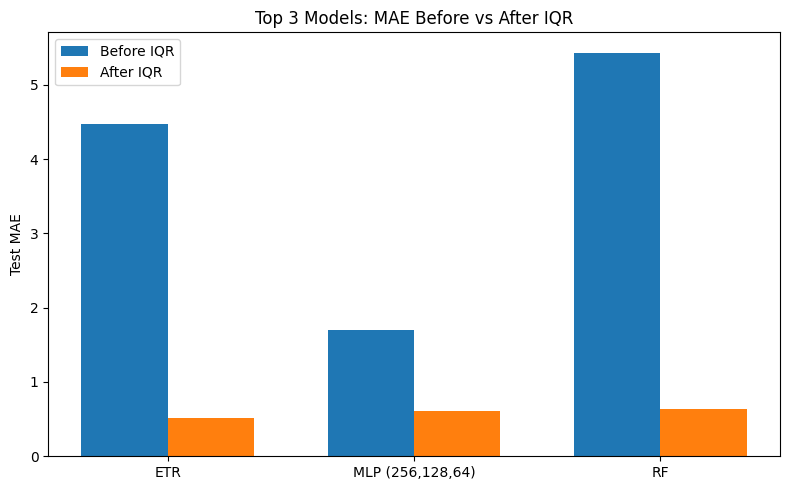

In [46]:
# ==== Experiments over SPATIAL / TEMPORAL / SPATIAL+TEMPORAL (Train & Test: multi-metric score) ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge, HuberRegressor
from sklearn.neural_network import MLPRegressor
#from xgboost import XGBRegressor

# ---------------- Config ----------------
RANDOM_STATE = 42
TEST_SIZE = 0.20

PATH = r"/Users/izarin2/Desktop/My Research/Project1/Dr Lisong/Dataset/Airsage Dataset/NebraskaLakes_Cleaned_round.csv"

# ---------------- Load ----------------
df = pd.read_csv(PATH, low_memory=False)
df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d", errors="coerce")
df["count"] = pd.to_numeric(df["count"], errors="coerce")
df = df.dropna(subset=["date","count"]).copy()

# Ensure we have a POI id
if "poi_id" not in df.columns:
    for alt in ["poi","lake_id","id","POI_ID","POIID","site_id"]:
        if alt in df.columns:
            df = df.rename(columns={alt: "poi_id"})
            break
if "poi_id" not in df.columns:
    df["poi_id"] = 0

# ---------------- Save dataset BEFORE IQR ----------------
df_before_iqr = df.copy()

# ---------------- IQR outlier trimming (exclude target) ----------------
candidate_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
all_features = [c for c in candidate_numeric if c != "count"]
all_features = [c for c in all_features
                if df[c].notna().sum() > 0 and df[c].nunique(dropna=True) > 1]

'''for col in all_features:
   Q1 = df[col].quantile(0.25)
   Q3 = df[col].quantile(0.75)
   IQR = Q3 - Q1
   if pd.isna(IQR) or IQR == 0:
       continue
   lower = Q1 - 1.5 * IQR
   upper = Q3 + 1.5 * IQR
   df = df[(df[col] >= lower) & (df[col] <= upper)]
if len(df) == 0:
   raise RuntimeError("All rows were filtered by the IQR loop. Relax bounds or skip constant columns.")
'''
# ---------------- Rows before IQR ----------------
rows_before_iqr = len(df)

print("\n" + "=" * 60)
print("IQR FILTERING SUMMARY")
print("=" * 60)
print(f"Rows before IQR filtering : {rows_before_iqr:,}")
k = 2# <-- more gentle than 1.5; try 2.0 or 3.0
mask = pd.Series(True, index=df.index)

for col in all_features:
    s = df[col]
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    if pd.isna(IQR) or IQR == 0:
        continue
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    mask &= s.between(lower, upper) | s.isna()

df = df[mask].copy()

# ---------------- Rows after IQR ----------------
rows_after_iqr = len(df)
rows_removed_iqr = rows_before_iqr - rows_after_iqr
pct_removed_iqr = (
    rows_removed_iqr / rows_before_iqr * 100
    if rows_before_iqr > 0 else 0
)

print(f"Rows after IQR filtering  : {rows_after_iqr:,}")
print(f"Rows removed by IQR       : {rows_removed_iqr:,}")
print(f"Percent removed           : {pct_removed_iqr:.2f}%")
print("=" * 60)



if len(df) == 0:
    raise RuntimeError("All rows were filtered by IQR. Increase k (e.g., 3.0) or skip trimming.")

# ---------------- Save dataset AFTER IQR ----------------
df_after_iqr = df.copy()

# ---------------- SPATIAL features (numeric-only + poi_id_code; drop known leaky cols) ----------------
df["poi_id_code"] = df["poi_id"].astype("category").cat.codes

spatial_exact = {"poi_id","poi","home_origin","home_county","home_state","home_msa",
                 "county","state","msa","lat","lon","latitude","longitude","region","district"}
spatial_prefixes = ("home_","male_","female_","income_")
spatial_race = {"white","black","native_american","asian","hawaiian_pacific","other",
                "two_with_other","two_ex_other_and_three_plus"}

spatial_cols = []
for c in df.columns:
    if (c in spatial_exact) or (c in spatial_race) or any(c.startswith(p) for p in spatial_prefixes):
        spatial_cols.append(c)

spatial_numeric = [c for c in spatial_cols if pd.api.types.is_numeric_dtype(df[c]) and c != "count"]
if "poi_id_code" not in spatial_numeric:
    spatial_numeric.append("poi_id_code")

LEAKY = {
    'white',#'income_75_100','male_45_49','female_50_54','female_45_49','male_55_59',
   # 'income_30_35','male_5_9','income_25_30','female_55_59','male_10_14','male_50_54',
   # 'income_60_75','income_50_60','male_35_39','female_35_39','income_40_45','female_5_9',
   # 'female_30_34','female_10_14','income_100_125'
}
spatial_numeric = [c for c in spatial_numeric if c not in LEAKY]

# ---------------- Temporal (interpretable, but using only hours for TEMPORAL combo) ----------------
df["dow"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)
df["week"]  = df["date"].dt.isocalendar().week.astype(int)
df["month"] = df["date"].dt.month
df["day"]   = df["date"].dt.day
def _m2s(m): return 0 if m in (12,1,2) else 1 if m in (3,4,5) else 2 if m in (6,7,8) else 3
df["season"] = df["month"].apply(lambda m: _m2s(int(m)))
df["date_ordinal"] = df["date"].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)
df["is_month_start"]   = df["date"].dt.is_month_start.astype(int)
df["is_month_end"]     = df["date"].dt.is_month_end.astype(int)
df["is_quarter_start"] = df["date"].dt.is_quarter_start.astype(int)
df["is_quarter_end"]   = df["date"].dt.is_quarter_end.astype(int)

# hour-of-day columns like hh00..hh23 if present
hour_cols = [c for c in df.columns if isinstance(c, str)
             and len(c) == 4 and c.startswith("hh") and c[2:].isdigit()]

#TEMPORAL with calendar + hours (commented out per your choice)
FEATS_TEMPORAL_ALL = [
   "is_weekend","season","month","week","dow","day","date_ordinal",
   "is_month_start","is_month_end","is_quarter_start","is_quarter_end"
] + [c for c in hour_cols if c in df.columns]

#FEATS_TEMPORAL_ALL = hour_cols[:]

# ---- SIMPLE lag for TEMPORAL only (lag1; leak-safe) ----
keys = ["poi_id","date"] if "poi_id" in df.columns else ["date"]
df_lag = df[keys + ["count"]].sort_values(keys).copy()

# ---- Fast leak-safe lag1 (no merge, stable sort, original order preserved) ----
orig_idx = df.index

if "poi_id" in df.columns:
    s = (
        df[["poi_id", "date", "count"]]
        .sort_values(["poi_id", "date"], kind="mergesort")
        .groupby("poi_id", sort=False)["count"]
        .shift(1)
    )
else:
    s = (
        df[["date", "count"]]
        .sort_values(["date"], kind="mergesort")["count"]
        .shift(1)
    )

#f["lag1"] = s.reindex(orig_idx)

# (You currently don't include lag1 in TEMPORAL; keeping that as-is)
# if "lag1" not in FEATS_TEMPORAL_ALL:
#EATS_TEMPORAL_ALL.append("lag1")

# ---------------- Feature combos ----------------
BASE_COMBOS = {
   # "SPATIAL": spatial_numeric,
  #  "TEMPORAL": FEATS_TEMPORAL_ALL,
    "SPATIAL+TEMPORAL": list(dict.fromkeys(spatial_numeric + FEATS_TEMPORAL_ALL)),
}

# ---------------- Models (existing + MLPs) ----------------
MODELS = [
    ("RF",   RandomForestRegressor(n_estimators=600, max_depth=None,
                                   min_samples_split=2, min_samples_leaf=1,
                                   max_features="sqrt", n_jobs=-1, random_state=RANDOM_STATE)),
    ("ETR",  ExtraTreesRegressor(n_estimators=600, max_depth=None,
                                 min_samples_leaf=1, max_features="sqrt",
                                 n_jobs=-1, random_state=RANDOM_STATE)),
    ("GBR",  GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=300, learning_rate=0.05, max_depth=3)),
    ("DT",   DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE)),
   # ("XGB",  XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
   #                       subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
   #                       n_jobs=-1, random_state=RANDOM_STATE, tree_method="hist")),
    ("LR",   LinearRegression()),
    ("Ridge",Ridge(alpha=1.0)),
    ("Bayes",BayesianRidge()),
    ("Huber",HuberRegressor(epsilon=1.35)),

    ("MLP (64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(64,),
                             activation="relu", solver="adam",
                             learning_rate_init=1e-3, max_iter=800,
                             early_stopping=True, n_iter_no_change=20,
                             random_state=RANDOM_STATE))
    ])),
    ("MLP (128,64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(128,64),
                             activation="relu", solver="adam",
                             learning_rate_init=8e-4, alpha=1e-4,
                             max_iter=1000, early_stopping=True,
                             n_iter_no_change=20, random_state=RANDOM_STATE))
    ])),
    ("MLP (256,128,64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(256,128,64),
                             activation="relu", solver="adam",
                             learning_rate_init=7e-4, alpha=2e-4,
                             max_iter=1200, early_stopping=True,
                             n_iter_no_change=25, random_state=RANDOM_STATE))
    ])),
]

# ---------------- Helpers ----------------
def build_Xy(_df, feats):
    X = _df[feats].copy()
    y = _df["count"].astype(float).copy()
    mask = X.notna().all(axis=1)
    return X[mask].to_numpy(np.float32), y[mask].to_numpy(np.float32)

def _norm_series(series, higher_is_better=True):
    """Normalize a metric to [0,1]; handle NaNs & constant series."""
    vals = series.to_numpy(dtype=float)
    mask = np.isfinite(vals)
    if mask.sum() <= 1:
        return pd.Series(0.5, index=series.index)
    vmin = np.nanmin(vals[mask])
    vmax = np.nanmax(vals[mask])
    if vmax == vmin:
        return pd.Series(0.5, index=series.index)
    if higher_is_better:
        norm = (vals - vmin) / (vmax - vmin)
    else:
        norm = (vmax - vals) / (vmax - vmin)
    norm[~mask] = 0.5
    return pd.Series(norm, index=series.index)

def eval_models_both(X, y, models, combo_name):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    # make binary "busy" labels for test (for P/R/AUC)
    thr = np.quantile(y_te, 0.8)   # top 20% busy
    y_te_bin = (y_te >= thr).astype(int)

    rows = []
    for name, mdl in models:
        m = clone(mdl)
        m.fit(X_tr, y_tr)
        pred_tr = m.predict(X_tr)
        pred_te = m.predict(X_te)

        train_r2 = r2_score(y_tr, pred_tr)
        train_mae = mean_absolute_error(y_tr, pred_tr)

        test_r2  = r2_score(y_te, pred_te)
        test_mae = mean_absolute_error(y_te, pred_te)
        test_mse = mean_squared_error(y_te, pred_te)

        # classification-style metrics on test
        try:
            if len(np.unique(y_te_bin)) < 2:
                test_auc = np.nan
            else:
                test_auc = roc_auc_score(y_te_bin, pred_te)
        except Exception:
            test_auc = np.nan

        try:
            y_pred_bin = (pred_te >= thr).astype(int)
            test_p = precision_score(y_te_bin, y_pred_bin, zero_division=0)
            test_r = recall_score(y_te_bin, y_pred_bin, zero_division=0)
        except Exception:
            test_p, test_r = np.nan, np.nan

        rows.append({
            "Combo": combo_name,
            "Model": name,
            "Train_R2":  train_r2,
            "Train_MAE": train_mae,
            "Test_R2":   test_r2,
            "Test_MAE":  test_mae,
            "Test_MSE":  test_mse,
            "Test_AUC":  test_auc,
            "Test_P":    test_p,
            "Test_R":    test_r,
        })

    res = pd.DataFrame(rows)

    # build combined score using all test metrics
    for mname in ["Test_R2", "Test_AUC", "Test_P", "Test_R"]:
        res[f"{mname}_N"] = _norm_series(res[mname], higher_is_better=True)
    for mname in ["Test_MAE", "Test_MSE"]:
        res[f"{mname}_N"] = _norm_series(res[mname], higher_is_better=False)

    norm_cols = [
        "Test_R2_N", "Test_AUC_N", "Test_P_N", "Test_R_N",
        "Test_MAE_N", "Test_MSE_N",
    ]
    res["Score"] = res[norm_cols].mean(axis=1)

    res = (res
           .sort_values(["Combo","Score"], ascending=[True, False])
           .reset_index(drop=True))
    return res

# ---------------- Run all combos ----------------
all_results = []
for combo_name, feats in BASE_COMBOS.items():
    if not feats:
        continue
    X, y = build_Xy(df, feats)
    if len(X) == 0 or X.shape[1] == 0:
        continue
    res = eval_models_both(X, y, MODELS, combo_name)
    all_results.append(res)

final_tbl = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

# ---------------- Print full table ----------------
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

print("\n=== Train/Test metrics by Combo (sorted by Score desc) ===")
if not final_tbl.empty:
    print(final_tbl[[
            "Combo","Model","Score",
            "Train_R2","Train_MAE",
            "Test_R2","Test_MAE","Test_MSE",
            "Test_AUC","Test_P","Test_R"
        ]].sort_values(["Combo","Score"], ascending=[True, False])
          .to_string(index=False, float_format=lambda x: f"{x:.3f}"))
else:
    print("No results — check that features exist for the selected combos.")

# ---------------- TOP 3 per Combo (by combined Score) ----------------
if not final_tbl.empty:
    ranked = (final_tbl
              .sort_values(["Score"], ascending=False)
              .groupby("Combo", group_keys=False)
              .head(3)
              .reset_index(drop=True))

    print("\n=== TOP 3 MODELS PER COMBO (by combined Score) ===")
    print(ranked[[
            "Combo","Model","Score",
            "Train_R2","Train_MAE",
            "Test_R2","Test_MAE","Test_MSE",
            "Test_AUC","Test_P","Test_R"
        ]].to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# =====================================================================================
# ===================== MAE COMPARISON: BEFORE vs AFTER IQR ===========================
# =====================================================================================

def run_pipeline_for_iqr_stage(_df, stage_name):
    _df = _df.copy()

    _df["poi_id_code"] = _df["poi_id"].astype("category").cat.codes

    spatial_cols_stage = []
    for c in _df.columns:
        if (
            c in spatial_exact
            or c in spatial_race
            or any(str(c).startswith(p) for p in spatial_prefixes)
        ):
            spatial_cols_stage.append(c)

    spatial_numeric_stage = [
        c for c in spatial_cols_stage
        if pd.api.types.is_numeric_dtype(_df[c]) and c != "count"
    ]

    if "poi_id_code" not in spatial_numeric_stage:
        spatial_numeric_stage.append("poi_id_code")

    spatial_numeric_stage = [
        c for c in spatial_numeric_stage
        if c not in LEAKY
    ]

    _df["dow"] = _df["date"].dt.dayofweek
    _df["is_weekend"] = (_df["dow"] >= 5).astype(int)
    _df["week"] = _df["date"].dt.isocalendar().week.astype(int)
    _df["month"] = _df["date"].dt.month
    _df["day"] = _df["date"].dt.day

    _df["season"] = _df["month"].apply(lambda m: _m2s(int(m)))
    _df["date_ordinal"] = _df["date"].map(
        lambda x: x.toordinal() if pd.notnull(x) else np.nan
    )

    _df["is_month_start"] = _df["date"].dt.is_month_start.astype(int)
    _df["is_month_end"] = _df["date"].dt.is_month_end.astype(int)
    _df["is_quarter_start"] = _df["date"].dt.is_quarter_start.astype(int)
    _df["is_quarter_end"] = _df["date"].dt.is_quarter_end.astype(int)

    hour_cols_stage = [
        c for c in _df.columns
        if isinstance(c, str)
        and len(c) == 4
        and c.startswith("hh")
        and c[2:].isdigit()
    ]

    feats_temporal_stage = [
        "is_weekend", "season", "month", "week", "dow", "day", "date_ordinal",
        "is_month_start", "is_month_end", "is_quarter_start", "is_quarter_end"
    ] + [c for c in hour_cols_stage if c in _df.columns]

    base_combos_stage = {
        "SPATIAL+TEMPORAL": list(
            dict.fromkeys(spatial_numeric_stage + feats_temporal_stage)
        ),
    }

    all_results_stage = []

    for combo_name, feats in base_combos_stage.items():
        feats = [f for f in feats if f in _df.columns]

        if not feats:
            continue

        X, y = build_Xy(_df, feats)

        if len(X) == 0 or X.shape[1] == 0:
            continue

        res = eval_models_both(X, y, MODELS, combo_name)
        res.insert(0, "Stage", stage_name)
        all_results_stage.append(res)

    return (
        pd.concat(all_results_stage, ignore_index=True)
        if all_results_stage
        else pd.DataFrame()
    )


final_tbl_before_iqr = run_pipeline_for_iqr_stage(df_before_iqr, "BEFORE_IQR")
final_tbl_after_iqr = run_pipeline_for_iqr_stage(df_after_iqr, "AFTER_IQR")

tbl_iqr_mae_compare = pd.concat(
    [final_tbl_before_iqr, final_tbl_after_iqr],
    ignore_index=True
)

print("\n" + "=" * 70)
print("MAE COMPARISON: BEFORE vs AFTER IQR")
print("=" * 70)

# ---------------- Plot MAE before vs after IQR (TOP 3 ONLY) ----------------

if not final_tbl_before_iqr.empty and not final_tbl_after_iqr.empty:

    before_mae = (
        final_tbl_before_iqr
        .groupby("Model")["Test_MAE"]
        .mean()
    )

    after_mae = (
        final_tbl_after_iqr
        .groupby("Model")["Test_MAE"]
        .mean()
    )

    # Combine before and after MAE
    mae_compare = pd.concat(
        [before_mae.rename("Before"),
         after_mae.rename("After")],
        axis=1
    )

    # Best MAE for each model
    mae_compare["Best_MAE"] = mae_compare.min(axis=1)

    # -------- Select ONLY top 3 models --------
    top3_models = (
        mae_compare
        .sort_values("Best_MAE")
        .head(3)
        .index
        .tolist()
    )

    before_mae = before_mae.reindex(top3_models)
    after_mae = after_mae.reindex(top3_models)

    x = np.arange(len(top3_models))
    w = 0.35

    plt.figure(figsize=(8,5))

    plt.bar(
        x - w/2,
        before_mae.values,
        width=w,
        label="Before IQR"
    )

    plt.bar(
        x + w/2,
        after_mae.values,
        width=w,
        label="After IQR"
    )

    plt.xticks(x, top3_models)
    plt.ylabel("Test MAE")
    plt.title("Top 3 Models: MAE Before vs After IQR")
    plt.legend()
    plt.tight_layout()
    plt.show()
    



IQR FILTERING SUMMARY
Rows before IQR filtering : 123,627
Rows after IQR filtering  : 72,377
Rows removed by IQR       : 51,250
Percent removed           : 41.46%


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.557e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)



=== Train/Test metrics by Combo (sorted by Score desc) ===
           Combo            Model  Score  Train_R2  Train_MAE  Test_R2  Test_MAE  Test_MSE  Test_AUC  Test_P  Test_R
SPATIAL+TEMPORAL MLP (256,128,64)  0.996     0.999      0.349    0.992     0.615     2.104     0.999   0.990   0.962
SPATIAL+TEMPORAL     MLP (128,64)  0.993     0.998      0.477    0.990     0.649     2.506     0.999   0.990   0.955
SPATIAL+TEMPORAL              ETR  0.992     1.000      0.000    0.985     0.519     3.741     0.999   0.992   0.953
SPATIAL+TEMPORAL         MLP (64)  0.988     0.997      0.650    0.989     0.744     2.873     0.999   0.988   0.953
SPATIAL+TEMPORAL               RF  0.983     0.998      0.237    0.982     0.636     4.436     0.999   0.990   0.939
SPATIAL+TEMPORAL            Bayes  0.982     0.989      0.868    0.983     0.877     4.236     0.998   0.980   0.965
SPATIAL+TEMPORAL            Ridge  0.982     0.989      0.868    0.983     0.877     4.237     0.998   0.980   0.964
SPAT

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.34789e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.557e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)



MAE COMPARISON: BEFORE vs AFTER IQR


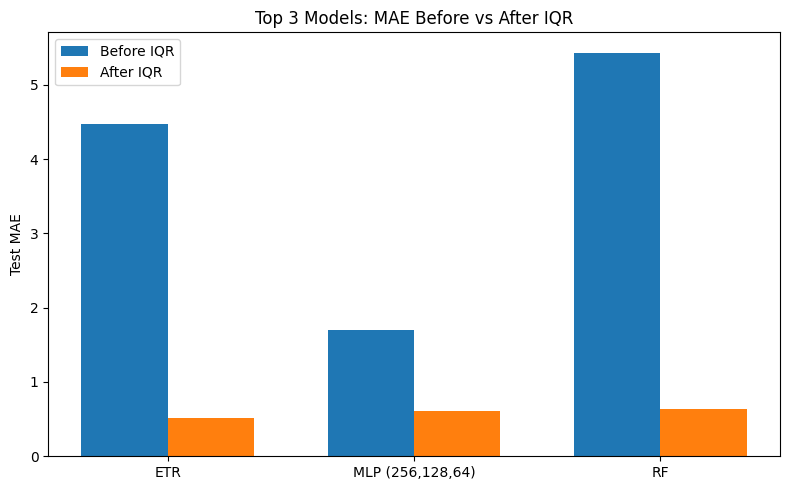

In [47]:
# ==== Experiments over SPATIAL / TEMPORAL / SPATIAL+TEMPORAL (Train & Test: multi-metric score) ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge, HuberRegressor
from sklearn.neural_network import MLPRegressor
#from xgboost import XGBRegressor

# ---------------- Config ----------------
RANDOM_STATE = 42
TEST_SIZE = 0.20

PATH = r"/Users/izarin2/Desktop/My Research/Project1/Dr Lisong/Dataset/Airsage Dataset/NebraskaLakes_Cleaned_round.csv"

# ---------------- Load ----------------
df = pd.read_csv(PATH, low_memory=False)
df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d", errors="coerce")
df["count"] = pd.to_numeric(df["count"], errors="coerce")
df = df.dropna(subset=["date","count"]).copy()

# Ensure we have a POI id
if "poi_id" not in df.columns:
    for alt in ["poi","lake_id","id","POI_ID","POIID","site_id"]:
        if alt in df.columns:
            df = df.rename(columns={alt: "poi_id"})
            break
if "poi_id" not in df.columns:
    df["poi_id"] = 0

# ---------------- Save dataset BEFORE IQR ----------------
df_before_iqr = df.copy()

# ---------------- IQR outlier trimming (exclude target) ----------------
candidate_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
all_features = [c for c in candidate_numeric if c != "count"]
all_features = [c for c in all_features
                if df[c].notna().sum() > 0 and df[c].nunique(dropna=True) > 1]

'''for col in all_features:
   Q1 = df[col].quantile(0.25)
   Q3 = df[col].quantile(0.75)
   IQR = Q3 - Q1
   if pd.isna(IQR) or IQR == 0:
       continue
   lower = Q1 - 1.5 * IQR
   upper = Q3 + 1.5 * IQR
   df = df[(df[col] >= lower) & (df[col] <= upper)]
if len(df) == 0:
   raise RuntimeError("All rows were filtered by the IQR loop. Relax bounds or skip constant columns.")
'''
# ---------------- Rows before IQR ----------------
rows_before_iqr = len(df)

print("\n" + "=" * 60)
print("IQR FILTERING SUMMARY")
print("=" * 60)
print(f"Rows before IQR filtering : {rows_before_iqr:,}")
k = 2# <-- more gentle than 1.5; try 2.0 or 3.0
mask = pd.Series(True, index=df.index)

for col in all_features:
    s = df[col]
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    if pd.isna(IQR) or IQR == 0:
        continue
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    mask &= s.between(lower, upper) | s.isna()

df = df[mask].copy()

# ---------------- Rows after IQR ----------------
rows_after_iqr = len(df)
rows_removed_iqr = rows_before_iqr - rows_after_iqr
pct_removed_iqr = (
    rows_removed_iqr / rows_before_iqr * 100
    if rows_before_iqr > 0 else 0
)

print(f"Rows after IQR filtering  : {rows_after_iqr:,}")
print(f"Rows removed by IQR       : {rows_removed_iqr:,}")
print(f"Percent removed           : {pct_removed_iqr:.2f}%")
print("=" * 60)



if len(df) == 0:
    raise RuntimeError("All rows were filtered by IQR. Increase k (e.g., 3.0) or skip trimming.")

# ---------------- Save dataset AFTER IQR ----------------
df_after_iqr = df.copy()

# ---------------- SPATIAL features (numeric-only + poi_id_code; drop known leaky cols) ----------------
df["poi_id_code"] = df["poi_id"].astype("category").cat.codes

spatial_exact = {"poi_id","poi","home_origin","home_county","home_state","home_msa",
                 "county","state","msa","lat","lon","latitude","longitude","region","district"}
spatial_prefixes = ("home_","male_","female_","income_")
spatial_race = {"white","black","native_american","asian","hawaiian_pacific","other",
                "two_with_other","two_ex_other_and_three_plus"}

spatial_cols = []
for c in df.columns:
    if (c in spatial_exact) or (c in spatial_race) or any(c.startswith(p) for p in spatial_prefixes):
        spatial_cols.append(c)

spatial_numeric = [c for c in spatial_cols if pd.api.types.is_numeric_dtype(df[c]) and c != "count"]
if "poi_id_code" not in spatial_numeric:
    spatial_numeric.append("poi_id_code")

LEAKY = {
    'white',#'income_75_100','male_45_49','female_50_54','female_45_49','male_55_59',
   # 'income_30_35','male_5_9','income_25_30','female_55_59','male_10_14','male_50_54',
   # 'income_60_75','income_50_60','male_35_39','female_35_39','income_40_45','female_5_9',
   # 'female_30_34','female_10_14','income_100_125'
}
spatial_numeric = [c for c in spatial_numeric if c not in LEAKY]

# ---------------- Temporal (interpretable, but using only hours for TEMPORAL combo) ----------------
df["dow"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)
df["week"]  = df["date"].dt.isocalendar().week.astype(int)
df["month"] = df["date"].dt.month
df["day"]   = df["date"].dt.day
def _m2s(m): return 0 if m in (12,1,2) else 1 if m in (3,4,5) else 2 if m in (6,7,8) else 3
df["season"] = df["month"].apply(lambda m: _m2s(int(m)))
df["date_ordinal"] = df["date"].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)
df["is_month_start"]   = df["date"].dt.is_month_start.astype(int)
df["is_month_end"]     = df["date"].dt.is_month_end.astype(int)
df["is_quarter_start"] = df["date"].dt.is_quarter_start.astype(int)
df["is_quarter_end"]   = df["date"].dt.is_quarter_end.astype(int)

# hour-of-day columns like hh00..hh23 if present
hour_cols = [c for c in df.columns if isinstance(c, str)
             and len(c) == 4 and c.startswith("hh") and c[2:].isdigit()]

#TEMPORAL with calendar + hours (commented out per your choice)
FEATS_TEMPORAL_ALL = [
   "is_weekend","season","month","week","dow","day","date_ordinal",
   "is_month_start","is_month_end","is_quarter_start","is_quarter_end"
] + [c for c in hour_cols if c in df.columns]

#FEATS_TEMPORAL_ALL = hour_cols[:]

# ---- SIMPLE lag for TEMPORAL only (lag1; leak-safe) ----
keys = ["poi_id","date"] if "poi_id" in df.columns else ["date"]
df_lag = df[keys + ["count"]].sort_values(keys).copy()

# ---- Fast leak-safe lag1 (no merge, stable sort, original order preserved) ----
orig_idx = df.index

if "poi_id" in df.columns:
    s = (
        df[["poi_id", "date", "count"]]
        .sort_values(["poi_id", "date"], kind="mergesort")
        .groupby("poi_id", sort=False)["count"]
        .shift(1)
    )
else:
    s = (
        df[["date", "count"]]
        .sort_values(["date"], kind="mergesort")["count"]
        .shift(1)
    )

#f["lag1"] = s.reindex(orig_idx)

# (You currently don't include lag1 in TEMPORAL; keeping that as-is)
# if "lag1" not in FEATS_TEMPORAL_ALL:
#EATS_TEMPORAL_ALL.append("lag1")

# ---------------- Feature combos ----------------
BASE_COMBOS = {
   # "SPATIAL": spatial_numeric,
  #  "TEMPORAL": FEATS_TEMPORAL_ALL,
    "SPATIAL+TEMPORAL": list(dict.fromkeys(spatial_numeric + FEATS_TEMPORAL_ALL)),
}

# ---------------- Models (existing + MLPs) ----------------
MODELS = [
    ("RF",   RandomForestRegressor(n_estimators=600, max_depth=None,
                                   min_samples_split=2, min_samples_leaf=1,
                                   max_features="sqrt", n_jobs=-1, random_state=RANDOM_STATE)),
    ("ETR",  ExtraTreesRegressor(n_estimators=600, max_depth=None,
                                 min_samples_leaf=1, max_features="sqrt",
                                 n_jobs=-1, random_state=RANDOM_STATE)),
    ("GBR",  GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=300, learning_rate=0.05, max_depth=3)),
    ("DT",   DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE)),
   # ("XGB",  XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
   #                       subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
   #                       n_jobs=-1, random_state=RANDOM_STATE, tree_method="hist")),
    ("LR",   LinearRegression()),
    ("Ridge",Ridge(alpha=1.0)),
    ("Bayes",BayesianRidge()),
    ("Huber",HuberRegressor(epsilon=1.35)),

    ("MLP (64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(64,),
                             activation="relu", solver="adam",
                             learning_rate_init=1e-3, max_iter=800,
                             early_stopping=True, n_iter_no_change=20,
                             random_state=RANDOM_STATE))
    ])),
    ("MLP (128,64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(128,64),
                             activation="relu", solver="adam",
                             learning_rate_init=8e-4, alpha=1e-4,
                             max_iter=1000, early_stopping=True,
                             n_iter_no_change=20, random_state=RANDOM_STATE))
    ])),
    ("MLP (256,128,64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(256,128,64),
                             activation="relu", solver="adam",
                             learning_rate_init=7e-4, alpha=2e-4,
                             max_iter=1200, early_stopping=True,
                             n_iter_no_change=25, random_state=RANDOM_STATE))
    ])),
]

# ---------------- Helpers ----------------
def build_Xy(_df, feats):
    X = _df[feats].copy()
    y = _df["count"].astype(float).copy()
    mask = X.notna().all(axis=1)
    return X[mask].to_numpy(np.float32), y[mask].to_numpy(np.float32)

def _norm_series(series, higher_is_better=True):
    """Normalize a metric to [0,1]; handle NaNs & constant series."""
    vals = series.to_numpy(dtype=float)
    mask = np.isfinite(vals)
    if mask.sum() <= 1:
        return pd.Series(0.5, index=series.index)
    vmin = np.nanmin(vals[mask])
    vmax = np.nanmax(vals[mask])
    if vmax == vmin:
        return pd.Series(0.5, index=series.index)
    if higher_is_better:
        norm = (vals - vmin) / (vmax - vmin)
    else:
        norm = (vmax - vals) / (vmax - vmin)
    norm[~mask] = 0.5
    return pd.Series(norm, index=series.index)

def eval_models_both(X, y, models, combo_name):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    # make binary "busy" labels for test (for P/R/AUC)
    thr = np.quantile(y_te, 0.8)   # top 20% busy
    y_te_bin = (y_te >= thr).astype(int)

    rows = []
    for name, mdl in models:
        m = clone(mdl)
        m.fit(X_tr, y_tr)
        pred_tr = m.predict(X_tr)
        pred_te = m.predict(X_te)

        train_r2 = r2_score(y_tr, pred_tr)
        train_mae = mean_absolute_error(y_tr, pred_tr)

        test_r2  = r2_score(y_te, pred_te)
        test_mae = mean_absolute_error(y_te, pred_te)
        test_mse = mean_squared_error(y_te, pred_te)

        # classification-style metrics on test
        try:
            if len(np.unique(y_te_bin)) < 2:
                test_auc = np.nan
            else:
                test_auc = roc_auc_score(y_te_bin, pred_te)
        except Exception:
            test_auc = np.nan

        try:
            y_pred_bin = (pred_te >= thr).astype(int)
            test_p = precision_score(y_te_bin, y_pred_bin, zero_division=0)
            test_r = recall_score(y_te_bin, y_pred_bin, zero_division=0)
        except Exception:
            test_p, test_r = np.nan, np.nan

        rows.append({
            "Combo": combo_name,
            "Model": name,
            "Train_R2":  train_r2,
            "Train_MAE": train_mae,
            "Test_R2":   test_r2,
            "Test_MAE":  test_mae,
            "Test_MSE":  test_mse,
            "Test_AUC":  test_auc,
            "Test_P":    test_p,
            "Test_R":    test_r,
        })

    res = pd.DataFrame(rows)

    # build combined score using all test metrics
    for mname in ["Test_R2", "Test_AUC", "Test_P", "Test_R"]:
        res[f"{mname}_N"] = _norm_series(res[mname], higher_is_better=True)
    for mname in ["Test_MAE", "Test_MSE"]:
        res[f"{mname}_N"] = _norm_series(res[mname], higher_is_better=False)

    norm_cols = [
        "Test_R2_N", "Test_AUC_N", "Test_P_N", "Test_R_N",
        "Test_MAE_N", "Test_MSE_N",
    ]
    res["Score"] = res[norm_cols].mean(axis=1)

    res = (res
           .sort_values(["Combo","Score"], ascending=[True, False])
           .reset_index(drop=True))
    return res

# ---------------- Run all combos ----------------
all_results = []
for combo_name, feats in BASE_COMBOS.items():
    if not feats:
        continue
    X, y = build_Xy(df, feats)
    if len(X) == 0 or X.shape[1] == 0:
        continue
    res = eval_models_both(X, y, MODELS, combo_name)
    all_results.append(res)

final_tbl = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

# ---------------- Print full table ----------------
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

print("\n=== Train/Test metrics by Combo (sorted by Score desc) ===")
if not final_tbl.empty:
    print(final_tbl[[
            "Combo","Model","Score",
            "Train_R2","Train_MAE",
            "Test_R2","Test_MAE","Test_MSE",
            "Test_AUC","Test_P","Test_R"
        ]].sort_values(["Combo","Score"], ascending=[True, False])
          .to_string(index=False, float_format=lambda x: f"{x:.3f}"))
else:
    print("No results — check that features exist for the selected combos.")

# ---------------- TOP 3 per Combo (by combined Score) ----------------
if not final_tbl.empty:
    ranked = (final_tbl
              .sort_values(["Score"], ascending=False)
              .groupby("Combo", group_keys=False)
              .head(3)
              .reset_index(drop=True))

    print("\n=== TOP 3 MODELS PER COMBO (by combined Score) ===")
    print(ranked[[
            "Combo","Model","Score",
            "Train_R2","Train_MAE",
            "Test_R2","Test_MAE","Test_MSE",
            "Test_AUC","Test_P","Test_R"
        ]].to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# =====================================================================================
# ===================== MAE COMPARISON: BEFORE vs AFTER IQR ===========================
# =====================================================================================

def run_pipeline_for_iqr_stage(_df, stage_name):
    _df = _df.copy()

    _df["poi_id_code"] = _df["poi_id"].astype("category").cat.codes

    spatial_cols_stage = []
    for c in _df.columns:
        if (
            c in spatial_exact
            or c in spatial_race
            or any(str(c).startswith(p) for p in spatial_prefixes)
        ):
            spatial_cols_stage.append(c)

    spatial_numeric_stage = [
        c for c in spatial_cols_stage
        if pd.api.types.is_numeric_dtype(_df[c]) and c != "count"
    ]

    if "poi_id_code" not in spatial_numeric_stage:
        spatial_numeric_stage.append("poi_id_code")

    spatial_numeric_stage = [
        c for c in spatial_numeric_stage
        if c not in LEAKY
    ]

    _df["dow"] = _df["date"].dt.dayofweek
    _df["is_weekend"] = (_df["dow"] >= 5).astype(int)
    _df["week"] = _df["date"].dt.isocalendar().week.astype(int)
    _df["month"] = _df["date"].dt.month
    _df["day"] = _df["date"].dt.day

    _df["season"] = _df["month"].apply(lambda m: _m2s(int(m)))
    _df["date_ordinal"] = _df["date"].map(
        lambda x: x.toordinal() if pd.notnull(x) else np.nan
    )

    _df["is_month_start"] = _df["date"].dt.is_month_start.astype(int)
    _df["is_month_end"] = _df["date"].dt.is_month_end.astype(int)
    _df["is_quarter_start"] = _df["date"].dt.is_quarter_start.astype(int)
    _df["is_quarter_end"] = _df["date"].dt.is_quarter_end.astype(int)

    hour_cols_stage = [
        c for c in _df.columns
        if isinstance(c, str)
        and len(c) == 4
        and c.startswith("hh")
        and c[2:].isdigit()
    ]

    feats_temporal_stage = [
        "is_weekend", "season", "month", "week", "dow", "day", "date_ordinal",
        "is_month_start", "is_month_end", "is_quarter_start", "is_quarter_end"
    ] + [c for c in hour_cols_stage if c in _df.columns]

    base_combos_stage = {
        "SPATIAL+TEMPORAL": list(
            dict.fromkeys(spatial_numeric_stage + feats_temporal_stage)
        ),
    }

    all_results_stage = []

    for combo_name, feats in base_combos_stage.items():
        feats = [f for f in feats if f in _df.columns]

        if not feats:
            continue

        X, y = build_Xy(_df, feats)

        if len(X) == 0 or X.shape[1] == 0:
            continue

        res = eval_models_both(X, y, MODELS, combo_name)
        res.insert(0, "Stage", stage_name)
        all_results_stage.append(res)

    return (
        pd.concat(all_results_stage, ignore_index=True)
        if all_results_stage
        else pd.DataFrame()
    )


final_tbl_before_iqr = run_pipeline_for_iqr_stage(df_before_iqr, "BEFORE_IQR")
final_tbl_after_iqr = run_pipeline_for_iqr_stage(df_after_iqr, "AFTER_IQR")

tbl_iqr_mae_compare = pd.concat(
    [final_tbl_before_iqr, final_tbl_after_iqr],
    ignore_index=True
)

print("\n" + "=" * 70)
print("MAE COMPARISON: BEFORE vs AFTER IQR")
print("=" * 70)

# ---------------- Plot MAE before vs after IQR (TOP 3 ONLY) ----------------

if not final_tbl_before_iqr.empty and not final_tbl_after_iqr.empty:

    before_mae = (
        final_tbl_before_iqr
        .groupby("Model")["Test_MAE"]
        .mean()
    )

    after_mae = (
        final_tbl_after_iqr
        .groupby("Model")["Test_MAE"]
        .mean()
    )

    # Combine before and after MAE
    mae_compare = pd.concat(
        [before_mae.rename("Before"),
         after_mae.rename("After")],
        axis=1
    )

    # Best MAE for each model
    mae_compare["Best_MAE"] = mae_compare.min(axis=1)

    # -------- Select ONLY top 3 models --------
    top3_models = (
        mae_compare
        .sort_values("Best_MAE")
        .head(3)
        .index
        .tolist()
    )

    before_mae = before_mae.reindex(top3_models)
    after_mae = after_mae.reindex(top3_models)

    x = np.arange(len(top3_models))
    w = 0.35

    plt.figure(figsize=(8,5))

    plt.bar(
        x - w/2,
        before_mae.values,
        width=w,
        label="Before IQR"
    )

    plt.bar(
        x + w/2,
        after_mae.values,
        width=w,
        label="After IQR"
    )

    plt.xticks(x, top3_models)
    plt.ylabel("Test MAE")
    plt.title("Top 3 Models: MAE Before vs After IQR")
    plt.legend()
    plt.tight_layout()
    plt.show()
    



IQR FILTERING SUMMARY
Rows before IQR filtering : 123,627
Rows after IQR filtering  : 72,377
Rows removed by IQR       : 51,250
Percent removed           : 41.46%


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.557e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)



=== Train/Test metrics by Combo (sorted by Score desc) ===
           Combo            Model  Score  Train_R2  Train_MAE  Test_R2  Test_MAE  Test_MSE  Test_AUC  Test_P  Test_R
SPATIAL+TEMPORAL MLP (256,128,64)  0.996     0.999      0.349    0.992     0.615     2.104     0.999   0.990   0.962
SPATIAL+TEMPORAL     MLP (128,64)  0.993     0.998      0.477    0.990     0.649     2.506     0.999   0.990   0.955
SPATIAL+TEMPORAL              ETR  0.992     1.000      0.000    0.985     0.519     3.741     0.999   0.992   0.953
SPATIAL+TEMPORAL         MLP (64)  0.988     0.997      0.650    0.989     0.744     2.873     0.999   0.988   0.953
SPATIAL+TEMPORAL               RF  0.983     0.998      0.237    0.982     0.636     4.436     0.999   0.990   0.939
SPATIAL+TEMPORAL            Bayes  0.982     0.989      0.868    0.983     0.877     4.236     0.998   0.980   0.965
SPATIAL+TEMPORAL            Ridge  0.982     0.989      0.868    0.983     0.877     4.237     0.998   0.980   0.964
SPAT

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.34789e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.557e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)



MAE COMPARISON: BEFORE vs AFTER IQR


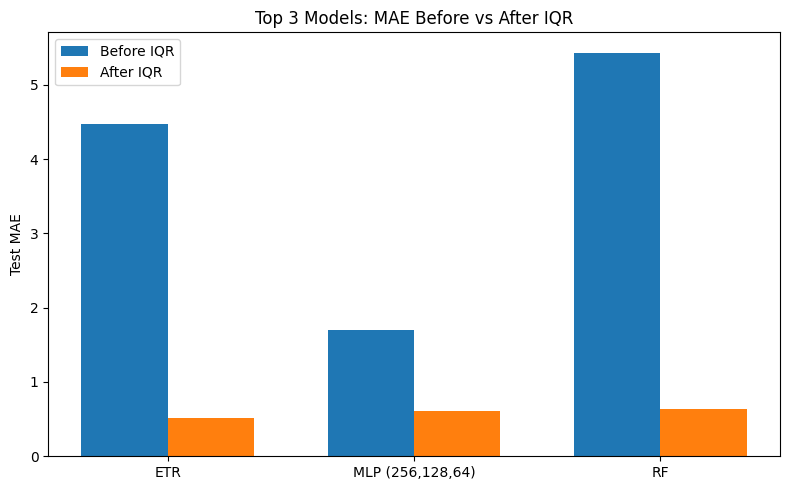

In [48]:
# ==== Experiments over SPATIAL / TEMPORAL / SPATIAL+TEMPORAL (Train & Test: multi-metric score) ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge, HuberRegressor
from sklearn.neural_network import MLPRegressor
#from xgboost import XGBRegressor

# ---------------- Config ----------------
RANDOM_STATE = 42
TEST_SIZE = 0.20

PATH = r"/Users/izarin2/Desktop/My Research/Project1/Dr Lisong/Dataset/Airsage Dataset/NebraskaLakes_Cleaned_round.csv"

# ---------------- Load ----------------
df = pd.read_csv(PATH, low_memory=False)
df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d", errors="coerce")
df["count"] = pd.to_numeric(df["count"], errors="coerce")
df = df.dropna(subset=["date","count"]).copy()

# Ensure we have a POI id
if "poi_id" not in df.columns:
    for alt in ["poi","lake_id","id","POI_ID","POIID","site_id"]:
        if alt in df.columns:
            df = df.rename(columns={alt: "poi_id"})
            break
if "poi_id" not in df.columns:
    df["poi_id"] = 0

# ---------------- Save dataset BEFORE IQR ----------------
df_before_iqr = df.copy()

# ---------------- IQR outlier trimming (exclude target) ----------------
candidate_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
all_features = [c for c in candidate_numeric if c != "count"]
all_features = [c for c in all_features
                if df[c].notna().sum() > 0 and df[c].nunique(dropna=True) > 1]

'''for col in all_features:
   Q1 = df[col].quantile(0.25)
   Q3 = df[col].quantile(0.75)
   IQR = Q3 - Q1
   if pd.isna(IQR) or IQR == 0:
       continue
   lower = Q1 - 1.5 * IQR
   upper = Q3 + 1.5 * IQR
   df = df[(df[col] >= lower) & (df[col] <= upper)]
if len(df) == 0:
   raise RuntimeError("All rows were filtered by the IQR loop. Relax bounds or skip constant columns.")
'''
# ---------------- Rows before IQR ----------------
rows_before_iqr = len(df)

print("\n" + "=" * 60)
print("IQR FILTERING SUMMARY")
print("=" * 60)
print(f"Rows before IQR filtering : {rows_before_iqr:,}")
k = 2# <-- more gentle than 1.5; try 2.0 or 3.0
mask = pd.Series(True, index=df.index)

for col in all_features:
    s = df[col]
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    if pd.isna(IQR) or IQR == 0:
        continue
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    mask &= s.between(lower, upper) | s.isna()

df = df[mask].copy()

# ---------------- Rows after IQR ----------------
rows_after_iqr = len(df)
rows_removed_iqr = rows_before_iqr - rows_after_iqr
pct_removed_iqr = (
    rows_removed_iqr / rows_before_iqr * 100
    if rows_before_iqr > 0 else 0
)

print(f"Rows after IQR filtering  : {rows_after_iqr:,}")
print(f"Rows removed by IQR       : {rows_removed_iqr:,}")
print(f"Percent removed           : {pct_removed_iqr:.2f}%")
print("=" * 60)



if len(df) == 0:
    raise RuntimeError("All rows were filtered by IQR. Increase k (e.g., 3.0) or skip trimming.")

# ---------------- Save dataset AFTER IQR ----------------
df_after_iqr = df.copy()

# ---------------- SPATIAL features (numeric-only + poi_id_code; drop known leaky cols) ----------------
df["poi_id_code"] = df["poi_id"].astype("category").cat.codes

spatial_exact = {"poi_id","poi","home_origin","home_county","home_state","home_msa",
                 "county","state","msa","lat","lon","latitude","longitude","region","district"}
spatial_prefixes = ("home_","male_","female_","income_")
spatial_race = {"white","black","native_american","asian","hawaiian_pacific","other",
                "two_with_other","two_ex_other_and_three_plus"}

spatial_cols = []
for c in df.columns:
    if (c in spatial_exact) or (c in spatial_race) or any(c.startswith(p) for p in spatial_prefixes):
        spatial_cols.append(c)

spatial_numeric = [c for c in spatial_cols if pd.api.types.is_numeric_dtype(df[c]) and c != "count"]
if "poi_id_code" not in spatial_numeric:
    spatial_numeric.append("poi_id_code")

LEAKY = {
    'white',#'income_75_100','male_45_49','female_50_54','female_45_49','male_55_59',
   # 'income_30_35','male_5_9','income_25_30','female_55_59','male_10_14','male_50_54',
   # 'income_60_75','income_50_60','male_35_39','female_35_39','income_40_45','female_5_9',
   # 'female_30_34','female_10_14','income_100_125'
}
spatial_numeric = [c for c in spatial_numeric if c not in LEAKY]

# ---------------- Temporal (interpretable, but using only hours for TEMPORAL combo) ----------------
df["dow"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)
df["week"]  = df["date"].dt.isocalendar().week.astype(int)
df["month"] = df["date"].dt.month
df["day"]   = df["date"].dt.day
def _m2s(m): return 0 if m in (12,1,2) else 1 if m in (3,4,5) else 2 if m in (6,7,8) else 3
df["season"] = df["month"].apply(lambda m: _m2s(int(m)))
df["date_ordinal"] = df["date"].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)
df["is_month_start"]   = df["date"].dt.is_month_start.astype(int)
df["is_month_end"]     = df["date"].dt.is_month_end.astype(int)
df["is_quarter_start"] = df["date"].dt.is_quarter_start.astype(int)
df["is_quarter_end"]   = df["date"].dt.is_quarter_end.astype(int)

# hour-of-day columns like hh00..hh23 if present
hour_cols = [c for c in df.columns if isinstance(c, str)
             and len(c) == 4 and c.startswith("hh") and c[2:].isdigit()]

#TEMPORAL with calendar + hours (commented out per your choice)
FEATS_TEMPORAL_ALL = [
   "is_weekend","season","month","week","dow","day","date_ordinal",
   "is_month_start","is_month_end","is_quarter_start","is_quarter_end"
] + [c for c in hour_cols if c in df.columns]

#FEATS_TEMPORAL_ALL = hour_cols[:]

# ---- SIMPLE lag for TEMPORAL only (lag1; leak-safe) ----
keys = ["poi_id","date"] if "poi_id" in df.columns else ["date"]
df_lag = df[keys + ["count"]].sort_values(keys).copy()

# ---- Fast leak-safe lag1 (no merge, stable sort, original order preserved) ----
orig_idx = df.index

if "poi_id" in df.columns:
    s = (
        df[["poi_id", "date", "count"]]
        .sort_values(["poi_id", "date"], kind="mergesort")
        .groupby("poi_id", sort=False)["count"]
        .shift(1)
    )
else:
    s = (
        df[["date", "count"]]
        .sort_values(["date"], kind="mergesort")["count"]
        .shift(1)
    )

#f["lag1"] = s.reindex(orig_idx)

# (You currently don't include lag1 in TEMPORAL; keeping that as-is)
# if "lag1" not in FEATS_TEMPORAL_ALL:
#EATS_TEMPORAL_ALL.append("lag1")

# ---------------- Feature combos ----------------
BASE_COMBOS = {
   # "SPATIAL": spatial_numeric,
  #  "TEMPORAL": FEATS_TEMPORAL_ALL,
    "SPATIAL+TEMPORAL": list(dict.fromkeys(spatial_numeric + FEATS_TEMPORAL_ALL)),
}

# ---------------- Models (existing + MLPs) ----------------
MODELS = [
    ("RF",   RandomForestRegressor(n_estimators=600, max_depth=None,
                                   min_samples_split=2, min_samples_leaf=1,
                                   max_features="sqrt", n_jobs=-1, random_state=RANDOM_STATE)),
    ("ETR",  ExtraTreesRegressor(n_estimators=600, max_depth=None,
                                 min_samples_leaf=1, max_features="sqrt",
                                 n_jobs=-1, random_state=RANDOM_STATE)),
    ("GBR",  GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=300, learning_rate=0.05, max_depth=3)),
    ("DT",   DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE)),
   # ("XGB",  XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
   #                       subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
   #                       n_jobs=-1, random_state=RANDOM_STATE, tree_method="hist")),
    ("LR",   LinearRegression()),
    ("Ridge",Ridge(alpha=1.0)),
    ("Bayes",BayesianRidge()),
    ("Huber",HuberRegressor(epsilon=1.35)),

    ("MLP (64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(64,),
                             activation="relu", solver="adam",
                             learning_rate_init=1e-3, max_iter=800,
                             early_stopping=True, n_iter_no_change=20,
                             random_state=RANDOM_STATE))
    ])),
    ("MLP (128,64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(128,64),
                             activation="relu", solver="adam",
                             learning_rate_init=8e-4, alpha=1e-4,
                             max_iter=1000, early_stopping=True,
                             n_iter_no_change=20, random_state=RANDOM_STATE))
    ])),
    ("MLP (256,128,64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(256,128,64),
                             activation="relu", solver="adam",
                             learning_rate_init=7e-4, alpha=2e-4,
                             max_iter=1200, early_stopping=True,
                             n_iter_no_change=25, random_state=RANDOM_STATE))
    ])),
]

# ---------------- Helpers ----------------
def build_Xy(_df, feats):
    X = _df[feats].copy()
    y = _df["count"].astype(float).copy()
    mask = X.notna().all(axis=1)
    return X[mask].to_numpy(np.float32), y[mask].to_numpy(np.float32)

def _norm_series(series, higher_is_better=True):
    """Normalize a metric to [0,1]; handle NaNs & constant series."""
    vals = series.to_numpy(dtype=float)
    mask = np.isfinite(vals)
    if mask.sum() <= 1:
        return pd.Series(0.5, index=series.index)
    vmin = np.nanmin(vals[mask])
    vmax = np.nanmax(vals[mask])
    if vmax == vmin:
        return pd.Series(0.5, index=series.index)
    if higher_is_better:
        norm = (vals - vmin) / (vmax - vmin)
    else:
        norm = (vmax - vals) / (vmax - vmin)
    norm[~mask] = 0.5
    return pd.Series(norm, index=series.index)

def eval_models_both(X, y, models, combo_name):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    # make binary "busy" labels for test (for P/R/AUC)
    thr = np.quantile(y_te, 0.8)   # top 20% busy
    y_te_bin = (y_te >= thr).astype(int)

    rows = []
    for name, mdl in models:
        m = clone(mdl)
        m.fit(X_tr, y_tr)
        pred_tr = m.predict(X_tr)
        pred_te = m.predict(X_te)

        train_r2 = r2_score(y_tr, pred_tr)
        train_mae = mean_absolute_error(y_tr, pred_tr)

        test_r2  = r2_score(y_te, pred_te)
        test_mae = mean_absolute_error(y_te, pred_te)
        test_mse = mean_squared_error(y_te, pred_te)

        # classification-style metrics on test
        try:
            if len(np.unique(y_te_bin)) < 2:
                test_auc = np.nan
            else:
                test_auc = roc_auc_score(y_te_bin, pred_te)
        except Exception:
            test_auc = np.nan

        try:
            y_pred_bin = (pred_te >= thr).astype(int)
            test_p = precision_score(y_te_bin, y_pred_bin, zero_division=0)
            test_r = recall_score(y_te_bin, y_pred_bin, zero_division=0)
        except Exception:
            test_p, test_r = np.nan, np.nan

        rows.append({
            "Combo": combo_name,
            "Model": name,
            "Train_R2":  train_r2,
            "Train_MAE": train_mae,
            "Test_R2":   test_r2,
            "Test_MAE":  test_mae,
            "Test_MSE":  test_mse,
            "Test_AUC":  test_auc,
            "Test_P":    test_p,
            "Test_R":    test_r,
        })

    res = pd.DataFrame(rows)

    # build combined score using all test metrics
    for mname in ["Test_R2", "Test_AUC", "Test_P", "Test_R"]:
        res[f"{mname}_N"] = _norm_series(res[mname], higher_is_better=True)
    for mname in ["Test_MAE", "Test_MSE"]:
        res[f"{mname}_N"] = _norm_series(res[mname], higher_is_better=False)

    norm_cols = [
        "Test_R2_N", "Test_AUC_N", "Test_P_N", "Test_R_N",
        "Test_MAE_N", "Test_MSE_N",
    ]
    res["Score"] = res[norm_cols].mean(axis=1)

    res = (res
           .sort_values(["Combo","Score"], ascending=[True, False])
           .reset_index(drop=True))
    return res

# ---------------- Run all combos ----------------
all_results = []
for combo_name, feats in BASE_COMBOS.items():
    if not feats:
        continue
    X, y = build_Xy(df, feats)
    if len(X) == 0 or X.shape[1] == 0:
        continue
    res = eval_models_both(X, y, MODELS, combo_name)
    all_results.append(res)

final_tbl = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

# ---------------- Print full table ----------------
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

print("\n=== Train/Test metrics by Combo (sorted by Score desc) ===")
if not final_tbl.empty:
    print(final_tbl[[
            "Combo","Model","Score",
            "Train_R2","Train_MAE",
            "Test_R2","Test_MAE","Test_MSE",
            "Test_AUC","Test_P","Test_R"
        ]].sort_values(["Combo","Score"], ascending=[True, False])
          .to_string(index=False, float_format=lambda x: f"{x:.3f}"))
else:
    print("No results — check that features exist for the selected combos.")

# ---------------- TOP 3 per Combo (by combined Score) ----------------
if not final_tbl.empty:
    ranked = (final_tbl
              .sort_values(["Score"], ascending=False)
              .groupby("Combo", group_keys=False)
              .head(3)
              .reset_index(drop=True))

    print("\n=== TOP 3 MODELS PER COMBO (by combined Score) ===")
    print(ranked[[
            "Combo","Model","Score",
            "Train_R2","Train_MAE",
            "Test_R2","Test_MAE","Test_MSE",
            "Test_AUC","Test_P","Test_R"
        ]].to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# =====================================================================================
# ===================== MAE COMPARISON: BEFORE vs AFTER IQR ===========================
# =====================================================================================

def run_pipeline_for_iqr_stage(_df, stage_name):
    _df = _df.copy()

    _df["poi_id_code"] = _df["poi_id"].astype("category").cat.codes

    spatial_cols_stage = []
    for c in _df.columns:
        if (
            c in spatial_exact
            or c in spatial_race
            or any(str(c).startswith(p) for p in spatial_prefixes)
        ):
            spatial_cols_stage.append(c)

    spatial_numeric_stage = [
        c for c in spatial_cols_stage
        if pd.api.types.is_numeric_dtype(_df[c]) and c != "count"
    ]

    if "poi_id_code" not in spatial_numeric_stage:
        spatial_numeric_stage.append("poi_id_code")

    spatial_numeric_stage = [
        c for c in spatial_numeric_stage
        if c not in LEAKY
    ]

    _df["dow"] = _df["date"].dt.dayofweek
    _df["is_weekend"] = (_df["dow"] >= 5).astype(int)
    _df["week"] = _df["date"].dt.isocalendar().week.astype(int)
    _df["month"] = _df["date"].dt.month
    _df["day"] = _df["date"].dt.day

    _df["season"] = _df["month"].apply(lambda m: _m2s(int(m)))
    _df["date_ordinal"] = _df["date"].map(
        lambda x: x.toordinal() if pd.notnull(x) else np.nan
    )

    _df["is_month_start"] = _df["date"].dt.is_month_start.astype(int)
    _df["is_month_end"] = _df["date"].dt.is_month_end.astype(int)
    _df["is_quarter_start"] = _df["date"].dt.is_quarter_start.astype(int)
    _df["is_quarter_end"] = _df["date"].dt.is_quarter_end.astype(int)

    hour_cols_stage = [
        c for c in _df.columns
        if isinstance(c, str)
        and len(c) == 4
        and c.startswith("hh")
        and c[2:].isdigit()
    ]

    feats_temporal_stage = [
        "is_weekend", "season", "month", "week", "dow", "day", "date_ordinal",
        "is_month_start", "is_month_end", "is_quarter_start", "is_quarter_end"
    ] + [c for c in hour_cols_stage if c in _df.columns]

    base_combos_stage = {
        "SPATIAL+TEMPORAL": list(
            dict.fromkeys(spatial_numeric_stage + feats_temporal_stage)
        ),
    }

    all_results_stage = []

    for combo_name, feats in base_combos_stage.items():
        feats = [f for f in feats if f in _df.columns]

        if not feats:
            continue

        X, y = build_Xy(_df, feats)

        if len(X) == 0 or X.shape[1] == 0:
            continue

        res = eval_models_both(X, y, MODELS, combo_name)
        res.insert(0, "Stage", stage_name)
        all_results_stage.append(res)

    return (
        pd.concat(all_results_stage, ignore_index=True)
        if all_results_stage
        else pd.DataFrame()
    )


final_tbl_before_iqr = run_pipeline_for_iqr_stage(df_before_iqr, "BEFORE_IQR")
final_tbl_after_iqr = run_pipeline_for_iqr_stage(df_after_iqr, "AFTER_IQR")

tbl_iqr_mae_compare = pd.concat(
    [final_tbl_before_iqr, final_tbl_after_iqr],
    ignore_index=True
)

print("\n" + "=" * 70)
print("MAE COMPARISON: BEFORE vs AFTER IQR")
print("=" * 70)

# ---------------- Plot MAE before vs after IQR (TOP 3 ONLY) ----------------

if not final_tbl_before_iqr.empty and not final_tbl_after_iqr.empty:

    before_mae = (
        final_tbl_before_iqr
        .groupby("Model")["Test_MAE"]
        .mean()
    )

    after_mae = (
        final_tbl_after_iqr
        .groupby("Model")["Test_MAE"]
        .mean()
    )

    # Combine before and after MAE
    mae_compare = pd.concat(
        [before_mae.rename("Before"),
         after_mae.rename("After")],
        axis=1
    )

    # Best MAE for each model
    mae_compare["Best_MAE"] = mae_compare.min(axis=1)

    # -------- Select ONLY top 3 models --------
    top3_models = (
        mae_compare
        .sort_values("Best_MAE")
        .head(3)
        .index
        .tolist()
    )

    before_mae = before_mae.reindex(top3_models)
    after_mae = after_mae.reindex(top3_models)

    x = np.arange(len(top3_models))
    w = 0.35

    plt.figure(figsize=(8,5))

    plt.bar(
        x - w/2,
        before_mae.values,
        width=w,
        label="Before IQR"
    )

    plt.bar(
        x + w/2,
        after_mae.values,
        width=w,
        label="After IQR"
    )

    plt.xticks(x, top3_models)
    plt.ylabel("Test MAE")
    plt.title("Top 3 Models: MAE Before vs After IQR")
    plt.legend()
    plt.tight_layout()
    plt.show()
    


Using Lag Features.
Lag means using the previous day's visitor count to help predict today's visitor count 
Example: Yesterday


Rows BEFORE IQR saved for comparison: 123,627

IQR FILTERING SUMMARY
Rows before IQR filtering : 123,627
Rows after IQR filtering  : 80,216
Rows removed by IQR       : 43,411
Percent removed           : 35.11%
Rows AFTER IQR saved for comparison : 80,216


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.16163e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)



=== Train/Test metrics by Combo (sorted by Score desc) ===
           Combo            Model  Score  Train_R2  Train_MAE  Test_R2  Test_MAE  Test_MSE  Test_AUC  Test_P  Test_R
SPATIAL+TEMPORAL MLP (256,128,64)  0.992     0.999      0.448    0.991     0.640     3.363     1.000   0.986   0.971
SPATIAL+TEMPORAL              ETR  0.989     1.000      0.000    0.980     0.559     7.428     0.999   0.992   0.971
SPATIAL+TEMPORAL     MLP (128,64)  0.986     0.998      0.619    0.989     0.733     4.018     1.000   0.987   0.964
SPATIAL+TEMPORAL            Ridge  0.981     0.993      0.841    0.984     0.851     6.141     0.999   0.982   0.977
SPATIAL+TEMPORAL            Bayes  0.981     0.993      0.841    0.984     0.851     6.141     0.999   0.982   0.976
SPATIAL+TEMPORAL         MLP (64)  0.981     0.997      0.702    0.987     0.787     5.081     1.000   0.984   0.965
SPATIAL+TEMPORAL               RF  0.976     0.999      0.257    0.979     0.698     8.040     0.999   0.991   0.954
SPAT

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.16163e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.14346e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


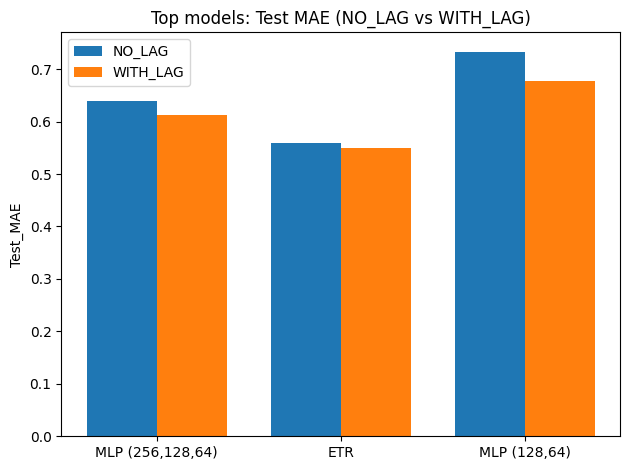

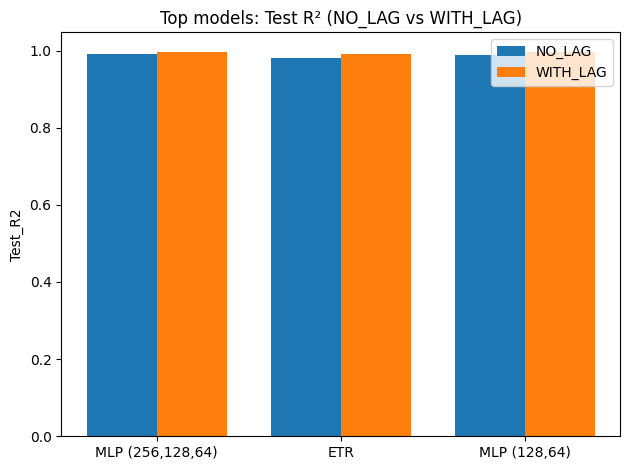

In [49]:
# ==== Experiments over SPATIAL / TEMPORAL / SPATIAL+TEMPORAL (Train & Test: multi-metric score)
#      + Compare WITH vs WITHOUT lag1 (single-split) + Visualize best-3 MODELS (not hybrids)
# NOTE: Keeps your existing logic; only adds the lag-compare + plots at the end.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge, HuberRegressor
from sklearn.neural_network import MLPRegressor

# ---------------- Config ----------------
RANDOM_STATE = 42
TEST_SIZE = 0.20

PATH = r"/Users/izarin2/Desktop/My Research/Project1/Dr Lisong/Dataset/Airsage Dataset/NebraskaLakes_Cleaned_round.csv"

# ---------------- Load ----------------
df = pd.read_csv(PATH, low_memory=False)
df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d", errors="coerce")
df["count"] = pd.to_numeric(df["count"], errors="coerce")
df = df.dropna(subset=["date","count"]).copy()

# Ensure we have a POI id
if "poi_id" not in df.columns:
    for alt in ["poi","lake_id","id","POI_ID","POIID","site_id"]:
        if alt in df.columns:
            df = df.rename(columns={alt: "poi_id"})
            break
if "poi_id" not in df.columns:
    df["poi_id"] = 0

# ---------------- Save dataset BEFORE IQR ----------------
df_before_iqr = df.copy()
print(f"\nRows BEFORE IQR saved for comparison: {len(df_before_iqr):,}")

# ---------------- IQR outlier trimming (exclude target) ----------------
candidate_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
all_features = [c for c in candidate_numeric if c != "count"]
all_features = [c for c in all_features
                if df[c].notna().sum() > 0 and df[c].nunique(dropna=True) > 1]

# ---------------- Rows before IQR ----------------
rows_before_iqr = len(df)

print("\n" + "=" * 60)
print("IQR FILTERING SUMMARY")
print("=" * 60)
print(f"Rows before IQR filtering : {rows_before_iqr:,}")
k =3
mask = pd.Series(True, index=df.index)

for col in all_features:
    s = df[col]
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    if pd.isna(IQR) or IQR == 0:
        continue
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    mask &= s.between(lower, upper) | s.isna()

df = df[mask].copy()



# ---------------- Rows after IQR ----------------
rows_after_iqr = len(df)
rows_removed_iqr = rows_before_iqr - rows_after_iqr
pct_removed_iqr = (
    rows_removed_iqr / rows_before_iqr * 100
    if rows_before_iqr > 0 else 0
)

print(f"Rows after IQR filtering  : {rows_after_iqr:,}")
print(f"Rows removed by IQR       : {rows_removed_iqr:,}")
print(f"Percent removed           : {pct_removed_iqr:.2f}%")
print("=" * 60)


if len(df) == 0:
    raise RuntimeError("All rows were filtered by IQR. Increase k (e.g., 3.0) or skip trimming.")

# ---------------- Save dataset AFTER IQR ----------------
df_after_iqr = df.copy()
print(f"Rows AFTER IQR saved for comparison : {len(df_after_iqr):,}")

# ---------------- SPATIAL features (numeric-only + poi_id_code; drop known leaky cols) ----------------
df["poi_id_code"] = df["poi_id"].astype("category").cat.codes

spatial_exact = {"poi_id","poi","home_origin","home_county","home_state","home_msa",
                 "county","state","msa","lat","lon","latitude","longitude","region","district"}
spatial_prefixes = ("home_","male_","female_","income_")
spatial_race = {"white","black","native_american","asian","hawaiian_pacific","other",
                "two_with_other","two_ex_other_and_three_plus"}

spatial_cols = []
for c in df.columns:
    if (c in spatial_exact) or (c in spatial_race) or any(c.startswith(p) for p in spatial_prefixes):
        spatial_cols.append(c)

spatial_numeric = [c for c in spatial_cols if pd.api.types.is_numeric_dtype(df[c]) and c != "count"]
if "poi_id_code" not in spatial_numeric:
    spatial_numeric.append("poi_id_code")

LEAKY = {
    'white',
}
spatial_numeric = [c for c in spatial_numeric if c not in LEAKY]

# ---------------- Temporal (interpretable) ----------------
df["dow"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)
df["week"]  = df["date"].dt.isocalendar().week.astype(int)
df["month"] = df["date"].dt.month
df["day"]   = df["date"].dt.day

def _m2s(m):
    return 0 if m in (12,1,2) else 1 if m in (3,4,5) else 2 if m in (6,7,8) else 3

df["season"] = df["month"].apply(lambda m: _m2s(int(m)))
df["date_ordinal"] = df["date"].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)
df["is_month_start"]   = df["date"].dt.is_month_start.astype(int)
df["is_month_end"]     = df["date"].dt.is_month_end.astype(int)
df["is_quarter_start"] = df["date"].dt.is_quarter_start.astype(int)
df["is_quarter_end"]   = df["date"].dt.is_quarter_end.astype(int)

# hour-of-day columns like hh00..hh23 if present
hour_cols = [c for c in df.columns if isinstance(c, str)
             and len(c) == 4 and c.startswith("hh") and c[2:].isdigit()]

FEATS_TEMPORAL_ALL = [
   "is_weekend","season","month","week","dow","day","date_ordinal",
   "is_month_start","is_month_end","is_quarter_start","is_quarter_end"
] + [c for c in hour_cols if c in df.columns]

# ---- leak-safe lag1 ----
orig_idx = df.index
if "poi_id" in df.columns:
    s = (df[["poi_id", "date", "count"]]
         .sort_values(["poi_id", "date"], kind="mergesort")
         .groupby("poi_id", sort=False)["count"]
         .shift(1))
else:
    s = (df[["date", "count"]]
         .sort_values(["date"], kind="mergesort")["count"]
         .shift(1))

df["lag1"] = s.reindex(orig_idx)

# ---------------- Feature combos (BASE) ----------------
BASE_COMBOS = {
    "SPATIAL+TEMPORAL": list(dict.fromkeys(spatial_numeric + FEATS_TEMPORAL_ALL)),
}

# ---------------- Models ----------------
MODELS = [
    ("RF",   RandomForestRegressor(n_estimators=600, max_depth=None,
                                   min_samples_split=2, min_samples_leaf=1,
                                   max_features="sqrt", n_jobs=-1, random_state=RANDOM_STATE)),
    ("ETR",  ExtraTreesRegressor(n_estimators=600, max_depth=None,
                                 min_samples_leaf=1, max_features="sqrt",
                                 n_jobs=-1, random_state=RANDOM_STATE)),
    ("GBR",  GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=300, learning_rate=0.05, max_depth=3)),
    ("DT",   DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE)),
    ("LR",   LinearRegression()),
    ("Ridge",Ridge(alpha=1.0)),
    ("Bayes",BayesianRidge()),
    ("Huber",HuberRegressor(epsilon=1.35)),

    ("MLP (64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(64,),
                             activation="relu", solver="adam",
                             learning_rate_init=1e-3, max_iter=800,
                             early_stopping=True, n_iter_no_change=20,
                             random_state=RANDOM_STATE))
    ])),
    ("MLP (128,64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(128,64),
                             activation="relu", solver="adam",
                             learning_rate_init=8e-4, alpha=1e-4,
                             max_iter=1000, early_stopping=True,
                             n_iter_no_change=20, random_state=RANDOM_STATE))
    ])),
    ("MLP (256,128,64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(256,128,64),
                             activation="relu", solver="adam",
                             learning_rate_init=7e-4, alpha=2e-4,
                             max_iter=1200, early_stopping=True,
                             n_iter_no_change=25,
                             random_state=RANDOM_STATE))
    ])),
]

# ---------------- Helpers ----------------
def build_Xy(_df, feats):
    X = _df[feats].copy()
    y = _df["count"].astype(float).copy()
    mask = X.notna().all(axis=1)
    return X[mask].to_numpy(np.float32), y[mask].to_numpy(np.float32)

def _norm_series(series, higher_is_better=True):
    vals = series.to_numpy(dtype=float)
    mask = np.isfinite(vals)
    if mask.sum() <= 1:
        return pd.Series(0.5, index=series.index)
    vmin = np.nanmin(vals[mask])
    vmax = np.nanmax(vals[mask])
    if vmax == vmin:
        return pd.Series(0.5, index=series.index)
    if higher_is_better:
        norm = (vals - vmin) / (vmax - vmin)
    else:
        norm = (vmax - vals) / (vmax - vmin)
    norm[~mask] = 0.5
    return pd.Series(norm, index=series.index)

def eval_models_both(X, y, models, combo_name):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    thr = np.quantile(y_te, 0.8)   # top 20% busy
    y_te_bin = (y_te >= thr).astype(int)

    rows = []
    for name, mdl in models:
        m = clone(mdl)
        m.fit(X_tr, y_tr)
        pred_tr = m.predict(X_tr)
        pred_te = m.predict(X_te)

        train_r2 = r2_score(y_tr, pred_tr)
        train_mae = mean_absolute_error(y_tr, pred_tr)

        test_r2  = r2_score(y_te, pred_te)
        test_mae = mean_absolute_error(y_te, pred_te)
        test_mse = mean_squared_error(y_te, pred_te)

        try:
            if len(np.unique(y_te_bin)) < 2:
                test_auc = np.nan
            else:
                test_auc = roc_auc_score(y_te_bin, pred_te)
        except Exception:
            test_auc = np.nan

        try:
            y_pred_bin = (pred_te >= thr).astype(int)
            test_p = precision_score(y_te_bin, y_pred_bin, zero_division=0)
            test_r = recall_score(y_te_bin, y_pred_bin, zero_division=0)
        except Exception:
            test_p, test_r = np.nan, np.nan

        rows.append({
            "Combo": combo_name,
            "Model": name,
            "Train_R2":  train_r2,
            "Train_MAE": train_mae,
            "Test_R2":   test_r2,
            "Test_MAE":  test_mae,
            "Test_MSE":  test_mse,
            "Test_AUC":  test_auc,
            "Test_P":    test_p,
            "Test_R":    test_r,
        })

    res = pd.DataFrame(rows)

    for mname in ["Test_R2", "Test_AUC", "Test_P", "Test_R"]:
        res[f"{mname}_N"] = _norm_series(res[mname], higher_is_better=True)
    for mname in ["Test_MAE", "Test_MSE"]:
        res[f"{mname}_N"] = _norm_series(res[mname], higher_is_better=False)

    res["Score"] = res[
        ["Test_R2_N","Test_AUC_N","Test_P_N","Test_R_N","Test_MAE_N","Test_MSE_N"]
    ].mean(axis=1)

    return (res.sort_values(["Combo","Score"], ascending=[True, False])
              .reset_index(drop=True))

# ---------------- Run all combos (BASE) ----------------
all_results = []
for combo_name, feats in BASE_COMBOS.items():
    if not feats:
        continue
    X, y = build_Xy(df, feats)
    if len(X) == 0 or X.shape[1] == 0:
        continue
    res = eval_models_both(X, y, MODELS, combo_name)
    all_results.append(res)

final_tbl = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

print("\n=== Train/Test metrics by Combo (sorted by Score desc) ===")
if not final_tbl.empty:
    print(final_tbl[[
        "Combo","Model","Score",
        "Train_R2","Train_MAE",
        "Test_R2","Test_MAE","Test_MSE",
        "Test_AUC","Test_P","Test_R"
    ]].sort_values(["Combo","Score"], ascending=[True, False])
      .to_string(index=False, float_format=lambda x: f"{x:.3f}"))
else:
    print("No results — check that features exist for the selected combos.")

if not final_tbl.empty:
    ranked = (final_tbl
              .sort_values(["Score"], ascending=False)
              .groupby("Combo", group_keys=False)
              .head(3)
              .reset_index(drop=True))

    print("\n=== TOP 3 MODELS PER COMBO AFTER IQR (by combined Score) ===")
    print(ranked[[
        "Combo","Model","Score",
        "Train_R2","Train_MAE",
        "Test_R2","Test_MAE","Test_MSE",
        "Test_AUC","Test_P","Test_R"
    ]].to_string(index=False, float_format=lambda x: f"{x:.3f}"))


# =========================================================================================
# ===================== ADD-ON: Compare WITH vs WITHOUT lag1 (MODEL table) + Plot best-3 ===
# =========================================================================================
# This section keeps your metrics schema:
# "Combo","Model","Train_R2","Train_MAE","Test_R2","Test_MAE","Test_MSE","Test_AUC","Test_P","Test_R"

def _make_combos_no_lag(base_combos):
    return {k: [f for f in v if f != "lag1"] for k, v in base_combos.items()}

def _make_combos_with_lag(base_combos):
    out = {}
    for k, v in base_combos.items():
        vv = list(v)
        if "lag1" in df.columns and "lag1" not in vv:
            vv = vv + ["lag1"]
        out[k] = list(dict.fromkeys(vv))
    return out

def run_models_for_combos(_df, combos_dict, tag):
    results = []
    for combo_name, feats in combos_dict.items():
        if not feats:
            continue
        X, y = build_Xy(_df, feats)
        if len(X) == 0 or X.shape[1] == 0:
            continue
        r = eval_models_both(X, y, MODELS, combo_name)
        r.insert(0, "Lag", tag)
        results.append(r)
    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()

COMBOS_NO_LAG  = _make_combos_no_lag(BASE_COMBOS)
COMBOS_WITH_LAG = _make_combos_with_lag(BASE_COMBOS)

tbl_no  = run_models_for_combos(df, COMBOS_NO_LAG,  tag="NO_LAG")
tbl_yes = run_models_for_combos(df, COMBOS_WITH_LAG, tag="WITH_LAG")
tbl_cmp = pd.concat([tbl_no, tbl_yes], ignore_index=True)



# ---- Plot: ONE MAE diagram + ONE R2 diagram (WITH_LAG vs NO_LAG in same figure) ----
if not tbl_cmp.empty:
    # pick top-3 models per Lag by Score
    top3_no  = (tbl_cmp[tbl_cmp["Lag"] == "NO_LAG"]
                .sort_values("Score", ascending=False)
                .head(3))
    top3_yes = (tbl_cmp[tbl_cmp["Lag"] == "WITH_LAG"]
                .sort_values("Score", ascending=False)
                .head(3))

    # union of model names (keeps order: NO_LAG top3 first, then add missing from WITH_LAG)
    models_u = top3_no["Model"].tolist()
    for m in top3_yes["Model"].tolist():
        if m not in models_u:
            models_u.append(m)

    # build a small table aligned by Model, with both lag metrics side-by-side
    sub = (tbl_cmp[tbl_cmp["Model"].isin(models_u)]
           .sort_values(["Model","Lag"])
           .copy())

    mae_p = sub.pivot_table(index="Model", columns="Lag", values="Test_MAE", aggfunc="mean").reindex(models_u)
    r2_p  = sub.pivot_table(index="Model", columns="Lag", values="Test_R2",  aggfunc="mean").reindex(models_u)

    # ensure both columns exist
    for col in ["NO_LAG", "WITH_LAG"]:
        if col not in mae_p.columns:
            mae_p[col] = np.nan
        if col not in r2_p.columns:
            r2_p[col] = np.nan

    # --- MAE plot (grouped bars) ---
    x = np.arange(len(models_u))
    w = 0.38

    plt.figure()
    plt.bar(x - w/2, mae_p["NO_LAG"].values,  width=w, label="NO_LAG")
    plt.bar(x + w/2, mae_p["WITH_LAG"].values, width=w, label="WITH_LAG")
    plt.xticks(x, models_u, rotation=0)
    plt.ylabel("Test_MAE")
    plt.title("Top models: Test MAE (NO_LAG vs WITH_LAG)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- R2 plot (grouped bars) ---
    plt.figure()
    plt.bar(x - w/2, r2_p["NO_LAG"].values,  width=w, label="NO_LAG")
    plt.bar(x + w/2, r2_p["WITH_LAG"].values, width=w, label="WITH_LAG")
    plt.xticks(x, models_u, rotation=0)
    plt.ylabel("Test_R2")
    plt.title("Top models: Test R² (NO_LAG vs WITH_LAG)")
    plt.legend()
    plt.tight_layout()
    plt.show()


Before IQR and after IQR compare lag vs no lag 


In [ ]:
# ==== Experiments over SPATIAL / TEMPORAL / SPATIAL+TEMPORAL (Train & Test: multi-metric score)
#      + Compare WITH vs WITHOUT lag1 (single-split) + Visualize best-3 MODELS (not hybrids)
# NOTE: Keeps your existing logic; only adds the lag-compare + plots at the end.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge, HuberRegressor
from sklearn.neural_network import MLPRegressor

# ---------------- Config ----------------
RANDOM_STATE = 42
TEST_SIZE = 0.20

PATH = r"/Users/izarin2/Desktop/My Research/Project1/Dr Lisong/Dataset/Airsage Dataset/NebraskaLakes_Cleaned_round.csv"

# ---------------- Load ----------------
df = pd.read_csv(PATH, low_memory=False)
df["date"] = pd.to_datetime(df["date"].astype(str), format="%Y%m%d", errors="coerce")
df["count"] = pd.to_numeric(df["count"], errors="coerce")
df = df.dropna(subset=["date","count"]).copy()

# Ensure we have a POI id
if "poi_id" not in df.columns:
    for alt in ["poi","lake_id","id","POI_ID","POIID","site_id"]:
        if alt in df.columns:
            df = df.rename(columns={alt: "poi_id"})
            break
if "poi_id" not in df.columns:
    df["poi_id"] = 0

# ---------------- Save dataset BEFORE IQR ----------------
df_before_iqr = df.copy()
print(f"\nRows BEFORE IQR saved for comparison: {len(df_before_iqr):,}")

# ---------------- IQR outlier trimming (exclude target) ----------------
candidate_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
all_features = [c for c in candidate_numeric if c != "count"]
all_features = [c for c in all_features
                if df[c].notna().sum() > 0 and df[c].nunique(dropna=True) > 1]

# ---------------- Rows before IQR ----------------
rows_before_iqr = len(df)

print("\n" + "=" * 60)
print("IQR FILTERING SUMMARY")
print("=" * 60)
print(f"Rows before IQR filtering : {rows_before_iqr:,}")
k =3
mask = pd.Series(True, index=df.index)

for col in all_features:
    s = df[col]
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    if pd.isna(IQR) or IQR == 0:
        continue
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    mask &= s.between(lower, upper) | s.isna()

df = df[mask].copy()



# ---------------- Rows after IQR ----------------
rows_after_iqr = len(df)
rows_removed_iqr = rows_before_iqr - rows_after_iqr
pct_removed_iqr = (
    rows_removed_iqr / rows_before_iqr * 100
    if rows_before_iqr > 0 else 0
)

print(f"Rows after IQR filtering  : {rows_after_iqr:,}")
print(f"Rows removed by IQR       : {rows_removed_iqr:,}")
print(f"Percent removed           : {pct_removed_iqr:.2f}%")
print("=" * 60)


if len(df) == 0:
    raise RuntimeError("All rows were filtered by IQR. Increase k (e.g., 3.0) or skip trimming.")

# ---------------- Save dataset AFTER IQR ----------------
df_after_iqr = df.copy()
print(f"Rows AFTER IQR saved for comparison : {len(df_after_iqr):,}")

# ---------------- SPATIAL features (numeric-only + poi_id_code; drop known leaky cols) ----------------
df["poi_id_code"] = df["poi_id"].astype("category").cat.codes

spatial_exact = {"poi_id","poi","home_origin","home_county","home_state","home_msa",
                 "county","state","msa","lat","lon","latitude","longitude","region","district"}
spatial_prefixes = ("home_","male_","female_","income_")
spatial_race = {"white","black","native_american","asian","hawaiian_pacific","other",
                "two_with_other","two_ex_other_and_three_plus"}

spatial_cols = []
for c in df.columns:
    if (c in spatial_exact) or (c in spatial_race) or any(c.startswith(p) for p in spatial_prefixes):
        spatial_cols.append(c)

spatial_numeric = [c for c in spatial_cols if pd.api.types.is_numeric_dtype(df[c]) and c != "count"]
if "poi_id_code" not in spatial_numeric:
    spatial_numeric.append("poi_id_code")

LEAKY = {
    'white',
}
spatial_numeric = [c for c in spatial_numeric if c not in LEAKY]

# ---------------- Temporal (interpretable) ----------------
df["dow"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)
df["week"]  = df["date"].dt.isocalendar().week.astype(int)
df["month"] = df["date"].dt.month
df["day"]   = df["date"].dt.day

def _m2s(m):
    return 0 if m in (12,1,2) else 1 if m in (3,4,5) else 2 if m in (6,7,8) else 3

df["season"] = df["month"].apply(lambda m: _m2s(int(m)))
df["date_ordinal"] = df["date"].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)
df["is_month_start"]   = df["date"].dt.is_month_start.astype(int)
df["is_month_end"]     = df["date"].dt.is_month_end.astype(int)
df["is_quarter_start"] = df["date"].dt.is_quarter_start.astype(int)
df["is_quarter_end"]   = df["date"].dt.is_quarter_end.astype(int)

# hour-of-day columns like hh00..hh23 if present
hour_cols = [c for c in df.columns if isinstance(c, str)
             and len(c) == 4 and c.startswith("hh") and c[2:].isdigit()]

FEATS_TEMPORAL_ALL = [
   "is_weekend","season","month","week","dow","day","date_ordinal",
   "is_month_start","is_month_end","is_quarter_start","is_quarter_end"
] + [c for c in hour_cols if c in df.columns]

# ---- leak-safe lag1 ----
orig_idx = df.index
if "poi_id" in df.columns:
    s = (df[["poi_id", "date", "count"]]
         .sort_values(["poi_id", "date"], kind="mergesort")
         .groupby("poi_id", sort=False)["count"]
         .shift(1))
else:
    s = (df[["date", "count"]]
         .sort_values(["date"], kind="mergesort")["count"]
         .shift(1))

df["lag1"] = s.reindex(orig_idx)

# ---------------- Feature combos (BASE) ----------------
BASE_COMBOS = {
    "SPATIAL+TEMPORAL": list(dict.fromkeys(spatial_numeric + FEATS_TEMPORAL_ALL)),
}

# ---------------- Models ----------------
MODELS = [
    ("RF",   RandomForestRegressor(n_estimators=600, max_depth=None,
                                   min_samples_split=2, min_samples_leaf=1,
                                   max_features="sqrt", n_jobs=-1, random_state=RANDOM_STATE)),
    ("ETR",  ExtraTreesRegressor(n_estimators=600, max_depth=None,
                                 min_samples_leaf=1, max_features="sqrt",
                                 n_jobs=-1, random_state=RANDOM_STATE)),
    ("GBR",  GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=300, learning_rate=0.05, max_depth=3)),
    ("DT",   DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE)),
    ("LR",   LinearRegression()),
    ("Ridge",Ridge(alpha=1.0)),
    ("Bayes",BayesianRidge()),
    ("Huber",HuberRegressor(epsilon=1.35)),

    ("MLP (64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(64,),
                             activation="relu", solver="adam",
                             learning_rate_init=1e-3, max_iter=800,
                             early_stopping=True, n_iter_no_change=20,
                             random_state=RANDOM_STATE))
    ])),
    ("MLP (128,64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(128,64),
                             activation="relu", solver="adam",
                             learning_rate_init=8e-4, alpha=1e-4,
                             max_iter=1000, early_stopping=True,
                             n_iter_no_change=20, random_state=RANDOM_STATE))
    ])),
    ("MLP (256,128,64)", Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=(256,128,64),
                             activation="relu", solver="adam",
                             learning_rate_init=7e-4, alpha=2e-4,
                             max_iter=1200, early_stopping=True,
                             n_iter_no_change=25,
                             random_state=RANDOM_STATE))
    ])),
]

# ---------------- Helpers ----------------
def build_Xy(_df, feats):
    X = _df[feats].copy()
    y = _df["count"].astype(float).copy()
    mask = X.notna().all(axis=1)
    return X[mask].to_numpy(np.float32), y[mask].to_numpy(np.float32)

def _norm_series(series, higher_is_better=True):
    vals = series.to_numpy(dtype=float)
    mask = np.isfinite(vals)
    if mask.sum() <= 1:
        return pd.Series(0.5, index=series.index)
    vmin = np.nanmin(vals[mask])
    vmax = np.nanmax(vals[mask])
    if vmax == vmin:
        return pd.Series(0.5, index=series.index)
    if higher_is_better:
        norm = (vals - vmin) / (vmax - vmin)
    else:
        norm = (vmax - vals) / (vmax - vmin)
    norm[~mask] = 0.5
    return pd.Series(norm, index=series.index)

def eval_models_both(X, y, models, combo_name):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    thr = np.quantile(y_te, 0.8)   # top 20% busy
    y_te_bin = (y_te >= thr).astype(int)

    rows = []
    for name, mdl in models:
        m = clone(mdl)
        m.fit(X_tr, y_tr)
        pred_tr = m.predict(X_tr)
        pred_te = m.predict(X_te)

        train_r2 = r2_score(y_tr, pred_tr)
        train_mae = mean_absolute_error(y_tr, pred_tr)

        test_r2  = r2_score(y_te, pred_te)
        test_mae = mean_absolute_error(y_te, pred_te)
        test_mse = mean_squared_error(y_te, pred_te)

        try:
            if len(np.unique(y_te_bin)) < 2:
                test_auc = np.nan
            else:
                test_auc = roc_auc_score(y_te_bin, pred_te)
        except Exception:
            test_auc = np.nan

        try:
            y_pred_bin = (pred_te >= thr).astype(int)
            test_p = precision_score(y_te_bin, y_pred_bin, zero_division=0)
            test_r = recall_score(y_te_bin, y_pred_bin, zero_division=0)
        except Exception:
            test_p, test_r = np.nan, np.nan

        rows.append({
            "Combo": combo_name,
            "Model": name,
            "Train_R2":  train_r2,
            "Train_MAE": train_mae,
            "Test_R2":   test_r2,
            "Test_MAE":  test_mae,
            "Test_MSE":  test_mse,
            "Test_AUC":  test_auc,
            "Test_P":    test_p,
            "Test_R":    test_r,
        })

    res = pd.DataFrame(rows)

    for mname in ["Test_R2", "Test_AUC", "Test_P", "Test_R"]:
        res[f"{mname}_N"] = _norm_series(res[mname], higher_is_better=True)
    for mname in ["Test_MAE", "Test_MSE"]:
        res[f"{mname}_N"] = _norm_series(res[mname], higher_is_better=False)

    res["Score"] = res[
        ["Test_R2_N","Test_AUC_N","Test_P_N","Test_R_N","Test_MAE_N","Test_MSE_N"]
    ].mean(axis=1)

    return (res.sort_values(["Combo","Score"], ascending=[True, False])
              .reset_index(drop=True))

# ---------------- Run all combos (BASE) ----------------
all_results = []
for combo_name, feats in BASE_COMBOS.items():
    if not feats:
        continue
    X, y = build_Xy(df, feats)
    if len(X) == 0 or X.shape[1] == 0:
        continue
    res = eval_models_both(X, y, MODELS, combo_name)
    all_results.append(res)

final_tbl = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

print("\n=== Train/Test metrics by Combo (sorted by Score desc) ===")
if not final_tbl.empty:
    print(final_tbl[[
        "Combo","Model","Score",
        "Train_R2","Train_MAE",
        "Test_R2","Test_MAE","Test_MSE",
        "Test_AUC","Test_P","Test_R"
    ]].sort_values(["Combo","Score"], ascending=[True, False])
      .to_string(index=False, float_format=lambda x: f"{x:.3f}"))
else:
    print("No results — check that features exist for the selected combos.")

if not final_tbl.empty:
    ranked = (final_tbl
              .sort_values(["Score"], ascending=False)
              .groupby("Combo", group_keys=False)
              .head(3)
              .reset_index(drop=True))

    print("\n=== TOP 3 MODELS PER COMBO AFTER IQR (by combined Score) ===")
    print(ranked[[
        "Combo","Model","Score",
        "Train_R2","Train_MAE",
        "Test_R2","Test_MAE","Test_MSE",
        "Test_AUC","Test_P","Test_R"
    ]].to_string(index=False, float_format=lambda x: f"{x:.3f}"))



# =========================================================================================
# =============== ADD-ON: BEFORE/AFTER IQR + LAG/NO_LAG — 4 PLOTS =========================
# =========================================================================================

def prepare_stage_features(_df):
    """
    Rebuild spatial, temporal, and lag1 features for either BEFORE_IQR or AFTER_IQR.
    """
    _df = _df.copy()

    _df["poi_id_code"] = _df["poi_id"].astype("category").cat.codes

    spatial_cols_stage = []
    for c in _df.columns:
        if (
            c in spatial_exact
            or c in spatial_race
            or any(str(c).startswith(p) for p in spatial_prefixes)
        ):
            spatial_cols_stage.append(c)

    spatial_numeric_stage = [
        c for c in spatial_cols_stage
        if pd.api.types.is_numeric_dtype(_df[c]) and c != "count"
    ]

    if "poi_id_code" not in spatial_numeric_stage:
        spatial_numeric_stage.append("poi_id_code")

    spatial_numeric_stage = [
        c for c in spatial_numeric_stage
        if c not in LEAKY
    ]

    _df["dow"] = _df["date"].dt.dayofweek
    _df["is_weekend"] = (_df["dow"] >= 5).astype(int)
    _df["week"] = _df["date"].dt.isocalendar().week.astype(int)
    _df["month"] = _df["date"].dt.month
    _df["day"] = _df["date"].dt.day

    _df["season"] = _df["month"].apply(lambda m: _m2s(int(m)))
    _df["date_ordinal"] = _df["date"].map(
        lambda x: x.toordinal() if pd.notnull(x) else np.nan
    )

    _df["is_month_start"] = _df["date"].dt.is_month_start.astype(int)
    _df["is_month_end"] = _df["date"].dt.is_month_end.astype(int)
    _df["is_quarter_start"] = _df["date"].dt.is_quarter_start.astype(int)
    _df["is_quarter_end"] = _df["date"].dt.is_quarter_end.astype(int)

    hour_cols_stage = [
        c for c in _df.columns
        if isinstance(c, str)
        and len(c) == 4
        and c.startswith("hh")
        and c[2:].isdigit()
    ]

    temporal_stage = [
        "is_weekend", "season", "month", "week", "dow", "day", "date_ordinal",
        "is_month_start", "is_month_end", "is_quarter_start", "is_quarter_end"
    ] + [c for c in hour_cols_stage if c in _df.columns]

    orig_idx_stage = _df.index

    if "poi_id" in _df.columns:
        s_stage = (
            _df[["poi_id", "date", "count"]]
            .sort_values(["poi_id", "date"], kind="mergesort")
            .groupby("poi_id", sort=False)["count"]
            .shift(1)
        )
    else:
        s_stage = (
            _df[["date", "count"]]
            .sort_values(["date"], kind="mergesort")["count"]
            .shift(1)
        )

    _df["lag1"] = s_stage.reindex(orig_idx_stage)

    combos_stage = {
        "SPATIAL+TEMPORAL": list(
            dict.fromkeys(spatial_numeric_stage + temporal_stage)
        )
    }

    return _df, combos_stage


def _make_combos_no_lag_stage(base_combos):
    return {
        k: [f for f in v if f != "lag1"]
        for k, v in base_combos.items()
    }


def _make_combos_with_lag_stage(base_combos):
    out = {}

    for k, v in base_combos.items():
        vv = list(v)

        if "lag1" not in vv:
            vv.append("lag1")

        out[k] = list(dict.fromkeys(vv))

    return out


def run_lag_compare_for_stage(_df_stage, stage_name):
    """
    Runs both NO_LAG and WITH_LAG models for one dataset stage.
    """
    _df_stage, combos_stage = prepare_stage_features(_df_stage)

    combos_no_lag = _make_combos_no_lag_stage(combos_stage)
    combos_with_lag = _make_combos_with_lag_stage(combos_stage)

    results = []

    for lag_name, combos_dict in [
        ("NO_LAG", combos_no_lag),
        ("WITH_LAG", combos_with_lag),
    ]:
        for combo_name, feats in combos_dict.items():

            feats = [f for f in feats if f in _df_stage.columns]

            if not feats:
                continue

            X, y = build_Xy(_df_stage, feats)

            if len(X) == 0 or X.shape[1] == 0:
                continue

            res = eval_models_both(X, y, MODELS_TOP3_FOR_PLOTS, combo_name)
            res.insert(0, "Lag", lag_name)
            res.insert(0, "Stage", stage_name)
            results.append(res)

    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()


def plot_lag_vs_no_lag_for_stage(tbl_stage, stage_title, metric, title_metric, ylabel):
    """
    Make one grouped bar plot for one stage and one metric.
    """

    if tbl_stage.empty:
        print(f"No data for {stage_title} - {metric}")
        return

    top_models = (
        tbl_stage
        .sort_values("Score", ascending=False)["Model"]
        .drop_duplicates()
        .head(3)
        .tolist()
    )

    plot_df = tbl_stage[tbl_stage["Model"].isin(top_models)].copy()

    metric_pivot = (
        plot_df
        .pivot_table(
            index="Model",
            columns="Lag",
            values=metric,
            aggfunc="mean"
        )
        .reindex(top_models)
    )

    for col in ["NO_LAG", "WITH_LAG"]:
        if col not in metric_pivot.columns:
            metric_pivot[col] = np.nan

    x = np.arange(len(top_models))
    w = 0.38

    plt.figure(figsize=(9, 5))

    plt.bar(
        x - w / 2,
        metric_pivot["NO_LAG"].values,
        width=w,
        label="NO_LAG"
    )

    plt.bar(
        x + w / 2,
        metric_pivot["WITH_LAG"].values,
        width=w,
        label="WITH_LAG"
    )

    plt.xticks(x, top_models, rotation=0)
    plt.ylabel(ylabel)
    plt.title(f"{stage_title}: {title_metric} — NO_LAG vs WITH_LAG")
    plt.legend()
    plt.tight_layout()
    plt.show()



# ---------------- Use only TOP-3 models for faster before/after lag plots ----------------
TOP3_MODELS_FOR_PLOTS = (
    final_tbl
    .sort_values("Score", ascending=False)
    .head(3)["Model"]
    .tolist()
)

MODELS_TOP3_FOR_PLOTS = [
    (name, model)
    for name, model in MODELS
    if name in TOP3_MODELS_FOR_PLOTS
]

if len(MODELS_TOP3_FOR_PLOTS) == 0:
    MODELS_TOP3_FOR_PLOTS = MODELS

print("\nUsing only TOP-3 models for BEFORE/AFTER IQR lag/no-lag plots:")
print([name for name, _ in MODELS_TOP3_FOR_PLOTS])

# ---------------- Run comparison BEFORE and AFTER IQR ----------------
tbl_before_iqr = run_lag_compare_for_stage(df_before_iqr, "BEFORE_IQR")
tbl_after_iqr = run_lag_compare_for_stage(df_after_iqr, "AFTER_IQR")

tbl_iqr_lag_compare = pd.concat(
    [tbl_before_iqr, tbl_after_iqr],
    ignore_index=True
)

print("\n" + "=" * 90)
print("BEFORE/AFTER IQR + NO_LAG/WITH_LAG RESULTS")
print("=" * 90)

if not tbl_iqr_lag_compare.empty:
    print(
        tbl_iqr_lag_compare[[
            "Stage", "Lag", "Combo", "Model", "Score",
            "Train_R2", "Train_MAE",
            "Test_R2", "Test_MAE", "Test_MSE",
            "Test_AUC", "Test_P", "Test_R"
        ]]
        .sort_values(["Stage", "Lag", "Score"], ascending=[True, True, False])
        .to_string(index=False, float_format=lambda x: f"{x:.3f}")
    )
else:
    print("No BEFORE/AFTER IQR lag comparison results.")


# =====================================================================================
# FOUR SEPARATE PLOTS
# =====================================================================================

# 1) BEFORE IQR — MAE
plot_lag_vs_no_lag_for_stage(
    tbl_before_iqr,
    stage_title="BEFORE IQR",
    metric="Test_MAE",
    title_metric="Test MAE",
    ylabel="Test MAE"
)

# 2) BEFORE IQR — R²
plot_lag_vs_no_lag_for_stage(
    tbl_before_iqr,
    stage_title="BEFORE IQR",
    metric="Test_R2",
    title_metric="Test R²",
    ylabel="Test R²"
)

# 3) AFTER IQR — MAE
plot_lag_vs_no_lag_for_stage(
    tbl_after_iqr,
    stage_title="AFTER IQR",
    metric="Test_MAE",
    title_metric="Test MAE",
    ylabel="Test MAE"
)

# 4) AFTER IQR — R²
plot_lag_vs_no_lag_for_stage(
    tbl_after_iqr,
    stage_title="AFTER IQR",
    metric="Test_R2",
    title_metric="Test R²",
    ylabel="Test R²"
)


# ---------------- Optional: Top-3 tables for each case ----------------
for stage_name, tbl_stage in [
    ("BEFORE_IQR", tbl_before_iqr),
    ("AFTER_IQR", tbl_after_iqr),
]:
    for lag_name in ["NO_LAG", "WITH_LAG"]:

        sub = tbl_stage[tbl_stage["Lag"] == lag_name]

        if sub.empty:
            continue

        print(f"\n=== TOP 3: {stage_name} | {lag_name} ===")
        print(
            sub
            .sort_values("Score", ascending=False)
            .head(3)[[
                "Stage", "Lag", "Combo", "Model", "Score",
                "Test_R2", "Test_MAE", "Test_MSE",
                "Test_AUC", "Test_P", "Test_R"
            ]]
            .to_string(index=False, float_format=lambda x: f"{x:.3f}")
        )



Rows BEFORE IQR saved for comparison: 123,627

IQR FILTERING SUMMARY
Rows before IQR filtering : 123,627
Rows after IQR filtering  : 80,216
Rows removed by IQR       : 43,411
Percent removed           : 35.11%
Rows AFTER IQR saved for comparison : 80,216


In [ ]:
# ---------------- HYBRID / STACKING over top-3 models per combo (single split) ----------------
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    VotingRegressor,
    StackingRegressor,
)
from sklearn.model_selection import KFold  # for K-fold
# features for this combo

# ---------- Print feature information (only) ----------
print("\n" + "="*80)
print(f"Feature Combination : {combo_name}")
print(f"Total Features      : {len(feats)}")
print("Features:")
print(feats)
print("="*80)

# features for this combo
X, y = build_Xy(df, feats)

hybrid_rows = []

if not final_tbl.empty:
    # Get top-3 base models per combo according to single-split Score
    top3_per_combo_single = (
        final_tbl
        .sort_values(["Combo", "Score"], ascending=[True, False])
        .groupby("Combo", group_keys=False)
        .head(3)
        .reset_index(drop=True)
    )

    for combo_name, feats in BASE_COMBOS.items():
        if not feats:
            continue

        # features for this combo
        X, y = build_Xy(df, feats)
        if len(X) == 0 or X.shape[1] == 0:
            continue

        # single split (same config as eval_models_both)
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
        )

        # top-3 model names for this combo
        subset = top3_per_combo_single[top3_per_combo_single["Combo"] == combo_name]
        base_names = subset["Model"].unique().tolist()
        if len(base_names) == 0:
            continue

        # ---- fit base models once and collect predictions (for stacking input) ----
        P_tr_list = []
        P_te_list = []
        used_bases = []

        for name in base_names:
            # find model definition in MODELS
            base_def = None
            for mname, mdl in MODELS:
                if mname == name:
                    base_def = mdl
                    break
            if base_def is None:
                continue

            est = clone(base_def)
            est.fit(X_tr, y_tr)
            P_tr_list.append(est.predict(X_tr))
            P_te_list.append(est.predict(X_te))
            used_bases.append(name)

        if len(used_bases) == 0:
            continue

        P_tr = np.vstack(P_tr_list).T  # shape (n_train, k)
        P_te = np.vstack(P_te_list).T  # shape (n_test, k)

        # also prepare fresh (name, estimator) tuples for Voting / Stacking
        bases = []
        for name in used_bases:
            base_def = None
            for mname, mdl in MODELS:
                if mname == name:
                    base_def = mdl
                    break
            if base_def is None:
                continue
            bases.append((name, clone(base_def)))

        if len(bases) == 0:
            continue

        # threshold for busy vs not busy on THIS combo's test set
        thr = np.quantile(y_te, 0.8)
        y_te_bin = (y_te >= thr).astype(int)

        def eval_hybrid(hname, pred_te):
            # regression metrics
            test_r2 = r2_score(y_te, pred_te)
            test_mae = mean_absolute_error(y_te, pred_te)
            test_mse = mean_squared_error(y_te, pred_te)

            # classification-style metrics
            try:
                if len(np.unique(y_te_bin)) < 2:
                    test_auc = np.nan
                else:
                    test_auc = roc_auc_score(y_te_bin, pred_te)
            except Exception:
                test_auc = np.nan

            try:
                y_pred_bin = (pred_te >= thr).astype(int)
                test_p = precision_score(y_te_bin, y_pred_bin, zero_division=0)
                test_r = recall_score(y_te_bin, y_pred_bin, zero_division=0)
            except Exception:
                test_p, test_r = np.nan, np.nan

            hybrid_rows.append({
                "Combo":    combo_name,
                "Hybrid":   hname,
                "Bases":    ",".join(used_bases),
                "Test_R2":  test_r2,
                "Test_MAE": test_mae,
                "Test_MSE": test_mse,
                "Test_AUC": test_auc,
                "Test_P":   test_p,
                "Test_R":   test_r,
            })

        # ---- Hybrid 1: VotingRegressor (equal weights across Top-3) ----
        vote = VotingRegressor(bases)
        vote.fit(X_tr, y_tr)
        pred_vote = vote.predict(X_te)
        eval_hybrid("VOTE", pred_vote)

        # ---- Hybrid 2–4: StackingRegressor with different meta-learners ----
        if len(bases) >= 2:
            # Linear meta
            stack_lin = StackingRegressor(
                estimators=bases,
                final_estimator=LinearRegression(),
                cv=3,
                passthrough=True,
            )
           # stack_lin.fit(X_tr, y_tr)
           # pred_stack_lin = stack_lin.predict(X_te)
           # eval_hybrid("STACK_Lin", pred_stack_lin)

            # Ridge meta
            stack_ridge = StackingRegressor(
                estimators=bases,
                final_estimator=Ridge(alpha=1.0, random_state=RANDOM_STATE),
                cv=3,
                passthrough=True,
            )
            stack_ridge.fit(X_tr, y_tr)
            pred_stack_ridge = stack_ridge.predict(X_te)
            eval_hybrid("STACK_Ridge", pred_stack_ridge)

            # Gradient Boosting meta
            stack_gbr = StackingRegressor(
                estimators=bases,
                final_estimator=GradientBoostingRegressor(
                    random_state=RANDOM_STATE,
                    n_estimators=200,
                    learning_rate=0.05,
                    max_depth=3,
                ),
                cv=3,
                passthrough=True,
            )
            stack_gbr.fit(X_tr, y_tr)
            pred_stack_gbr = stack_gbr.predict(X_te)
            eval_hybrid("STACK_GBR", pred_stack_gbr)

# Build hybrid score table (single split)
if hybrid_rows:
    df_h = pd.DataFrame(hybrid_rows)

    # normalize metrics and compute Score_H (same style as before)
    for mname in ["Test_R2", "Test_AUC", "Test_P", "Test_R"]:
        df_h[f"{mname}_N"] = _norm_series(df_h[mname], higher_is_better=True)
    for mname in ["Test_MAE", "Test_MSE"]:
        df_h[f"{mname}_N"] = _norm_series(df_h[mname], higher_is_better=False)

    norm_cols_h = [
        "Test_R2_N", "Test_AUC_N", "Test_P_N", "Test_R_N",
        "Test_MAE_N", "Test_MSE_N",
    ]
    df_h["Score_H"] = df_h[norm_cols_h].mean(axis=1)

    df_h = df_h.sort_values("Score_H", ascending=False).reset_index(drop=True)

    print("\n=== ALL HYBRID / STACKING MODELS (single split, sorted by Score_H desc) ===")
    print(
        df_h[
            [
                "Combo","Hybrid","Bases","Score_H",
                "Test_R2","Test_MAE","Test_MSE",
                "Test_AUC","Test_P","Test_R",
            ]
        ].to_string(index=False, float_format=lambda x: f"{x:.3f}")
    )

   

else:
    print("\nNo hybrid models were built (check that final_tbl and features are non-empty).")
    
    





Feature Combination : SPATIAL+TEMPORAL
Total Features      : 106
Features:
['poi_id', 'income_0_10', 'income_10_15', 'income_15_20', 'income_20_25', 'income_25_30', 'income_30_35', 'income_35_40', 'income_40_45', 'income_45_50', 'income_50_60', 'income_60_75', 'income_75_100', 'income_100_125', 'income_125_150', 'income_150_200', 'income_over_200', 'male_0_5', 'male_5_9', 'male_10_14', 'male_15_17', 'male_18_19', 'male_20_20', 'male_21_21', 'male_22_24', 'male_25_29', 'male_30_34', 'male_35_39', 'male_40_44', 'male_45_49', 'male_50_54', 'male_55_59', 'male_60_61', 'male_62_64', 'male_65_66', 'male_67_69', 'male_70_74', 'male_75_79', 'male_80_84', 'male_over_85', 'female_0_5', 'female_5_9', 'female_10_14', 'female_15_17', 'female_18_19', 'female_20_20', 'female_21_21', 'female_22_24', 'female_25_29', 'female_30_34', 'female_35_39', 'female_40_44', 'female_45_49', 'female_50_54', 'female_55_59', 'female_60_61', 'female_62_64', 'female_65_66', 'female_67_69', 'female_70_74', 'female_75_7

Predicted vs ACtual result 

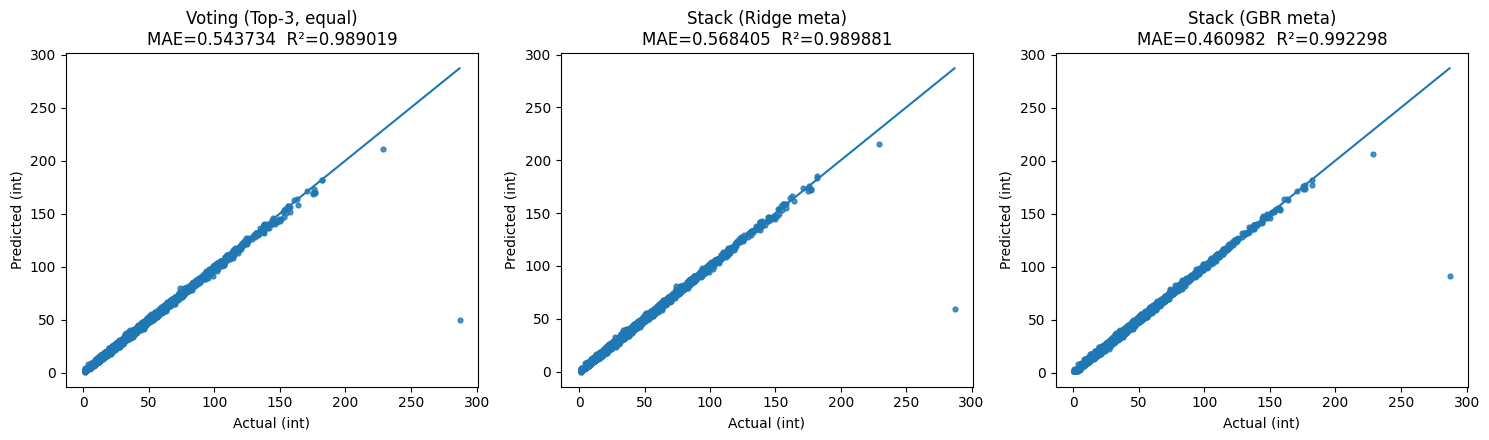

In [ ]:
# ---------- 3 HYBRID ACTUAL vs PREDICTED PLOTS ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

hybrid_candidates = [
    ("Voting (Top-3, equal)", pred_vote),
    ("Stack (Ridge meta)", pred_stack_ridge),
    ("Stack (GBR meta)", pred_stack_gbr),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (title, pred) in zip(axes, hybrid_candidates):

    y_actual = np.asarray(y_te).astype(float)
    y_pred = np.asarray(pred).astype(float)

    mae = mean_absolute_error(y_actual, y_pred)
    r2 = r2_score(y_actual, y_pred)

    ax.scatter(y_actual, y_pred, s=12, alpha=0.8)

    mn = min(y_actual.min(), y_pred.min())
    mx = max(y_actual.max(), y_pred.max())

    ax.plot([mn, mx], [mn, mx], linewidth=1.5)

    ax.set_xlabel("Actual (int)")
    ax.set_ylabel("Predicted (int)")
    ax.set_title(f"{title}\nMAE={mae:.6f}  R²={r2:.6f}")

plt.tight_layout()
plt.show()


Scatter Plot

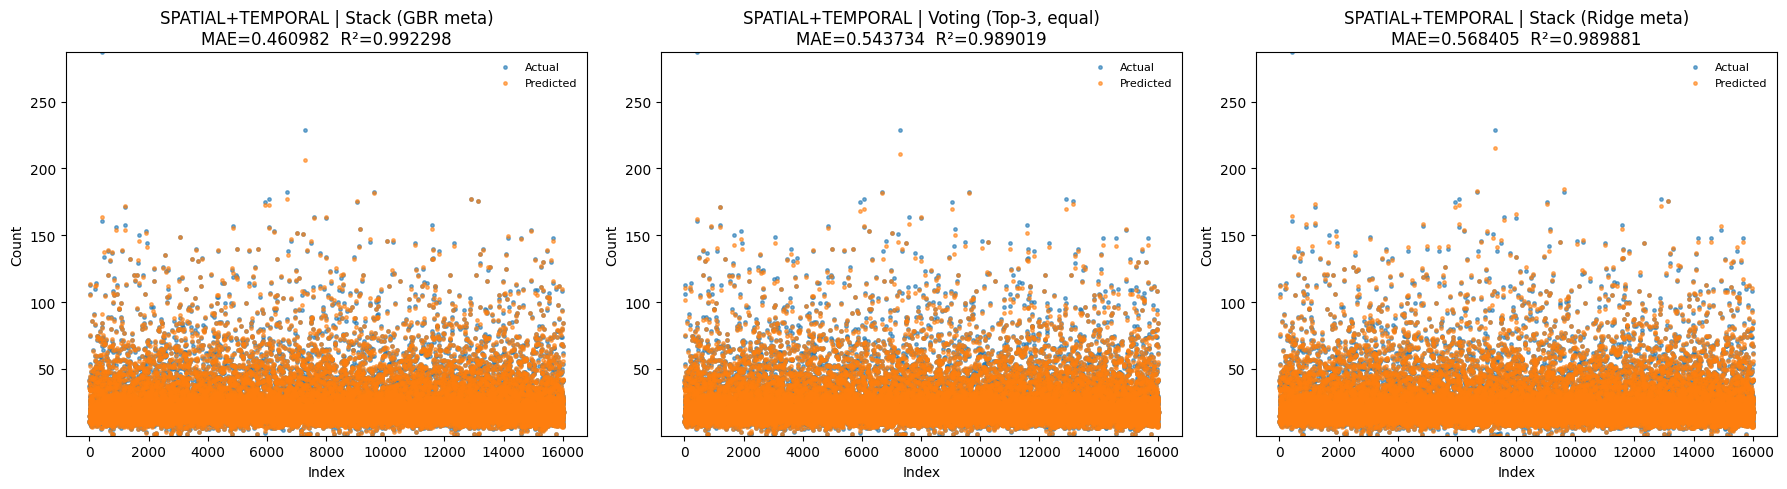


=== BEST 3 ENSEMBLES for SPATIAL+TEMPORAL (MAE asc, tie R² desc) ===
Stack (GBR meta)         | pred_stack_gbr  | MAE=0.460982 | R2=0.992298
Voting (Top-3, equal)    | pred_vote       | MAE=0.543734 | R2=0.989019
Stack (Ridge meta)       | pred_stack_ridge | MAE=0.568405 | R2=0.989881


In [ ]:
# ---------- 3 BEST panels (auto-select by MAE; tie-break by R²) ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# Candidate prediction arrays produced above in THIS combo loop
candidates = [
    ("Voting (Top-3, equal)", "pred_vote"),
    ("Stack (Linear meta)",   "pred_stack_lin"),
    ("Stack (Ridge meta)",    "pred_stack_ridge"),
    ("Stack (GBR meta)",      "pred_stack_gbr"),
    ("Hybrid (Top-3 avg)",    "pred_avg"),
]

# ---- gather available predictions (from locals in this loop scope) ----
available = []
for title, varname in candidates:
    if varname in locals():
        yp = np.asarray(locals()[varname])
        # sanity: must match length of y_te
        if len(yp) == len(y_te):
            available.append((title, varname, yp))

if len(available) == 0:
    print(f"[warn] No ensemble predictions found for BEST-3 plot in combo={combo_name}.")
else:
    # Downsample indices once (for responsiveness)
    n = len(y_te)
    idx_all = np.arange(n)
    SAMPLE = min(50000, n)
    if SAMPLE < n:
        rng = np.random.RandomState(42)
        idx = np.sort(rng.choice(n, size=SAMPLE, replace=False))
    else:
        idx = idx_all

    ya = np.asarray(y_te)[idx]

    # ---- score each candidate on the SAME idx ----
    scored = []
    for title, varname, yp_full in available:
        yp = np.asarray(yp_full)[idx]
        mae = mean_absolute_error(ya, yp)
        r2  = r2_score(ya, yp)
        scored.append((mae, -r2, title, varname, yp_full, r2))

    # sort by MAE asc, then R² desc
    scored.sort(key=lambda t: (t[0], t[1]))

    # take BEST 3
    topk = scored[:3]

    # global y-limits across chosen 3
    y_min = float(np.min(ya))
    y_max = float(np.max(ya))
    for _, _, _, _, yp_full, _ in topk:
        yp = np.asarray(yp_full)[idx]
        y_min = min(y_min, float(np.min(yp)))
        y_max = max(y_max, float(np.max(yp)))

    # ---- plot 1x3 ----
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), squeeze=False)
    axes = axes[0]

    for ax, (mae, _neg_r2, title, varname, yp_full, r2) in zip(axes, topk):
        yp = np.asarray(yp_full)[idx]
        ax.scatter(idx, ya, s=6, alpha=0.6, label="Actual")
        ax.scatter(idx, yp, s=6, alpha=0.6, label="Predicted")
        ax.set_ylim(y_min, y_max)
        ax.set_title(f"{combo_name} | {title}\nMAE={mae:.6f}  R²={r2:.6f}")
        ax.set_xlabel("Index")
        ax.set_ylabel("Count")
        ax.legend(loc="best", fontsize=8, frameon=False)

    plt.tight_layout()
    plt.show()

    # ---- print selected best 3 ----
    print(f"\n=== BEST 3 ENSEMBLES for {combo_name} (MAE asc, tie R² desc) ===")
    for mae, _neg_r2, title, varname, _yp_full, r2 in topk:
        print(f"{title:24s} | {varname:15s} | MAE={mae:.6f} | R2={r2:.6f}")


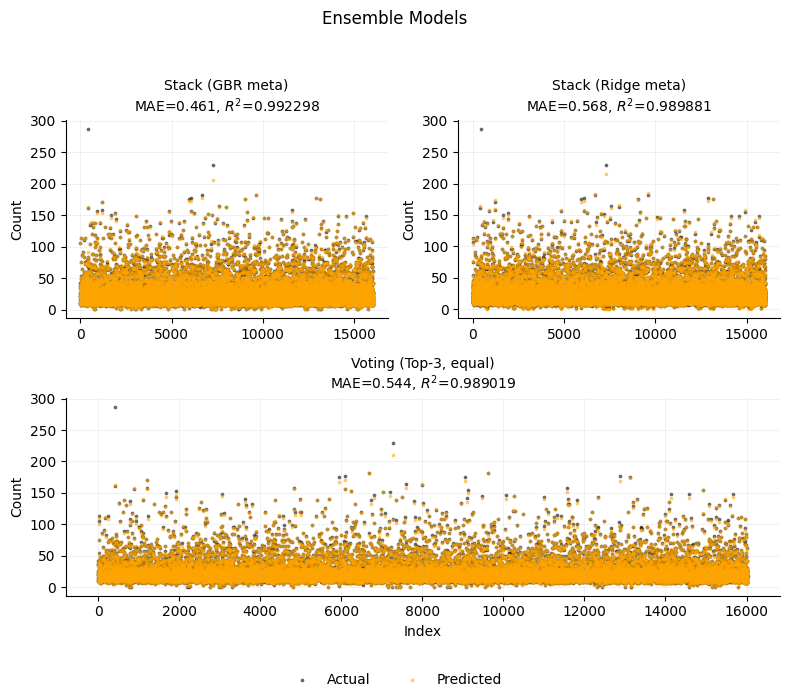

In [ ]:
# ---------- Ensemble Models: 2 top + 1 wide bottom ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

plots = [
    ("Stack (GBR meta)", pred_stack_gbr),
    ("Stack (Ridge meta)", pred_stack_ridge),
    ("Voting (Top-3, equal)", pred_vote),
]

fig = plt.figure(figsize=(8, 7))
gs = fig.add_gridspec(2, 2)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, :]),
]

for ax, (title, pred) in zip(axes, plots):
    y_actual = np.asarray(y_te).astype(float)
    y_pred = np.asarray(pred).astype(float)

    n = len(y_actual)
    idx = np.arange(n)

    mae = mean_absolute_error(y_actual, y_pred)
    r2 = r2_score(y_actual, y_pred)

    ax.scatter(idx, y_actual, s=7, alpha=0.6, c="black", linewidths=0, label="Actual")
    ax.scatter(idx, y_pred, s=7, alpha=0.6, c="orange", linewidths=0, label="Predicted")

    ax.set_title(f"{title}\nMAE={mae:.3f}, $R^2$={r2:.6f}", fontsize=10)
    ax.set_ylabel("Count")
    ax.grid(True, linewidth=0.5, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[2].set_xlabel("Index")

handles, labels = axes[2].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)

fig.suptitle("Ensemble Models", fontsize=12, y=0.98)
fig.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

Combine plot of 3 Hybrid Model

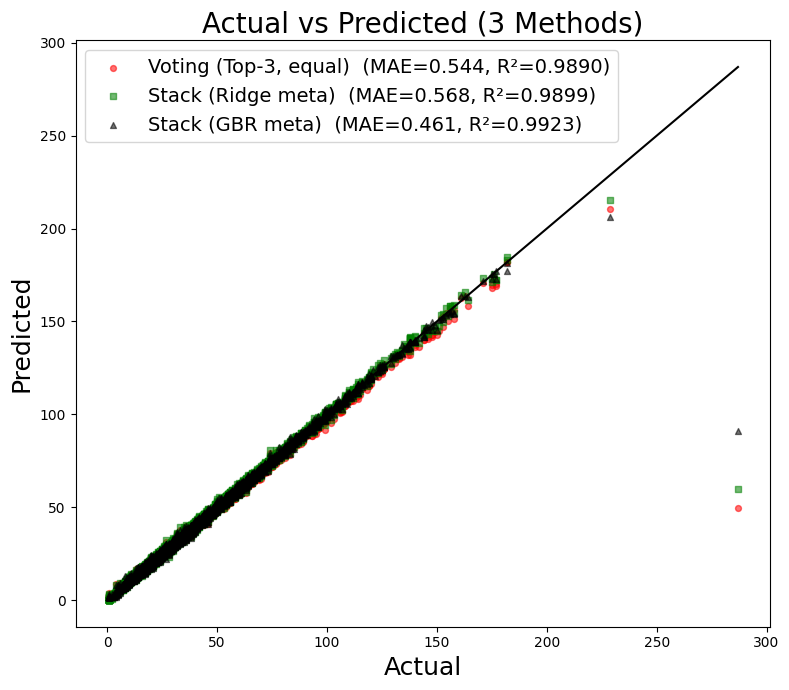

In [ ]:
# ---------- Actual vs Predicted: 3 methods in one plot ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

y_actual = np.asarray(y_te).astype(float)

methods = [
    ("Voting (Top-3, equal)", pred_vote, "o", "red"),
    ("Stack (Ridge meta)", pred_stack_ridge, "s", "green"),
    ("Stack (GBR meta)", pred_stack_gbr, "^", "black"),
]

plt.figure(figsize=(8, 7))

for name, pred, marker, color in methods:
    y_pred = np.asarray(pred).astype(float)

    mae = mean_absolute_error(y_actual, y_pred)
    r2 = r2_score(y_actual, y_pred)

    plt.scatter(
        y_actual,
        y_pred,
        s=18,
        alpha=0.55,
        marker=marker,
        color=color,
        label=f"{name}  (MAE={mae:.3f}, R²={r2:.4f})"
    )

mn = min(
    y_actual.min(),
    pred_vote.min(),
    pred_stack_ridge.min(),
    pred_stack_gbr.min()
)

mx = max(
    y_actual.max(),
    pred_vote.max(),
    pred_stack_ridge.max(),
    pred_stack_gbr.max()
)

plt.plot([mn, mx], [mn, mx], color="black", linewidth=1.5)

plt.xlabel("Actual", fontsize=18)
plt.ylabel("Predicted", fontsize=18)
plt.title("Actual vs Predicted (3 Methods)", fontsize=20)

plt.legend(fontsize=14, loc="upper left")
plt.grid(False)
plt.tight_layout()
plt.show()

Predicted Vs Actual without uncertainty

In [ ]:
# ============================================================
# BEST-3 HYBRID RESULTS — PRINT 10 ROWS PER MODEL
# Supports: VOTE, STACK_Ridge, STACK_GBR, BAG_<base>
# Paste this AFTER your HYBRID block, after df_h is created.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    VotingRegressor,
    StackingRegressor,
    GradientBoostingRegressor,
    BaggingRegressor
)
from sklearn.linear_model import Ridge

# -------------------- helpers: column pickers --------------------
def _pick_col(cols, df_):
    for c in cols:
        if c in df_.columns:
            return c
    return None

def _fmt_date_yyyymmdd(x):
    s = str(x)

    if s.isdigit() and len(s) == 8:
        return s

    try:
        return pd.to_datetime(x).strftime("%Y%m%d")
    except Exception:
        return s

# -------------------- pick POI columns on df_after --------------------
# ============================================================
# Save processed dataset and feature combinations
# ============================================================

df_after = df.copy()

BASE_COMBOS_AFTER = BASE_COMBOS.copy()

df_good = df_after
BASE_COMBOS = BASE_COMBOS_AFTER

poi_id_col = _pick_col(
    ["poi_id", "POI_ID", "POIID", "lake_id", "id"],
    df_good
)

if poi_id_col is None:
    df_good["poi_id"] = 0
    poi_id_col = "poi_id"

poi_name_col = _pick_col(
    ["poi", "POI_NAME", "poi_name", "lake_name", "LAKE_NAME", "site_name", "NAME", "name"],
    df_good
)

date_col = _pick_col(
    ["date", "DATE", "Date"],
    df_good
)

if date_col is None:
    raise ValueError("Could not find a date column in df_after.")

# -------------------- build top-3 hybrid list --------------------
if "Score_H" not in df_h.columns:
    raise ValueError("df_h must contain Score_H.")

top3_h = (
    df_h
    .sort_values("Score_H", ascending=False)
    .head(3)
    .reset_index(drop=True)
)

print("\n=== ALL HYBRID / STACKING MODELS (single split, sorted by Score_H desc) ===")

print(
    df_h[
        [
            "Combo",
            "Hybrid",
            "Bases",
            "Score_H",
            "Test_MAE",
            "Test_R2",
            "Test_MSE",
            "Test_AUC",
            "Test_P",
            "Test_R",
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# -------------------- run per top-3 hybrid --------------------
for hr in top3_h.itertuples(index=False):

    combo_name = hr.Combo
    hybrid_nm = hr.Hybrid

    feats = BASE_COMBOS.get(combo_name, None)

    if not feats:
        continue

    feats = [f for f in feats if f in df_good.columns]

    # Build X,y using your helper
    X, y = build_Xy(df_good, feats)

    if len(X) == 0 or X.shape[1] == 0:
        continue

    idx_all = np.arange(len(y))

    X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(
        X,
        y,
        idx_all,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    # Base model names
    base_names = [
        s.strip()
        for s in str(hr.Bases).split(",")
        if s.strip()
    ]

    bases = []

    for name in base_names:

        base_def = None

        for mname, mdl in MODELS:
            if mname == name:
                base_def = mdl
                break

        if base_def is None:
            continue

        bases.append(
            (name, clone(base_def))
        )

    if len(bases) == 0:
        continue

    # -------------------- build hybrid --------------------
    if hybrid_nm == "VOTE":

        model = VotingRegressor(bases)

    elif hybrid_nm == "STACK_Ridge":

        model = StackingRegressor(
            estimators=bases,
            final_estimator=Ridge(alpha=1.0),
            cv=3,
            passthrough=True
        )

    elif hybrid_nm == "STACK_GBR":

        model = StackingRegressor(
            estimators=bases,
            final_estimator=GradientBoostingRegressor(
                random_state=RANDOM_STATE,
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
            ),
            cv=3,
            passthrough=True
        )

    elif str(hybrid_nm).startswith("BAG_"):

        base_nm = str(hybrid_nm).replace("BAG_", "")

        base_def = None

        for mname, mdl in MODELS:
            if mname == base_nm:
                base_def = mdl
                break

        if base_def is None:
            print(f"[skip] Could not find base model for {hybrid_nm}")
            continue

        model = BaggingRegressor(
            estimator=clone(base_def),
            n_estimators=25,
            bootstrap=True,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    else:
        continue

    model.fit(X_tr, y_tr)
    pred_te = model.predict(X_te)

    # -------------------- PRINT rows --------------------
    print(f"\n=== {hybrid_nm} | {combo_name} ===")
    print("POI_ID | POI_NAME | DATE | Actual | Predicted")

    mask = df_good[feats].notna().all(axis=1).to_numpy()
    df_aligned = df_good.loc[mask].reset_index(drop=True)

    n_print = min(10, len(idx_te), len(pred_te))

    for i in range(n_print):

        row = df_aligned.iloc[idx_te[i]]

        pid = (
            float(row[poi_id_col])
            if pd.notna(row[poi_id_col])
            else np.nan
        )

        if poi_name_col is None:
            pname = (
                f"POI_{int(pid)}"
                if np.isfinite(pid)
                else "POI_-1"
            )

        else:
            pname = row[poi_name_col]

            if pd.isna(pname) or str(pname).strip() in ("", "nan", "None"):
                pname = (
                    f"POI_{int(pid)}"
                    if np.isfinite(pid)
                    else "POI_-1"
                )

        d = _fmt_date_yyyymmdd(row[date_col])

        a = int(round(float(y_te[i])))
        p = int(round(float(pred_te[i])))

        print(f"{pid:.1f} | {pname} | {d} | {a} | {p}")

    print(f"\nDisplayed {n_print} sample rows.")


=== ALL HYBRID / STACKING MODELS (single split, sorted by Score_H desc) ===
           Combo      Hybrid                             Bases  Score_H  Test_MAE  Test_R2  Test_MSE  Test_AUC   Test_P   Test_R
SPATIAL+TEMPORAL   STACK_GBR MLP (256,128,64),ETR,MLP (128,64) 0.793631  0.460982 0.992298  2.931395  0.999772 0.992586 0.968646
SPATIAL+TEMPORAL        VOTE MLP (256,128,64),ETR,MLP (128,64) 0.371610  0.543734 0.989019  4.179510  0.999776 0.992892 0.968646
SPATIAL+TEMPORAL STACK_Ridge MLP (256,128,64),ETR,MLP (128,64) 0.254359  0.568405 0.989881  3.851159  0.999754 0.988699 0.975882

=== STACK_GBR | SPATIAL+TEMPORAL ===
POI_ID | POI_NAME | DATE | Actual | Predicted
1500.0 | Laing Lake | 20221210 | 15 | 15
4270.0 | West Brady | 20220530 | 11 | 11
5720.0 | Glenn Cunningham | 20220313 | 42 | 37
4565.0 | Lake Maloney | 20220312 | 10 | 10
5720.0 | Glenn Cunningham | 20220429 | 37 | 36
2780.0 | Calamus Reservoir | 20220103 | 20 | 20
4720.0 | North Platte I-80 Lake | 20220818 | 21 | 21
371

Predicted Vs Actual with uncertainty

Predict visitation using the trained hybrid model and estimate uncertainty from the standard deviation of the base-model predictions plus **5% of the hybrid prediction** (with a minimum threshold). The **5% term accounts for scale-dependent uncertainty**, while the standard deviation measures disagreement among the base models. Report the final result as **Prediction ± Uncertainty** with the corresponding prediction range.

 OUTPUT: Predicted Visits = 90 ± 4
 for given date and POI


In [ ]:
# -------------------- PRINT feature information --------------------
print("\n" + "=" * 80)
print(f"Hybrid Model       : {hybrid_nm}")
print(f"Feature Combination: {combo_name}")
print(f"Total Features     : {len(feats)}")
print("Features:")
print(feats)
print("=" * 80)

# -------------------- PRINT rows --------------------
print(f"\n=== {hybrid_nm} | {combo_name} ===")
print("POI_ID | POI_NAME | DATE | Actual | Predicted ± Uncertainty")

mask = df_good[feats].notna().all(axis=1).to_numpy()
df_aligned = df_good.loc[mask].reset_index(drop=True)

# -------------------- Base-model predictions for ± --------------------
base_preds = []

for base_name, base_model in bases:

    m = clone(base_model)
    m.fit(X_tr, y_tr)

    base_preds.append(
        np.asarray(
            m.predict(X_te),
            dtype=float
        )
    )

base_preds = np.asarray(base_preds)

n_print = min(
    10,
    len(idx_te),
    len(pred_te)
)

for i in range(n_print):

    row = df_aligned.iloc[idx_te[i]]

    pid = (
        float(row[poi_id_col])
        if pd.notna(row[poi_id_col])
        else np.nan
    )

    if poi_name_col is None:

        pname = (
            f"POI_{int(pid)}"
            if np.isfinite(pid)
            else "POI_-1"
        )

    else:

        pname = row[poi_name_col]

        if pd.isna(pname) or str(pname).strip() in ("", "nan", "None"):

            pname = (
                f"POI_{int(pid)}"
                if np.isfinite(pid)
                else "POI_-1"
            )

    d = _fmt_date_yyyymmdd(
        row[date_col]
    )

    actual = int(
        round(float(y_te[i]))
    )

    predicted = int(
        round(max(0, float(pred_te[i])))
    )

    # Base-model disagreement
    model_disagreement = np.std(
        base_preds[:, i]
    )

    # ± = model disagreement + 5% scale uncertainty
    pm = (
        model_disagreement
        + 0.05 * abs(float(pred_te[i]))
    )

    # Minimum uncertainty threshold
    if pm < 3:

        pm = max(
            3,
            0.08 * abs(float(pred_te[i]))
        )

    pm = int(
        round(float(pm))
    )

    lower = max(
        0,
        predicted - pm
    )

    upper = predicted + pm

    print(
        f"{pid:.1f} | {pname} | {d} | "
        f"{actual} | {predicted} ± {pm} "
        f"({lower}-{upper})"
    )

print(f"\nDisplayed {n_print} sample rows.")


Hybrid Model       : STACK_Ridge
Feature Combination: SPATIAL+TEMPORAL
Total Features     : 106
Features:
['poi_id', 'income_0_10', 'income_10_15', 'income_15_20', 'income_20_25', 'income_25_30', 'income_30_35', 'income_35_40', 'income_40_45', 'income_45_50', 'income_50_60', 'income_60_75', 'income_75_100', 'income_100_125', 'income_125_150', 'income_150_200', 'income_over_200', 'male_0_5', 'male_5_9', 'male_10_14', 'male_15_17', 'male_18_19', 'male_20_20', 'male_21_21', 'male_22_24', 'male_25_29', 'male_30_34', 'male_35_39', 'male_40_44', 'male_45_49', 'male_50_54', 'male_55_59', 'male_60_61', 'male_62_64', 'male_65_66', 'male_67_69', 'male_70_74', 'male_75_79', 'male_80_84', 'male_over_85', 'female_0_5', 'female_5_9', 'female_10_14', 'female_15_17', 'female_18_19', 'female_20_20', 'female_21_21', 'female_22_24', 'female_25_29', 'female_30_34', 'female_35_39', 'female_40_44', 'female_45_49', 'female_50_54', 'female_55_59', 'female_60_61', 'female_62_64', 'female_65_66', 'female_67_69

Predicted Vs Actual with range like 100+-3 

1. **Feature Engineering:** Convert the input date into temporal features (e.g., day, week, month, season, weekend) and combine them with the selected predictor variables.

2. **Hybrid Model Training:** Select and train the best-performing hybrid model using the chosen feature combination.

3. **POI–Date Matching:** Match the selected POI with records from the same calendar date (month–day) across available years and prepare the prediction input.

4. **Prediction & Uncertainty:** Predict visitation using the trained hybrid model and estimate uncertainty from the standard deviation of the base-model predictions plus **5% of the hybrid prediction** (with a minimum threshold). The **5% term accounts for scale-dependent uncertainty**, while the standard deviation measures disagreement among the base models. Report the final result as **Prediction ± Uncertainty** with the corresponding prediction range.
5. In term of perticular date and POI prediction 

 OUTPUT: Predicted Visits = 90 ± 4
 for given date and POI


In [ ]:
# ============================================================
# POI + DATE PREDICTION USING REAL MATCHED DATE ROW
# Adds extra temporal features only
# No multiplier
# Includes historical data for the same date
# Gives output like: 100 ± 3
# ============================================================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    VotingRegressor,
    StackingRegressor,
    GradientBoostingRegressor
)
from sklearn.linear_model import Ridge


df_use = df_after if "df_after" in globals() else df


def predict_selected_poi_date(poi_value, input_date):

    df_use2 = df_use.copy()

    # -------------------- Add extra temporal features --------------------
    # Keep original date values before conversion
    raw_date = df_use2["date"].copy()

    # Clean values such as 20230715.0
    clean_date = (
        raw_date
        .astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )

    # First try YYYYMMDD format
    parsed_date = pd.to_datetime(
        clean_date,
        format="%Y%m%d",
        errors="coerce"
    )

    # Try general date parsing for remaining values
    bad = parsed_date.isna()

    parsed_date.loc[bad] = pd.to_datetime(
        clean_date.loc[bad],
        errors="coerce"
    )

    df_use2["date"] = parsed_date

    print("\nDate parsing:")
    print("Total rows   :", len(df_use2))
    print("Valid dates  :", df_use2["date"].notna().sum())
    print("Invalid dates:", df_use2["date"].isna().sum())

    df_use2["dow"] = df_use2["date"].dt.dayofweek
    df_use2["is_weekend"] = (df_use2["dow"] >= 5).astype(int)

    df_use2["week"] = (
        df_use2["date"]
        .dt.isocalendar()
        .week
        .astype("Int64")
    )

    df_use2["month"] = df_use2["date"].dt.month
    df_use2["day"] = df_use2["date"].dt.day

    df_use2["season"] = df_use2["month"].apply(
        lambda m:
        0 if m in [12, 1, 2] else
        1 if m in [3, 4, 5] else
        2 if m in [6, 7, 8] else
        3 if pd.notna(m) else np.nan
    )

    df_use2["date_ordinal"] = df_use2["date"].map(
        lambda x: x.toordinal()
        if pd.notna(x)
        else np.nan
    )

    df_use2["is_month_start"] = (
        df_use2["date"]
        .dt.is_month_start
        .astype(int)
    )

    df_use2["is_month_end"] = (
        df_use2["date"]
        .dt.is_month_end
        .astype(int)
    )

    df_use2["is_quarter_start"] = (
        df_use2["date"]
        .dt.is_quarter_start
        .astype(int)
    )

    df_use2["is_quarter_end"] = (
        df_use2["date"]
        .dt.is_quarter_end
        .astype(int)
    )

    if "poi_id" in df_use2.columns:

        df_use2["poi_id_code"] = (
            df_use2["poi_id"]
            .astype("category")
            .cat.codes
        )

    # -------------------- Best Hybrid --------------------
    best_h = (
        df_h
        .sort_values(
            "Score_H",
            ascending=False
        )
        .iloc[0]
    )

    combo_name = best_h["Combo"]
    hybrid_nm = best_h["Hybrid"]

    feats = (
        BASE_COMBOS_AFTER[combo_name]
        if "BASE_COMBOS_AFTER" in globals()
        else BASE_COMBOS[combo_name]
    )

    extra_feats = [
        "is_weekend",
        "season",
        "month",
        "week",
        "dow",
        "day",
        "date_ordinal",
        "is_month_start",
        "is_month_end",
        "is_quarter_start",
        "is_quarter_end",
        "poi_id_code"
    ]

    feats = list(
        dict.fromkeys(
            list(feats) + extra_feats
        )
    )

    feats = [
        f for f in feats
        if f in df_use2.columns
    ]

    # -------------------- Build X, y, aligned df --------------------
    X, y = build_Xy(
        df_use2,
        feats
    )

    mask = (
        df_use2[feats]
        .notna()
        .all(axis=1)
    )

    df_aligned = (
        df_use2.loc[mask]
        .reset_index(drop=True)
    )

    n = min(
        len(X),
        len(y),
        len(df_aligned)
    )

    print("\nRows after feature preparation:")
    print("Rows returned by build_Xy:", len(X))
    print("Target rows              :", len(y))
    print("Aligned dataframe rows   :", len(df_aligned))
    print("Final usable rows        :", n)

    if n == 0:

        print("\nNo valid rows remain after feature filtering.")

        print("\nFeatures with the most missing values:")

        missing_summary = (
            df_use2[feats]
            .isna()
            .sum()
            .sort_values(ascending=False)
        )

        print(
            missing_summary
            .head(30)
            .to_string()
        )

        print("\nFeatures used:")
        print(feats)

        return None

    X = X[:n]

    y = (
        np.asarray(y)
        .reshape(-1)[:n]
    )

    df_aligned = (
        df_aligned
        .iloc[:n]
        .reset_index(drop=True)
    )

    # Store actual historical target values
    df_aligned["_historical_visits"] = y

    if n < 2:

        print(
            "\nNot enough valid rows for train/test splitting. "
            f"Valid rows: {n}"
        )

        return None

    X_tr, X_te, y_tr, y_te = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    print("\nFeatures used:")
    print(feats)
    print("Total features:", len(feats))

    print(
        "Extra features present:",
        [
            f for f in extra_feats
            if f in feats
        ]
    )

    # -------------------- Columns --------------------
    poi_id_col = "poi_id"

    poi_name_col = (
        "poi"
        if "poi" in df_aligned.columns
        else poi_id_col
    )

    date_col = "date"

    # -------------------- Base Models --------------------
    base_names = [
        s.strip()
        for s in str(best_h["Bases"]).split(",")
        if s.strip()
    ]

    bases = []

    for name in base_names:

        for mname, mdl in MODELS:

            if mname == name:

                bases.append(
                    (
                        name,
                        clone(mdl)
                    )
                )

                break

    if len(bases) == 0:

        print("No base models found.")
        print("Requested base models:", base_names)

        return None

    # -------------------- Hybrid Model --------------------
    if hybrid_nm == "VOTE":

        model = VotingRegressor(
            estimators=bases
        )

    elif hybrid_nm == "STACK_Ridge":

        model = StackingRegressor(
            estimators=bases,
            final_estimator=Ridge(
                alpha=1.0
            ),
            cv=2,
            passthrough=False
        )

    elif hybrid_nm == "STACK_GBR":

        model = StackingRegressor(
            estimators=bases,
            final_estimator=GradientBoostingRegressor(
                random_state=RANDOM_STATE,
                n_estimators=50,
                learning_rate=0.05,
                max_depth=2
            ),
            cv=2,
            passthrough=False
        )

    else:

        print(
            f"Unknown hybrid model: {hybrid_nm}"
        )

        return None

    model.fit(
        X_tr,
        y_tr
    )

    # -------------------- POI Matching --------------------
    df_temp = df_aligned.copy()

    df_temp["_poi_num"] = pd.to_numeric(
        df_temp[poi_id_col],
        errors="coerce"
    )

    poi_num = pd.to_numeric(
        poi_value,
        errors="coerce"
    )

    if pd.notna(poi_num):

        poi_mask = (
            df_temp["_poi_num"]
            == float(poi_num)
        )

    else:

        poi_mask = (
            df_temp[poi_name_col]
            .astype(str)
            .str.lower()
            .str.contains(
                str(poi_value).lower(),
                na=False
            )
        )

    if poi_mask.sum() == 0:

        print("POI/Lake not found.")

        print("\nAvailable POI examples:")

        print(
            df_temp[
                [
                    poi_id_col,
                    poi_name_col
                ]
            ]
            .drop_duplicates()
            .head(20)
            .to_string(index=False)
        )

        return None

    # -------------------- Date Matching --------------------
    df_temp["_date_parsed"] = pd.to_datetime(
        df_temp[date_col],
        errors="coerce"
    )

    bad_date_mask = (
        df_temp["_date_parsed"]
        .isna()
    )

    df_temp.loc[
        bad_date_mask,
        "_date_parsed"
    ] = pd.to_datetime(
        df_temp.loc[
            bad_date_mask,
            date_col
        ]
        .astype(str)
        .str.replace(
            r"\.0$",
            "",
            regex=True
        ),
        format="%Y%m%d",
        errors="coerce"
    )

    df_temp["_month_day"] = (
        df_temp["_date_parsed"]
        .dt.strftime("%m-%d")
    )

    try:

        input_date_string = (
            str(input_date)
            .strip()
        )

        if "-" in input_date_string:

            dt = pd.to_datetime(
                "2024-" + input_date_string,
                format="%Y-%m-%d",
                errors="raise"
            )

        else:

            dt = pd.to_datetime(
                input_date_string + " 2024",
                errors="raise"
            )

        target_md = dt.strftime(
            "%m-%d"
        )

    except Exception:

        print(
            "Invalid date. Use 07-04 or July 4."
        )

        return None

    matched = df_temp.loc[
        poi_mask
        & (
            df_temp["_month_day"]
            == target_md
        )
    ].copy()

    if matched.empty:

        print(
            "No matching POI and date found."
        )

        print(
            "\nAvailable dates for this POI:"
        )

        available = (
            df_temp.loc[
                poi_mask,
                [
                    date_col,
                    "_month_day"
                ]
            ]
            .dropna()
            .drop_duplicates()
            .sort_values(date_col)
        )

        print(
            available.to_string(
                index=False
            )
        )

        return None

    # -------------------- Historical Same-Date Data --------------------
    historical = (
        matched[
            [
                "_date_parsed",
                "_historical_visits"
            ]
        ]
        .dropna()
        .sort_values("_date_parsed")
        .copy()
    )

    historical["Year"] = (
        historical["_date_parsed"]
        .dt.year
    )

    historical["Date"] = (
        historical["_date_parsed"]
        .dt.strftime("%Y-%m-%d")
    )

    historical = historical.rename(
        columns={
            "_historical_visits":
            "Actual_Visits"
        }
    )

    historical = (
        historical[
            [
                "Year",
                "Date",
                "Actual_Visits"
            ]
        ]
        .reset_index(drop=True)
    )

    historical_mean = float(
        historical["Actual_Visits"]
        .mean()
    )

    historical_min = float(
        historical["Actual_Visits"]
        .min()
    )

    historical_max = float(
        historical["Actual_Visits"]
        .max()
    )

    historical_std = float(
        historical["Actual_Visits"]
        .std(ddof=0)
    )

    # If multiple years have the same month-day,
    # average the feature rows
    row = (
        matched[feats]
        .mean(numeric_only=True)
        .to_frame()
        .T
    )

    # -------------------- Overwrite requested-date features --------------------
    update_vals = {
        "dow": dt.dayofweek,
        "is_weekend": int(
            dt.dayofweek >= 5
        ),
        "week": int(
            dt.isocalendar().week
        ),
        "month": dt.month,
        "day": dt.day,

        "season": (
            0 if dt.month in [12, 1, 2] else
            1 if dt.month in [3, 4, 5] else
            2 if dt.month in [6, 7, 8] else
            3
        ),

        "date_ordinal": dt.toordinal(),
        "is_month_start": int(
            dt.is_month_start
        ),
        "is_month_end": int(
            dt.is_month_end
        ),
        "is_quarter_start": int(
            dt.is_quarter_start
        ),
        "is_quarter_end": int(
            dt.is_quarter_end
        )
    }

    for c, v in update_vals.items():

        if c in row.columns:
            row[c] = v

    # Ensure all features are available in prediction row
    missing_prediction_features = [
        f for f in feats
        if f not in row.columns
    ]

    if missing_prediction_features:

        print(
            "\nMissing prediction features:"
        )

        print(
            missing_prediction_features
        )

        return None

    if row[feats].isna().any().any():

        print(
            "\nPrediction row contains missing values:"
        )

        print(
            row[feats]
            .isna()
            .sum()
            .loc[
                lambda s: s > 0
            ]
        )

        return None

    # -------------------- Predict --------------------
    X_new = row[feats]

    pred_raw = float(
        model.predict(
            X_new
        )[0]
    )

    # -------------------- Base Model Predictions --------------------
    preds = []

    for base_name, base_model in bases:

        m = clone(
            base_model
        )

        m.fit(
            X_tr,
            y_tr
        )

        base_prediction = float(
            m.predict(
                X_new
            )[0]
        )

        preds.append(
            base_prediction
        )

    preds = np.array(
        preds,
        dtype=float
    )

    # Model disagreement + scale-dependent uncertainty
    pm = (
        np.std(preds)
        + 0.05 * abs(pred_raw)
    )

    # Minimum uncertainty threshold
    if pm < 3:

        pm = max(
            3,
            0.08 * abs(pred_raw)
        )

    pred = int(
        round(
            max(
                0,
                pred_raw
            )
        )
    )

    pm = int(
        round(pm)
    )

    lower = max(
        0,
        pred - pm
    )

    upper = (
        pred + pm
    )

    lake_id = (
        matched
        .iloc[0][poi_id_col]
    )

    lake_name = (
        matched
        .iloc[0][poi_name_col]
    )

    # -------------------- Print Prediction --------------------
    print("\n==============================")
    print("Prediction")
    print("==============================")
    print(f"Lake ID          : {lake_id}")
    print(f"Lake Name        : {lake_name}")
    print(f"Date             : {input_date}")
    print(f"Matched Date     : {target_md}")
    print(f"Rows Used        : {len(matched)}")
    print(f"Hybrid Model     : {hybrid_nm}")
    print(f"Feature Combo    : {combo_name}")
    print(f"Predicted Visits : {pred} ± {pm}")
    print(f"Prediction Range : ({lower} - {upper})")

    # -------------------- Print Historical Data --------------------
    print("\n==============================")
    print("Historical Same-Date Data")
    print("==============================")

    historical_display = historical.copy()

    historical_display["Actual_Visits"] = (
        historical_display["Actual_Visits"]
        .round(2)
    )

    print(
        historical_display.to_string(
            index=False
        )
    )

    print(
        f"\nHistorical Average : "
        f"{historical_mean:.2f}"
    )

    print(
        f"Historical Minimum : "
        f"{historical_min:.2f}"
    )

    print(
        f"Historical Maximum : "
        f"{historical_max:.2f}"
    )

    print(
        f"Historical Std Dev : "
        f"{historical_std:.2f}"
    )

    

In [ ]:
# -------------------- example --------------------
#predict_selected_poi_date(6080, "07-15")
#predict_selected_poi_date(6080, "01-01")
#predict_selected_poi_date(6080, "02-14")
#predict_selected_poi_date(6080, "03-17")
#predict_selected_poi_date(6080, "04-15")


# -------------------- example --------------------
predict_selected_poi_date(6080, "01-03")
predict_selected_poi_date(6080, "01-04")
predict_selected_poi_date(6080, "01-05")
predict_selected_poi_date(6080, "02-03")
predict_selected_poi_date(6080, "02-15")



Date parsing:
Total rows   : 80216
Valid dates  : 80216
Invalid dates: 0

Rows after feature preparation:
Rows returned by build_Xy: 80128
Target rows              : 80128
Aligned dataframe rows   : 80128
Final usable rows        : 80128

Features used:
['poi_id', 'income_0_10', 'income_10_15', 'income_15_20', 'income_20_25', 'income_25_30', 'income_30_35', 'income_35_40', 'income_40_45', 'income_45_50', 'income_50_60', 'income_60_75', 'income_75_100', 'income_100_125', 'income_125_150', 'income_150_200', 'income_over_200', 'male_0_5', 'male_5_9', 'male_10_14', 'male_15_17', 'male_18_19', 'male_20_20', 'male_21_21', 'male_22_24', 'male_25_29', 'male_30_34', 'male_35_39', 'male_40_44', 'male_45_49', 'male_50_54', 'male_55_59', 'male_60_61', 'male_62_64', 'male_65_66', 'male_67_69', 'male_70_74', 'male_75_79', 'male_80_84', 'male_over_85', 'female_0_5', 'female_5_9', 'female_10_14', 'female_15_17', 'female_18_19', 'female_20_20', 'female_21_21', 'female_22_24', 'female_25_29', 'female_3

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but ExtraTreesRegressor was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but ExtraTreesRegressor was fitted without feature names
  warnings.warn(



Prediction
Lake ID          : 6080.0
Lake Name        : Mormon Island West (MM 312N)
Date             : 01-03
Matched Date     : 01-03
Rows Used        : 6
Hybrid Model     : STACK_GBR
Feature Combo    : SPATIAL+TEMPORAL
Predicted Visits : 38 ± 3
Prediction Range : (35 - 41)

Historical Same-Date Data
 Year       Date  Actual_Visits
 2022 2022-01-03           12.0
 2022 2022-01-03           17.0
 2022 2022-01-03           33.0
 2022 2022-01-03           21.0
 2022 2022-01-03           44.0
 2024 2024-01-03          108.0

Historical Average : 39.17
Historical Minimum : 12.00
Historical Maximum : 108.00
Historical Std Dev : 32.55

Date parsing:
Total rows   : 80216
Valid dates  : 80216
Invalid dates: 0

Rows after feature preparation:
Rows returned by build_Xy: 80128
Target rows              : 80128
Aligned dataframe rows   : 80128
Final usable rows        : 80128

Features used:
['poi_id', 'income_0_10', 'income_10_15', 'income_15_20', 'income_20_25', 'income_25_30', 'income_30_35', '

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but ExtraTreesRegressor was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but ExtraTreesRegressor was fitted without feature names
  warnings.warn(



Prediction
Lake ID          : 6080.0
Lake Name        : Mormon Island West (MM 312N)
Date             : 01-04
Matched Date     : 01-04
Rows Used        : 2
Hybrid Model     : STACK_GBR
Feature Combo    : SPATIAL+TEMPORAL
Predicted Visits : 66 ± 3
Prediction Range : (63 - 69)

Historical Same-Date Data
 Year       Date  Actual_Visits
 2022 2022-01-04           30.0
 2024 2024-01-04          108.0

Historical Average : 69.00
Historical Minimum : 30.00
Historical Maximum : 108.00
Historical Std Dev : 39.00

Date parsing:
Total rows   : 80216
Valid dates  : 80216
Invalid dates: 0

Rows after feature preparation:
Rows returned by build_Xy: 80128
Target rows              : 80128
Aligned dataframe rows   : 80128
Final usable rows        : 80128

Features used:
['poi_id', 'income_0_10', 'income_10_15', 'income_15_20', 'income_20_25', 'income_25_30', 'income_30_35', 'income_35_40', 'income_40_45', 'income_45_50', 'income_50_60', 'income_60_75', 'income_75_100', 'income_100_125', 'income_125_15

...

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but ExtraTreesRegressor was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but ExtraTreesRegressor was fitted without feature names
  warnings.warn(



Prediction
Lake ID          : 6080.0
Lake Name        : Mormon Island West (MM 312N)
Date             : 02-03
Matched Date     : 02-03
Rows Used        : 2
Hybrid Model     : STACK_GBR
Feature Combo    : SPATIAL+TEMPORAL
Predicted Visits : 14 ± 3
Prediction Range : (11 - 17)

Historical Same-Date Data
 Year       Date  Actual_Visits
 2022 2022-02-03           18.0
 2023 2023-02-03            1.0

Historical Average : 9.50
Historical Minimum : 1.00
Historical Maximum : 18.00
Historical Std Dev : 8.50

Date parsing:
Total rows   : 80216
Valid dates  : 80216
Invalid dates: 0

Rows after feature preparation:
Rows returned by build_Xy: 80128
Target rows              : 80128
Aligned dataframe rows   : 80128
Final usable rows        : 80128

Features used:
['poi_id', 'income_0_10', 'income_10_15', 'income_15_20', 'income_20_25', 'income_25_30', 'income_30_35', 'income_35_40', 'income_40_45', 'income_45_50', 'income_50_60', 'income_60_75', 'income_75_100', 'income_100_125', 'income_125_150', 

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but ExtraTreesRegressor was fitted without feature names
  warnings.warn(



Prediction
Lake ID          : 6080.0
Lake Name        : Mormon Island West (MM 312N)
Date             : 02-15
Matched Date     : 02-15
Rows Used        : 1
Hybrid Model     : STACK_GBR
Feature Combo    : SPATIAL+TEMPORAL
Predicted Visits : 13 ± 3
Prediction Range : (10 - 16)

Historical Same-Date Data
 Year       Date  Actual_Visits
 2022 2022-02-15           10.0

Historical Average : 10.00
Historical Minimum : 10.00
Historical Maximum : 10.00
Historical Std Dev : 0.00


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but ExtraTreesRegressor was fitted without feature names
  warnings.warn(




Monthly Multiplier Adjustment: A monthly adjustment factor is computed as the ratio of the historical mean visitation for the same calendar date to the historical mean visitation for the target month:

Multiplier=Monthly Mean\Same-Date Mean

Example: Raw prediction = 100, same-date mean = 120, monthly mean = 100.

Multiplier=120/100=1.2
Adjusted Prediction=100×1.2=120


The multiplier is constrained to 0.4–1.8 to avoid unrealistic adjustments. For example, if the raw prediction is 100, the same-date mean is 120, and the monthly mean is 100, then the multiplier is 1.2, resulting in an adjusted prediction of 120.

Prediction Uncertainty: The final prediction is reported as Prediction ± Uncertainty, where the uncertainty is estimated from the standard deviation of the base-model predictions plus 5% of the adjusted prediction, providing a scale-dependent prediction interval.

In [ ]:
# ============================================================
# POI + DATE PREDICTION USING REAL MATCHED DATE ROW
# Same structure + extra temporal features
# Uses MONTHLY multiplier, not overall lake mean
# Shows all available historical rows for the same date
# Output like: 100 ± 3
# ============================================================

import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    VotingRegressor,
    StackingRegressor,
    GradientBoostingRegressor
)
from sklearn.linear_model import Ridge


df_use = df_after if "df_after" in globals() else df


def predict_selected_poi_date(poi_value, input_date):

    # -------------------- Add extra temporal features --------------------
    df_use2 = df_use.copy()

    # Preserve original date values before conversion
    raw_date = (
        df_use2["date"]
        .astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )

    df_use2["date"] = pd.to_datetime(
        raw_date,
        format="%Y%m%d",
        errors="coerce"
    )

    bad = df_use2["date"].isna()

    df_use2.loc[bad, "date"] = pd.to_datetime(
        raw_date.loc[bad],
        errors="coerce"
    )

    df_use2["dow"] = df_use2["date"].dt.dayofweek

    df_use2["is_weekend"] = (
        df_use2["dow"] >= 5
    ).astype(int)

    # Nullable integer supports missing date values
    df_use2["week"] = (
        df_use2["date"]
        .dt.isocalendar()
        .week
        .astype("Int64")
    )

    df_use2["month"] = df_use2["date"].dt.month
    df_use2["day"] = df_use2["date"].dt.day

    df_use2["season"] = df_use2["month"].apply(
        lambda m:
        0 if m in [12, 1, 2] else
        1 if m in [3, 4, 5] else
        2 if m in [6, 7, 8] else
        3 if pd.notna(m) else np.nan
    )

    df_use2["date_ordinal"] = df_use2["date"].map(
        lambda x: x.toordinal()
        if pd.notna(x)
        else np.nan
    )

    df_use2["is_month_start"] = (
        df_use2["date"]
        .dt.is_month_start
        .astype(int)
    )

    df_use2["is_month_end"] = (
        df_use2["date"]
        .dt.is_month_end
        .astype(int)
    )

    df_use2["is_quarter_start"] = (
        df_use2["date"]
        .dt.is_quarter_start
        .astype(int)
    )

    df_use2["is_quarter_end"] = (
        df_use2["date"]
        .dt.is_quarter_end
        .astype(int)
    )

    if "poi_id" in df_use2.columns:

        df_use2["poi_id_code"] = (
            df_use2["poi_id"]
            .astype("category")
            .cat.codes
        )

    # -------------------- Best Hybrid --------------------
    best_h = (
        df_h
        .sort_values(
            "Score_H",
            ascending=False
        )
        .iloc[0]
    )

    combo_name = best_h["Combo"]
    hybrid_nm = best_h["Hybrid"]

    feats = (
        BASE_COMBOS_AFTER[combo_name]
        if "BASE_COMBOS_AFTER" in globals()
        else BASE_COMBOS[combo_name]
    )

    extra_feats = [
        "is_weekend",
        "season",
        "month",
        "week",
        "dow",
        "day",
        "date_ordinal",
        "is_month_start",
        "is_month_end",
        "is_quarter_start",
        "is_quarter_end",
        "poi_id_code"
    ]

    feats = list(
        dict.fromkeys(
            list(feats) + extra_feats
        )
    )

    feats = [
        f for f in feats
        if f in df_use2.columns
    ]

    print("\nFeatures used:")
    print(feats)
    print("Total features:", len(feats))

    print(
        "Extra features present:",
        [
            f for f in extra_feats
            if f in feats
        ]
    )

    # -------------------- Build X, y, aligned df --------------------
    X, y = build_Xy(
        df_use2,
        feats
    )

    mask = (
        df_use2[feats]
        .notna()
        .all(axis=1)
    )

    df_aligned = (
        df_use2.loc[mask]
        .reset_index(drop=True)
    )

    n = min(
        len(X),
        len(y),
        len(df_aligned)
    )

    if n == 0:

        print(
            "\nNo valid rows remain after date and feature filtering."
        )

        print(
            "Valid dates:",
            df_use2["date"].notna().sum()
        )

        print(
            "Invalid dates:",
            df_use2["date"].isna().sum()
        )

        print("\nFeatures with the most missing values:")

        print(
            df_use2[feats]
            .isna()
            .sum()
            .sort_values(ascending=False)
            .head(20)
            .to_string()
        )

        return None

    X = X[:n]

    y = (
        np.asarray(y)
        .reshape(-1)[:n]
    )

    df_aligned = (
        df_aligned
        .iloc[:n]
        .reset_index(drop=True)
    )

    if n < 2:

        print(
            "Not enough valid rows for train/test splitting."
        )

        return None

    X_tr, X_te, y_tr, y_te = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    # -------------------- Columns --------------------
    poi_id_col = "poi_id"

    poi_name_col = (
        "poi"
        if "poi" in df_aligned.columns
        else poi_id_col
    )

    date_col = "date"
    count_col = "count"

    if count_col not in df_use2.columns:

        print(
            "The dataset does not contain a 'count' column."
        )

        return None

    # -------------------- Base Models --------------------
    # Preserve commas inside model names such as:
    # MLP (256,128,64),ETR,MLP (128,64)

    base_names = []
    current_name = []
    parenthesis_level = 0

    for char in str(best_h["Bases"]):

        if char == "(":
            parenthesis_level += 1

        elif char == ")":
            parenthesis_level -= 1

        if char == "," and parenthesis_level == 0:

            model_name = "".join(
                current_name
            ).strip()

            if model_name:
                base_names.append(model_name)

            current_name = []

        else:

            current_name.append(char)

    last_name = "".join(
        current_name
    ).strip()

    if last_name:
        base_names.append(last_name)

    bases = []

    for name in base_names:

        for mname, mdl in MODELS:

            if mname == name:

                bases.append(
                    (
                        name,
                        clone(mdl)
                    )
                )

                break

    print("\nBase models requested:", base_names)

    print(
        "Base models found:",
        [
            name for name, _ in bases
        ]
    )

    if len(bases) == 0:

        print("No base models found.")
        return None

    # -------------------- Hybrid Model --------------------
    if hybrid_nm == "VOTE":

        model = VotingRegressor(
            estimators=bases
        )

    elif hybrid_nm == "STACK_Ridge":

        model = StackingRegressor(
            estimators=bases,
            final_estimator=Ridge(
                alpha=1.0
            ),
            cv=2,
            passthrough=False
        )

    elif hybrid_nm == "STACK_GBR":

        model = StackingRegressor(
            estimators=bases,
            final_estimator=GradientBoostingRegressor(
                random_state=RANDOM_STATE,
                n_estimators=50,
                learning_rate=0.05,
                max_depth=2
            ),
            cv=2,
            passthrough=False
        )

    else:

        print(
            f"Unknown hybrid model: {hybrid_nm}"
        )

        return None

    model.fit(
        X_tr,
        y_tr
    )

    # -------------------- POI Matching --------------------
    df_temp = df_aligned.copy()

    df_temp["_poi_num"] = pd.to_numeric(
        df_temp[poi_id_col],
        errors="coerce"
    )

    poi_num = pd.to_numeric(
        poi_value,
        errors="coerce"
    )

    if pd.notna(poi_num):

        poi_mask = (
            df_temp["_poi_num"]
            == float(poi_num)
        )

    else:

        poi_mask = (
            df_temp[poi_name_col]
            .astype(str)
            .str.strip()
            .str.lower()
            .str.contains(
                str(poi_value)
                .strip()
                .lower(),
                na=False
            )
        )

    if poi_mask.sum() == 0:

        print(
            "POI/Lake not found in model dataset."
        )

        return None

    # -------------------- Date Matching --------------------
    df_temp["_date_parsed"] = pd.to_datetime(
        df_temp[date_col],
        errors="coerce"
    )

    df_temp["_month_day"] = (
        df_temp["_date_parsed"]
        .dt.strftime("%m-%d")
    )

    try:

        input_date_string = (
            str(input_date)
            .strip()
        )

        if "-" in input_date_string:

            dt = pd.to_datetime(
                "2024-" + input_date_string,
                format="%Y-%m-%d",
                errors="raise"
            )

        else:

            dt = pd.to_datetime(
                input_date_string + " 2024",
                errors="raise"
            )

        target_md = dt.strftime(
            "%m-%d"
        )

        target_month = dt.month

    except Exception:

        print(
            "Invalid date. Use 07-04 or July 4."
        )

        return None

    matched = df_temp.loc[
        poi_mask
        & (
            df_temp["_month_day"]
            == target_md
        )
    ].copy()

    if matched.empty:

        print(
            "No matching POI and date found in model dataset."
        )

        print(
            "\nAvailable dates for this POI:"
        )

        available = (
            df_temp.loc[
                poi_mask,
                [
                    date_col,
                    "_month_day"
                ]
            ]
            .dropna()
            .drop_duplicates()
            .sort_values(date_col)
        )

        print(
            available.to_string(
                index=False
            )
        )

        return None

    # ============================================================
    # HISTORICAL SAME-DATE DATA FROM THE FULLEST AVAILABLE DATASET
    # Shows same POI + same month-day across all available years
    # ============================================================

    if "df_original" in globals():

        historical_temp = df_original.copy()

    elif "df_raw" in globals():

        historical_temp = df_raw.copy()

    elif "df_all" in globals():

        historical_temp = df_all.copy()

    else:

        historical_temp = df.copy()

    # -------------------- Historical columns --------------------
    historical_poi_id_col = (
        poi_id_col
        if poi_id_col in historical_temp.columns
        else "poi_id"
    )

    historical_poi_name_col = (
        poi_name_col
        if poi_name_col in historical_temp.columns
        else historical_poi_id_col
    )

    historical_date_col = (
        date_col
        if date_col in historical_temp.columns
        else "date"
    )

    historical_count_col = (
        count_col
        if count_col in historical_temp.columns
        else "count"
    )

    required_historical_columns = [
        historical_poi_id_col,
        historical_date_col,
        historical_count_col
    ]

    missing_historical_columns = [
        c for c in required_historical_columns
        if c not in historical_temp.columns
    ]

    if missing_historical_columns:

        print(
            "Missing historical columns:",
            missing_historical_columns
        )

        return None

    # -------------------- Clean historical dates --------------------
    historical_raw_date = (
        historical_temp[
            historical_date_col
        ]
        .astype(str)
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )

    historical_temp["_date_parsed"] = pd.to_datetime(
        historical_raw_date,
        format="%Y%m%d",
        errors="coerce"
    )

    historical_bad = (
        historical_temp["_date_parsed"]
        .isna()
    )

    historical_temp.loc[
        historical_bad,
        "_date_parsed"
    ] = pd.to_datetime(
        historical_raw_date.loc[
            historical_bad
        ],
        errors="coerce"
    )

    historical_temp["_month_day"] = (
        historical_temp["_date_parsed"]
        .dt.strftime("%m-%d")
    )

    # -------------------- Historical POI Matching --------------------
    historical_temp["_poi_num"] = pd.to_numeric(
        historical_temp[
            historical_poi_id_col
        ],
        errors="coerce"
    )

    if pd.notna(poi_num):

        historical_poi_mask = (
            historical_temp["_poi_num"]
            == float(poi_num)
        )

    else:

        historical_poi_mask = (
            historical_temp[
                historical_poi_name_col
            ]
            .astype(str)
            .str.strip()
            .str.lower()
            .str.contains(
                str(poi_value)
                .strip()
                .lower(),
                na=False
            )
        )

    if historical_poi_mask.sum() == 0:

        print(
            "POI/Lake not found in historical dataset."
        )

        return None

    # -------------------- Same date across all available years --------------------
    historical_matched = (
        historical_temp.loc[
            historical_poi_mask
            & (
                historical_temp["_month_day"]
                == target_md
            )
        ]
        .copy()
        .sort_values("_date_parsed")
    )

    available_years = sorted(
        historical_temp.loc[
            historical_poi_mask,
            "_date_parsed"
        ]
        .dropna()
        .dt.year
        .unique()
        .tolist()
    )

    matched_years = sorted(
        historical_matched[
            "_date_parsed"
        ]
        .dropna()
        .dt.year
        .unique()
        .tolist()
    )

    print(
        "\nHistorical years available:",
        available_years
    )

    print(
        "Matched historical years:",
        matched_years
    )

    if historical_matched.empty:

        print(
            f"No historical records found for "
            f"POI {poi_value} on {target_md}."
        )

        available_dates = (
            historical_temp.loc[
                historical_poi_mask,
                [
                    historical_poi_id_col,
                    historical_poi_name_col,
                    "_date_parsed",
                    "_month_day",
                    historical_count_col
                ]
            ]
            .dropna(
                subset=["_date_parsed"]
            )
            .sort_values(
                "_date_parsed"
            )
        )

        print(
            "\nAvailable historical dates:"
        )

        print(
            available_dates.to_string(
                index=False
            )
        )

        return None

    # -------------------- Average matched model rows --------------------
    row = (
        matched[feats]
        .mean(numeric_only=True)
        .to_frame()
        .T
    )

    # -------------------- Overwrite requested-date temporal features --------------------
    update_vals = {
        "dow": dt.dayofweek,

        "is_weekend": int(
            dt.dayofweek >= 5
        ),

        "week": int(
            dt.isocalendar().week
        ),

        "month": dt.month,
        "day": dt.day,

        "season": (
            0 if dt.month in [12, 1, 2] else
            1 if dt.month in [3, 4, 5] else
            2 if dt.month in [6, 7, 8] else
            3
        ),

        "date_ordinal": dt.toordinal(),

        "is_month_start": int(
            dt.is_month_start
        ),

        "is_month_end": int(
            dt.is_month_end
        ),

        "is_quarter_start": int(
            dt.is_quarter_start
        ),

        "is_quarter_end": int(
            dt.is_quarter_end
        )
    }

    for c, v in update_vals.items():

        if c in row.columns:
            row[c] = v

    if row[feats].isna().any().any():

        print(
            "\nPrediction row contains missing values:"
        )

        print(
            row[feats]
            .isna()
            .sum()
            .loc[
                lambda s: s > 0
            ]
        )

        return None

    X_new = row[feats].copy()

    # -------------------- Raw ML Prediction --------------------
    pred_raw = float(
        model.predict(
            X_new
        )[0]
    )

    # -------------------- Monthly multiplier --------------------
    same_day_mean = (
        historical_matched[
            historical_count_col
        ]
        .mean()
    )

    lake_month_mean = (
        historical_temp.loc[
            historical_poi_mask
            & (
                historical_temp[
                    "_date_parsed"
                ].dt.month
                == target_month
            ),
            historical_count_col
        ]
        .mean()
    )

    if (
        pd.notna(lake_month_mean)
        and lake_month_mean > 0
        and pd.notna(same_day_mean)
    ):

        multiplier = (
            same_day_mean
            / lake_month_mean
        )

    else:

        multiplier = 1.0

    multiplier = float(
        np.clip(
            multiplier,
            0.4,
            1.8
        )
    )

    pred_raw_adjusted = (
        pred_raw
        * multiplier
    )

    # -------------------- Base Model Predictions --------------------
    preds = []

    for base_name, base_model in bases:

        m = clone(
            base_model
        )

        m.fit(
            X_tr,
            y_tr
        )

        base_pred = float(
            m.predict(
                X_new
            )[0]
        )

        preds.append(
            base_pred
            * multiplier
        )

    preds = np.asarray(
        preds,
        dtype=float
    )

    # -------------------- Uncertainty --------------------
    pm = (
        np.std(preds)
        + 0.05
        * abs(pred_raw_adjusted)
    )

    if pm < 3:

        pm = max(
            3,
            0.08
            * abs(pred_raw_adjusted)
        )

    pred = int(
        round(
            max(
                0,
                pred_raw_adjusted
            )
        )
    )

    pm = int(
        round(pm)
    )

    lower = max(
        0,
        pred - pm
    )

    upper = (
        pred + pm
    )

    lake_id = (
        historical_matched
        .iloc[0][
            historical_poi_id_col
        ]
    )

    lake_name = (
        historical_matched
        .iloc[0][
            historical_poi_name_col
        ]
    )

    # -------------------- Historical display --------------------
    historical_display = (
        historical_matched[
            [
                historical_poi_id_col,
                historical_poi_name_col,
                "_date_parsed",
                historical_count_col
            ]
        ]
        .copy()
    )

    historical_display["Year"] = (
        historical_display[
            "_date_parsed"
        ]
        .dt.year
    )

    historical_display["Date"] = (
        historical_display[
            "_date_parsed"
        ]
        .dt.strftime(
            "%Y-%m-%d"
        )
    )

    historical_display = (
        historical_display[
            [
                "Year",
                "Date",
                historical_poi_id_col,
                historical_poi_name_col,
                historical_count_col
            ]
        ]
        .sort_values(
            [
                "Year",
                "Date"
            ]
        )
        .reset_index(
            drop=True
        )
    )

    # -------------------- Print Prediction --------------------
    print("\n==============================")
    print("Prediction")
    print("==============================")
    print(f"Lake ID          : {lake_id}")
    print(f"Lake Name        : {lake_name}")
    print(f"Date             : {input_date}")
    print(f"Matched Date     : {target_md}")
    print(f"Model Rows Used  : {len(matched)}")
    print(f"Historical Rows  : {len(historical_matched)}")
    print(f"Hybrid Model     : {hybrid_nm}")
    print(f"Feature Combo    : {combo_name}")
    print(f"Raw ML Prediction: {pred_raw:.2f}")
    print(f"Same-Day Mean    : {same_day_mean:.2f}")
    print(f"Month Mean       : {lake_month_mean:.2f}")
    print(f"Multiplier       : {multiplier:.3f}")
    print(f"Predicted Visits : {pred} ± {pm}")
    print(f"Prediction Range : ({lower} - {upper})")

    # -------------------- Historical same-date rows --------------------
    print("\n==============================")
    print("Historical Same-Date Data")
    print("==============================")

    print(
        historical_display.to_string(
            index=False
        )
    )

    print(
        f"\nSame-Day Average: "
        f"{same_day_mean:.2f}"
    )

    print(
        f"Monthly Average : "
        f"{lake_month_mean:.2f}"
    )

    # -------------------- Return Results --------------------
    return pd.DataFrame({
    })





In [ ]:
# -------------------- example --------------------
predict_selected_poi_date(6080, "01-03")
predict_selected_poi_date(6080, "01-04")
predict_selected_poi_date(6080, "01-05")
predict_selected_poi_date(6080, "02-03")
predict_selected_poi_date(6080, "02-15")




Features used:
['poi_id', 'income_0_10', 'income_10_15', 'income_15_20', 'income_20_25', 'income_25_30', 'income_30_35', 'income_35_40', 'income_40_45', 'income_45_50', 'income_50_60', 'income_60_75', 'income_75_100', 'income_100_125', 'income_125_150', 'income_150_200', 'income_over_200', 'male_0_5', 'male_5_9', 'male_10_14', 'male_15_17', 'male_18_19', 'male_20_20', 'male_21_21', 'male_22_24', 'male_25_29', 'male_30_34', 'male_35_39', 'male_40_44', 'male_45_49', 'male_50_54', 'male_55_59', 'male_60_61', 'male_62_64', 'male_65_66', 'male_67_69', 'male_70_74', 'male_75_79', 'male_80_84', 'male_over_85', 'female_0_5', 'female_5_9', 'female_10_14', 'female_15_17', 'female_18_19', 'female_20_20', 'female_21_21', 'female_22_24', 'female_25_29', 'female_30_34', 'female_35_39', 'female_40_44', 'female_45_49', 'female_50_54', 'female_55_59', 'female_60_61', 'female_62_64', 'female_65_66', 'female_67_69', 'female_70_74', 'female_75_79', 'female_80_84', 'female_over_85', 'black', 'native_ameri

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but ExtraTreesRegressor was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: 


Prediction
Lake ID          : 6080.0
Lake Name        : Mormon Island West (MM 312N)
Date             : 01-03
Matched Date     : 01-03
Model Rows Used  : 6
Historical Rows  : 6
Hybrid Model     : STACK_GBR
Feature Combo    : SPATIAL+TEMPORAL
Raw ML Prediction: 35.40
Same-Day Mean    : 39.17
Month Mean       : 25.47
Multiplier       : 1.538
Predicted Visits : 54 ± 6
Prediction Range : (48 - 60)

Historical Same-Date Data
 Year       Date  poi_id                          poi  count
 2022 2022-01-03  6080.0 Mormon Island West (MM 312N)   12.0
 2022 2022-01-03  6080.0 Mormon Island West (MM 312N)   17.0
 2022 2022-01-03  6080.0 Mormon Island West (MM 312N)   33.0
 2022 2022-01-03  6080.0 Mormon Island West (MM 312N)   21.0
 2022 2022-01-03  6080.0 Mormon Island West (MM 312N)   44.0
 2024 2024-01-03  6080.0 Mormon Island West (MM 312N)  108.0

Same-Day Average: 39.17
Monthly Average : 25.47

Features used:
['poi_id', 'income_0_10', 'income_10_15', 'income_15_20', 'income_20_25', 'income_2

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but ExtraTreesRegressor was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: 


Prediction
Lake ID          : 6080.0
Lake Name        : Mormon Island West (MM 312N)
Date             : 01-04
Matched Date     : 01-04
Model Rows Used  : 2
Historical Rows  : 2
Hybrid Model     : STACK_GBR
Feature Combo    : SPATIAL+TEMPORAL
Raw ML Prediction: 63.28
Same-Day Mean    : 69.00
Month Mean       : 25.47
Multiplier       : 1.800
Predicted Visits : 114 ± 7
Prediction Range : (107 - 121)

Historical Same-Date Data
 Year       Date  poi_id                          poi  count
 2022 2022-01-04  6080.0 Mormon Island West (MM 312N)   30.0
 2024 2024-01-04  6080.0 Mormon Island West (MM 312N)  108.0

Same-Day Average: 69.00
Monthly Average : 25.47

Features used:
['poi_id', 'income_0_10', 'income_10_15', 'income_15_20', 'income_20_25', 'income_25_30', 'income_30_35', 'income_35_40', 'income_40_45', 'income_45_50', 'income_50_60', 'income_60_75', 'income_75_100', 'income_100_125', 'income_125_150', 'income_150_200', 'income_over_200', 'male_0_5', 'male_5_9', 'male_10_14', 'male_15_1

...


Prediction
Lake ID          : 6080.0
Lake Name        : Mormon Island West (MM 312N)
Date             : 02-03
Matched Date     : 02-03
Model Rows Used  : 2
Historical Rows  : 2
Hybrid Model     : STACK_GBR
Feature Combo    : SPATIAL+TEMPORAL
Raw ML Prediction: 14.16
Same-Day Mean    : 9.50
Month Mean       : 26.36
Multiplier       : 0.400
Predicted Visits : 6 ± 3
Prediction Range : (3 - 9)

Historical Same-Date Data
 Year       Date  poi_id                          poi  count
 2022 2022-02-03  6080.0 Mormon Island West (MM 312N)   18.0
 2023 2023-02-03  6080.0 Mormon Island West (MM 312N)    1.0

Same-Day Average: 9.50
Monthly Average : 26.36

Features used:
['poi_id', 'income_0_10', 'income_10_15', 'income_15_20', 'income_20_25', 'income_25_30', 'income_30_35', 'income_35_40', 'income_40_45', 'income_45_50', 'income_50_60', 'income_60_75', 'income_75_100', 'income_100_125', 'income_125_150', 'income_150_200', 'income_over_200', 'male_0_5', 'male_5_9', 'male_10_14', 'male_15_17', 'mal

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but ExtraTreesRegressor was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: 


Prediction
Lake ID          : 6080.0
Lake Name        : Mormon Island West (MM 312N)
Date             : 02-15
Matched Date     : 02-15
Model Rows Used  : 1
Historical Rows  : 1
Hybrid Model     : STACK_GBR
Feature Combo    : SPATIAL+TEMPORAL
Raw ML Prediction: 12.37
Same-Day Mean    : 10.00
Month Mean       : 26.36
Multiplier       : 0.400
Predicted Visits : 5 ± 3
Prediction Range : (2 - 8)

Historical Same-Date Data
 Year       Date  poi_id                          poi  count
 2022 2022-02-15  6080.0 Mormon Island West (MM 312N)   10.0

Same-Day Average: 10.00
Monthly Average : 26.36


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


""


/var/folders/1d/g4zmv0kx6v910p8sldg41zfr0000gr/T/ipykernel_66836/3098606806.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.95])


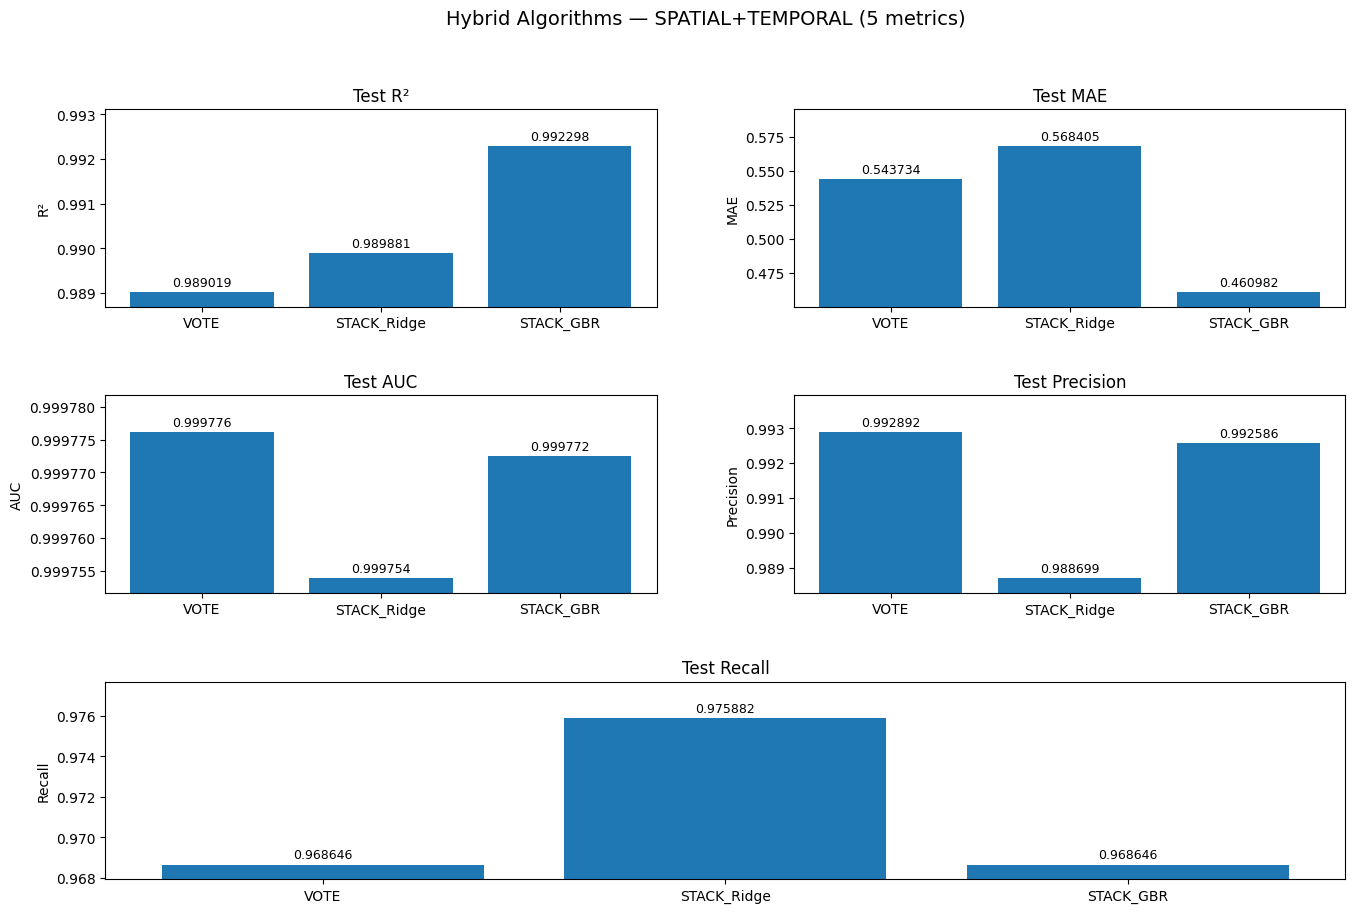

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

HYBRID_ORDER = ["VOTE", "STACK_Ridge", "STACK_GBR"]

def _prep_hybrid_values(df_h, metric, order=HYBRID_ORDER):
    # returns (labels, vals) in fixed order
    if df_h is None or len(df_h) == 0 or metric not in df_h.columns:
        return None, None

    d = df_h[["Hybrid", metric]].dropna(subset=["Hybrid", metric]).copy()
    if len(d) == 0:
        return None, None

    # one value per hybrid: take BEST by Score_H if available, else mean
    if "Score_H" in df_h.columns:
        d = (df_h[["Hybrid", metric, "Score_H"]]
             .dropna(subset=["Hybrid", metric])
             .sort_values(["Hybrid", "Score_H"], ascending=[True, False])
             .drop_duplicates("Hybrid", keep="first")[["Hybrid", metric]])
    else:
        d = d.groupby("Hybrid", as_index=False)[metric].mean()

    present = [h for h in order if h in set(d["Hybrid"].tolist())]
    if len(present) == 0:
        return None, None

    d = d.set_index("Hybrid").reindex(present).reset_index()
    labels = d["Hybrid"].tolist()
    vals = d[metric].to_numpy(dtype=float)
    return labels, vals

def plot_5_hybrid_metrics_2_2_1(
    df_h,
    metrics=("Test_R2", "Test_MAE", "Test_AUC", "Test_P", "Test_R"),  # 5 blocks
    titles=None,
    ylabels=None,
    fmt="{:.6f}",
    suptitle="Hybrid Algorithms — SPATIAL+TEMPORAL (5 metrics)"
):
    if titles is None:
        titles = {
            "Test_R2": "Test R²",
            "Test_MAE": "Test MAE",
            "Test_MSE": "Test MSE",
            "Test_AUC": "Test AUC",
            "Test_P": "Test Precision",
            "Test_R": "Test Recall",
        }
    if ylabels is None:
        ylabels = {
            "Test_R2": "R²",
            "Test_MAE": "MAE",
            "Test_MSE": "MSE",
            "Test_AUC": "AUC",
            "Test_P": "Precision",
            "Test_R": "Recall",
        }

    # Layout: row1=2, row2=2, row3=1 centered (spans both columns)
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1], hspace=0.45, wspace=0.25)

    axes = [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[1, 0]),
        fig.add_subplot(gs[1, 1]),
        fig.add_subplot(gs[2, :]),  # last row spans both columns -> centered
    ]

    for ax, metric in zip(axes, metrics):
        labels, vals = _prep_hybrid_values(df_h, metric)

        if labels is None:
            ax.set_title(f"{titles.get(metric, metric)} (no data)")
            ax.axis("off")
            continue

        x = np.arange(len(labels))
        bars = ax.bar(x, vals)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=0)
        ax.set_title(titles.get(metric, metric))
        ax.set_ylabel(ylabels.get(metric, metric))

        # no scientific offset text
        ax.ticklabel_format(style="plain", axis="y", useOffset=False)
        ax.yaxis.get_major_formatter().set_scientific(False)
        ax.yaxis.get_major_formatter().set_useOffset(False)

        # y-limits with headroom
        y_min, y_max = float(np.min(vals)), float(np.max(vals))
        rng = (y_max - y_min) if (y_max != y_min) else (abs(y_max) if y_max != 0 else 1.0)
        ax.set_ylim(y_min - 0.10*rng, y_max + 0.25*rng)

        # value labels
        pad = 0.02 * rng
        for rect, v in zip(bars, vals):
            ax.text(rect.get_x() + rect.get_width()/2,
                    rect.get_height() + pad,
                    fmt.format(v),
                    ha="center", va="bottom", fontsize=9)

    fig.suptitle(suptitle, fontsize=14, y=0.98)
    fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.95])
    plt.show()

# ---- Call it (row1:2, row2:2, row3:1 centered) ----
plot_5_hybrid_metrics_2_2_1(
    df_h,
    metrics=("Test_R2", "Test_MAE", "Test_AUC", "Test_P", "Test_R"),
    suptitle="Hybrid Algorithms — SPATIAL+TEMPORAL (5 metrics)"
)


Best 20 features 

/var/folders/1d/g4zmv0kx6v910p8sldg41zfr0000gr/T/ipykernel_71411/119721240.py:9: DtypeWarning: Columns (0: home_origin) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PATH)


Numeric features: ['poi_id', 'date', 'count', 'duration', 'hh00', 'hh01', 'hh02', 'hh03', 'hh04', 'hh05', 'hh06', 'hh07', 'hh08', 'hh09', 'hh10', 'hh11', 'hh12', 'hh13', 'hh14', 'hh15', 'hh16', 'hh17', 'hh18', 'hh19', 'hh20', 'hh21', 'hh22', 'hh23', 'income_0_10', 'income_10_15', 'income_15_20', 'income_20_25', 'income_25_30', 'income_30_35', 'income_35_40', 'income_40_45', 'income_45_50', 'income_50_60', 'income_60_75', 'income_75_100', 'income_100_125', 'income_125_150', 'income_150_200', 'income_over_200', 'male_0_5', 'male_5_9', 'male_10_14', 'male_15_17', 'male_18_19', 'male_20_20', 'male_21_21', 'male_22_24', 'male_25_29', 'male_30_34', 'male_35_39', 'male_40_44', 'male_45_49', 'male_50_54', 'male_55_59', 'male_60_61', 'male_62_64', 'male_65_66', 'male_67_69', 'male_70_74', 'male_75_79', 'male_80_84', 'male_over_85', 'female_0_5', 'female_5_9', 'female_10_14', 'female_15_17', 'female_18_19', 'female_20_20', 'female_21_21', 'female_22_24', 'female_25_29', 'female_30_34', 'female_3

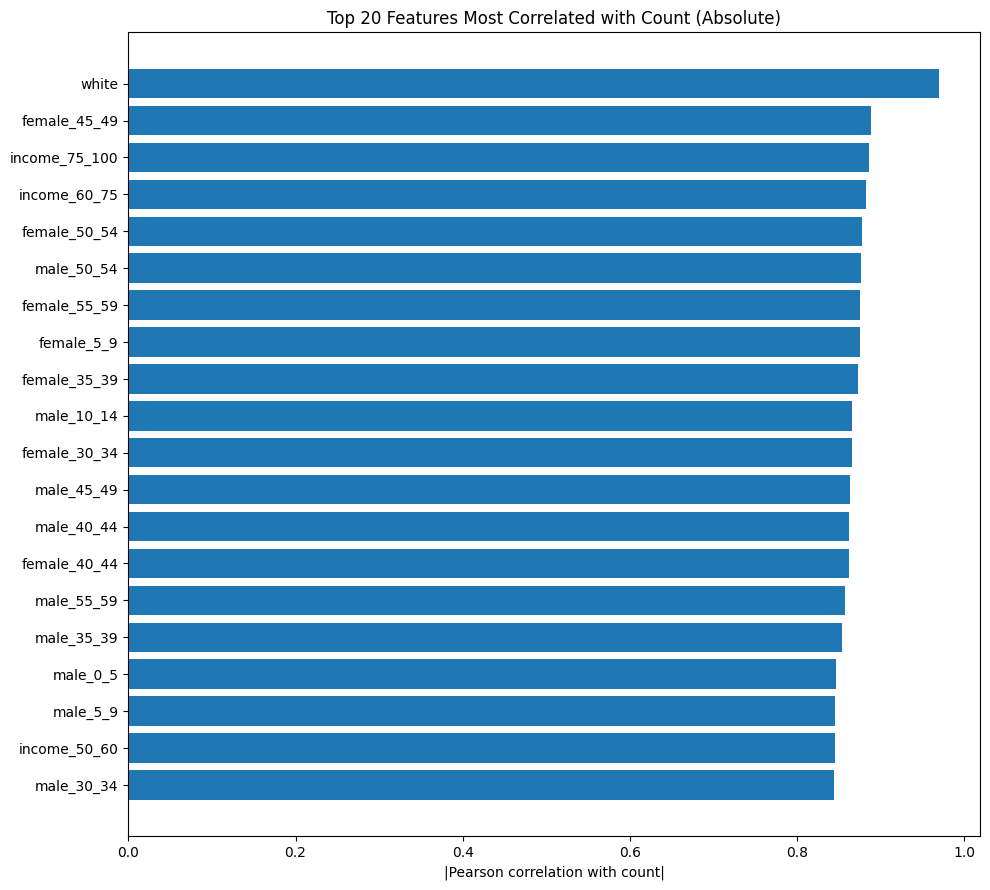

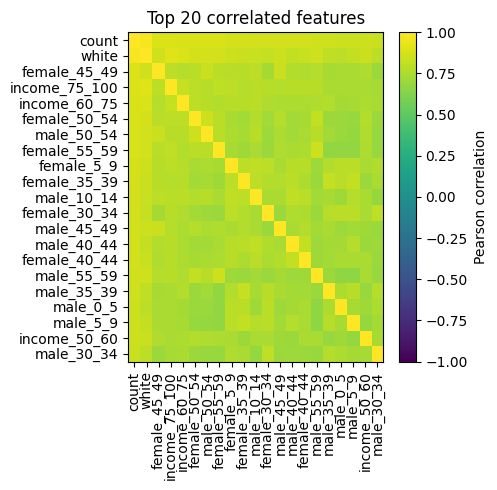

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
PATH = r"/Users/izarin2/Desktop/My Research/Project1/Dr Lisong/Dataset/Airsage Dataset/NebraskaLakes_Cleaned_round.csv"
# -------------------------
df = pd.read_csv(PATH)

# Ensure target is numeric
df["count"] = pd.to_numeric(df["count"], errors="coerce")

# -------------------------
# Select numeric features
# -------------------------
num_df = df.select_dtypes(include=[np.number]).dropna()

print("Numeric features:", num_df.columns.tolist())

# -------------------------
# Correlation matrix
# -------------------------
corr_matrix = num_df.corr(method="pearson")

import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Top-20 features by |correlation|
# -------------------------
top20 = (
    corr_matrix["count"]
    .drop("count")
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

top20_feats = top20.index.tolist()

# =========================
# (A) Bar chart: Top-20 |corr|
# =========================
plt.figure(figsize=(10, 9))
vals = top20.sort_values()  # so bars go from small->large
y = np.arange(len(vals))
plt.barh(y, vals.values)
plt.yticks(y, vals.index)
plt.xlabel("|Pearson correlation with count|")
plt.title("Top 20 Features Most Correlated with Count (Absolute)")
plt.tight_layout()
plt.show()

# =========================
# (B) Heatmap: correlation among count + Top-20
# =========================
sub_cols = ["count"] + top20_feats
sub_corr = corr_matrix.loc[sub_cols, sub_cols].copy()

plt.figure(figsize=(5, 5))
im = plt.imshow(sub_corr.values, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(im, label="Pearson correlation")

ticks = np.arange(len(sub_cols))
plt.xticks(ticks, sub_cols, rotation=90)
plt.yticks(ticks, sub_cols)
plt.title("Top 20 correlated features")
plt.tight_layout()
plt.show()


Hybrid and Base model campare in terms of Bias and Varience 


[SPATIAL+TEMPORAL]
Single = MLP (256,128,64) | R2=1.0000, MAE=1.293
Hybrid = STACK_GBR | R2=1.0000, MAE=1.277
Single Signed Bias  = -0.233
Hybrid Signed Bias  = -0.100
Single |Bias|       = 0.233
Hybrid |Bias|       = 0.100
Single Variance     = 261248.344
Hybrid Variance     = 262151.519
Single Residual Std = 2.387
Hybrid Residual Std = 3.079


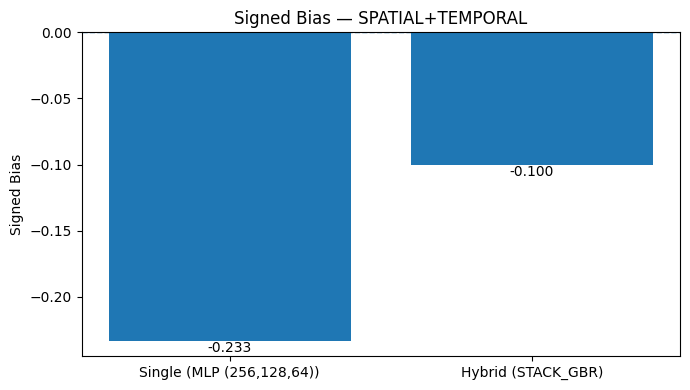

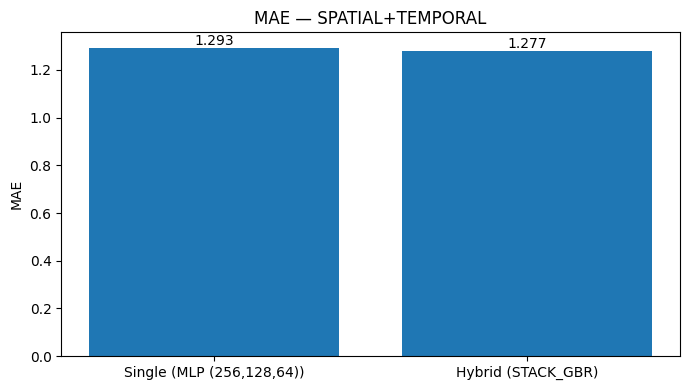

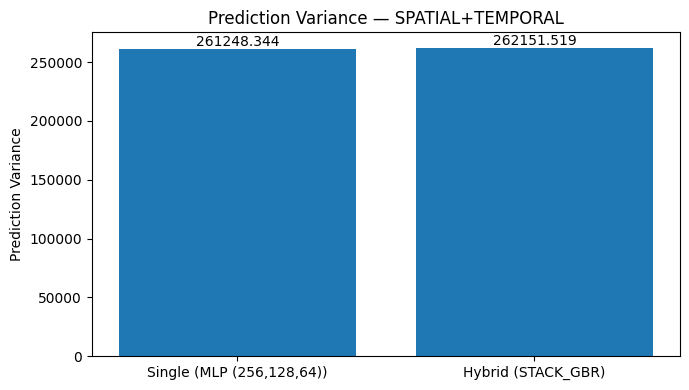

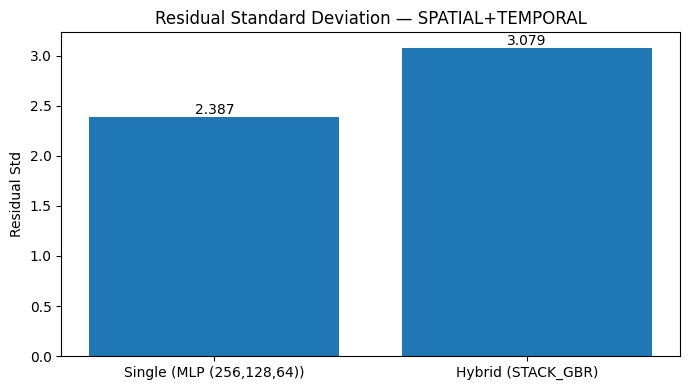

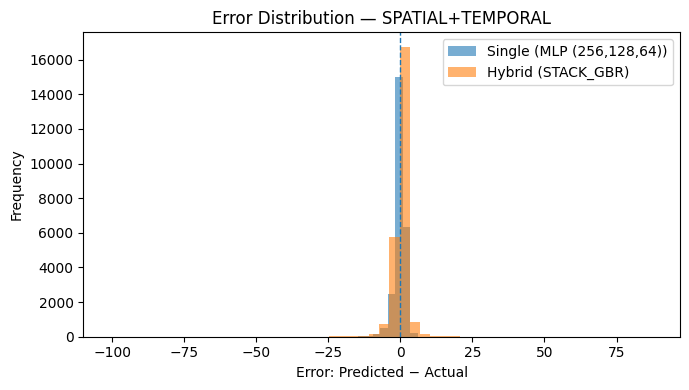

In [ ]:
# ===================== Bias / Variance + Error Distribution Plots =====================
# Paste this AFTER the hybrid/stacking block above, after df_h is created/printed.

import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error


def _get_est_by_name(name, MODELS):
    name = str(name).strip()
    for mname, mdl in MODELS:
        if str(mname).strip() == name:
            return mdl
    return None


def _parse_base_names_safely(bases_str, MODELS):
    """
    Safely parse base model names even when model names contain commas,
    e.g., MLP (256,128,64).
    """
    bases_str = str(bases_str)
    model_names = [str(mname).strip() for mname, _ in MODELS]

    found = []
    remaining = bases_str

    for mname in sorted(model_names, key=len, reverse=True):
        if mname in remaining:
            found.append(mname)
            remaining = remaining.replace(mname, "")

    return found


def _build_hybrid_estimator(hybrid_name, bases_str, MODELS, RANDOM_STATE):

    base_names = _parse_base_names_safely(bases_str, MODELS)

    bases = []
    for bn in base_names:
        base_def = _get_est_by_name(bn, MODELS)

        if base_def is None:
            print(f"[SKIP BASE] {bn} not found in MODELS.")
            continue

        bases.append((bn, clone(base_def)))

    if len(bases) == 0:
        return None

    if hybrid_name == "VOTE":
        from sklearn.ensemble import VotingRegressor
        return VotingRegressor(estimators=bases)

    if len(bases) < 2:
        return None

    from sklearn.ensemble import StackingRegressor, GradientBoostingRegressor
    from sklearn.linear_model import Ridge, LinearRegression

    if hybrid_name == "STACK_Ridge":
        return StackingRegressor(
            estimators=bases,
            final_estimator=Ridge(alpha=1.0),
            cv=3,
            passthrough=True,
        )

    if hybrid_name == "STACK_GBR":
        return StackingRegressor(
            estimators=bases,
            final_estimator=GradientBoostingRegressor(
                random_state=RANDOM_STATE,
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
            ),
            cv=3,
            passthrough=True,
        )

    if hybrid_name == "STACK_Lin":
        return StackingRegressor(
            estimators=bases,
            final_estimator=LinearRegression(),
            cv=3,
            passthrough=True,
        )

    return None


# ---- Best single and best hybrid per combo ----
best_single_rows = (
    top3_per_combo_single
    .sort_values(["Combo", "Score"], ascending=[True, False])
    .groupby("Combo", group_keys=False)
    .head(1)
    .reset_index(drop=True)
)

best_hybrid_rows = (
    df_h
    .sort_values(["Combo", "Score_H"], ascending=[True, False])
    .groupby("Combo", group_keys=False)
    .head(1)
    .reset_index(drop=True)
)

best_single_map = {r["Combo"]: r for _, r in best_single_rows.iterrows()}
best_hybrid_map = {r["Combo"]: r for _, r in best_hybrid_rows.iterrows()}


for combo_name, feats in BASE_COMBOS.items():

    if not feats:
        continue

    if combo_name not in best_single_map or combo_name not in best_hybrid_map:
        continue

    feats = [f for f in feats if f in df.columns]

    X, y = build_Xy(df, feats)

    if len(X) == 0 or X.shape[1] == 0:
        continue

    X_tr, X_te, y_tr, y_te = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    # ----- Best SINGLE -----
    base_name = best_single_map[combo_name]["Model"]
    base_def = _get_est_by_name(base_name, MODELS)

    if base_def is None:
        print(f"[SKIP] {combo_name}: base model '{base_name}' not found.")
        continue

    base_est = clone(base_def)
    base_est.fit(X_tr, y_tr)
    pred_b = base_est.predict(X_te)

    # ----- Best HYBRID -----
    hyb_row = best_hybrid_map[combo_name]
    hyb_name = hyb_row["Hybrid"]
    bases_str = hyb_row["Bases"]

    hyb_est = _build_hybrid_estimator(
        hyb_name,
        bases_str,
        MODELS,
        RANDOM_STATE
    )

    if hyb_est is None:
        print(f"[SKIP] {combo_name}: hybrid '{hyb_name}' could not be built.")
        continue

    hyb_est.fit(X_tr, y_tr)
    pred_h = hyb_est.predict(X_te)

    # ----- Bias / variance / errors -----
    err_b = pred_b - y_te
    err_h = pred_h - y_te

    signed_bias_b = float(np.mean(err_b))
    signed_bias_h = float(np.mean(err_h))

    abs_bias_b = float(abs(signed_bias_b))
    abs_bias_h = float(abs(signed_bias_h))

    var_b = float(np.var(pred_b))
    var_h = float(np.var(pred_h))

    residual_std_b = float(np.std(err_b))
    residual_std_h = float(np.std(err_h))

    r2_b = r2_score(y_te, pred_b)
    mae_b = mean_absolute_error(y_te, pred_b)

    r2_h = r2_score(y_te, pred_h)
    mae_h = mean_absolute_error(y_te, pred_h)

    print(f"\n[{combo_name}]")
    print(f"Single = {base_name} | R2={r2_b:.4f}, MAE={mae_b:.3f}")
    print(f"Hybrid = {hyb_name} | R2={r2_h:.4f}, MAE={mae_h:.3f}")
    print(f"Single Signed Bias  = {signed_bias_b:.3f}")
    print(f"Hybrid Signed Bias  = {signed_bias_h:.3f}")
    print(f"Single |Bias|       = {abs_bias_b:.3f}")
    print(f"Hybrid |Bias|       = {abs_bias_h:.3f}")
    print(f"Single Variance     = {var_b:.3f}")
    print(f"Hybrid Variance     = {var_h:.3f}")
    print(f"Single Residual Std = {residual_std_b:.3f}")
    print(f"Hybrid Residual Std = {residual_std_h:.3f}")

    labels = [f"Single ({base_name})", f"Hybrid ({hyb_name})"]
    x = np.arange(2)

    # --- Plot A: Signed Bias ---
    plt.figure(figsize=(7, 4))
    bars = plt.bar(x, [signed_bias_b, signed_bias_h])
    plt.xticks(x, labels)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.ylabel("Signed Bias")
    plt.title(f"Signed Bias — {combo_name}")

    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f"{h:.3f}",
            ha="center",
            va="bottom" if h >= 0 else "top"
        )

    plt.tight_layout()
    plt.show()

    # --- Plot B: MAE ---
    plt.figure(figsize=(7, 4))
    bars = plt.bar(x, [mae_b, mae_h])
    plt.xticks(x, labels)
    plt.ylabel("MAE")
    plt.title(f"MAE — {combo_name}")

    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f"{h:.3f}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

    # --- Plot C: Prediction Variance ---
    plt.figure(figsize=(7, 4))
    bars = plt.bar(x, [var_b, var_h])
    plt.xticks(x, labels)
    plt.ylabel("Prediction Variance")
    plt.title(f"Prediction Variance — {combo_name}")

    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f"{h:.3f}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

    # --- Plot D: Residual Standard Deviation ---
    plt.figure(figsize=(7, 4))
    bars = plt.bar(x, [residual_std_b, residual_std_h])
    plt.xticks(x, labels)
    plt.ylabel("Residual Std")
    plt.title(f"Residual Standard Deviation — {combo_name}")

    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f"{h:.3f}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

    # --- Plot E: Error Distribution ---
    plt.figure(figsize=(7, 4))
    plt.hist(err_b, bins=50, alpha=0.6, label=f"Single ({base_name})")
    plt.hist(err_h, bins=50, alpha=0.6, label=f"Hybrid ({hyb_name})")
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel("Error: Predicted − Actual")
    plt.ylabel("Frequency")
    plt.title(f"Error Distribution — {combo_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

K-Fold 


=== K-FOLD TABLE SUMMARY ===
Base K-fold rows   : 9
Hybrid K-fold rows : 9

Base K-fold models:
['MLP (256,128,64)', 'ETR', 'MLP (128,64)']

Hybrid K-fold models:
['STACK_GBR', 'VOTE', 'STACK_Ridge']


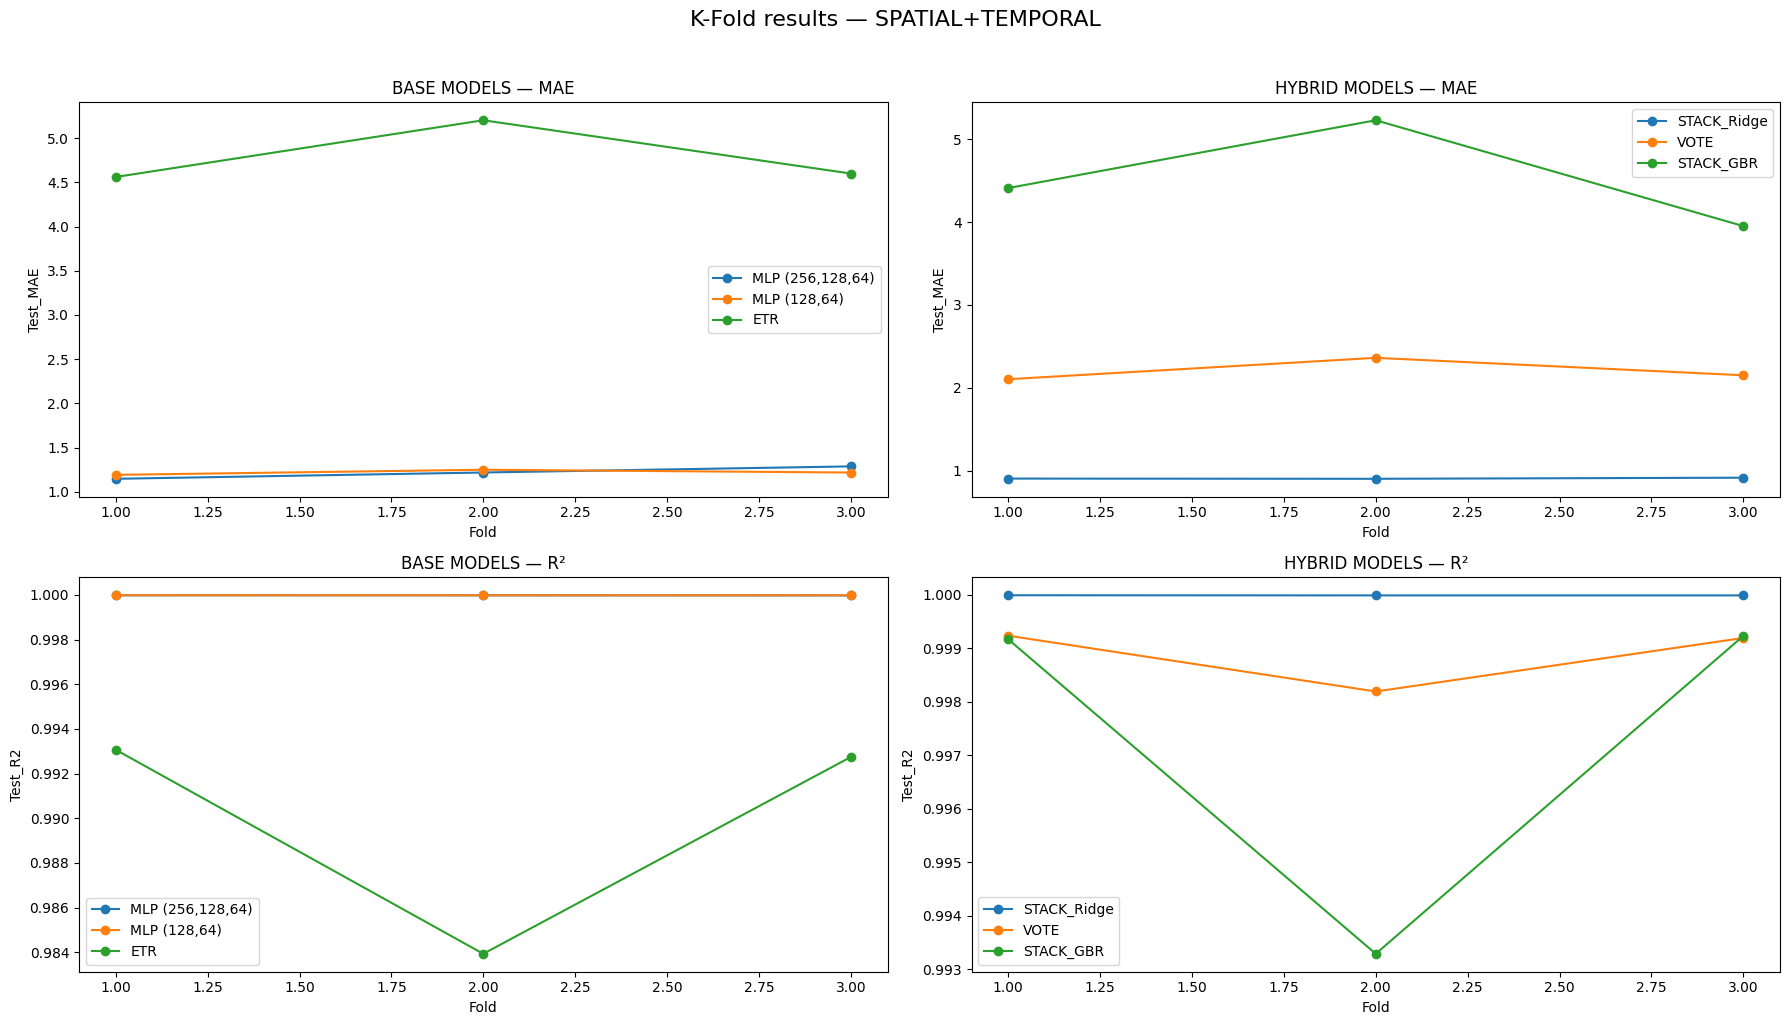


=== TOP-3 BASE by mean Test_MAE ===
           Model  Test_MAE_mean
MLP (256,128,64)       1.218274
    MLP (128,64)       1.220413
             ETR       4.787487

=== TOP-3 HYBRID by mean Test_MAE ===
     Hybrid  Test_MAE_mean
STACK_Ridge       0.906990
       VOTE       2.205798
  STACK_GBR       4.531633

Diagnostic skipped: STACK_Lin or STACK_Ridge not in hyb_fold_tbl.


In [ ]:
# =====================================================================================
# K-FOLD TABLES + TOP-3 BASE / TOP-3 HYBRID PLOTS
# Paste this AFTER your hybrid block, after df_h is created.
# =====================================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import VotingRegressor, StackingRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge

N_SPLITS = 3
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# ---------------- Helpers ----------------
def _get_model_def(name):
    name = str(name).strip()

    for mname, mdl in MODELS:
        if str(mname).strip() == name:
            return mdl

    return None


def _parse_base_names_safely(bases_str):
    """
    Safely parse model names from df_h['Bases'], including names with commas:
    Example: MLP (256,128,64)
    """
    bases_str = str(bases_str)
    model_names = [str(mname).strip() for mname, _ in MODELS]

    found = []
    remaining = bases_str

    for mname in sorted(model_names, key=len, reverse=True):
        if mname in remaining:
            found.append(mname)
            remaining = remaining.replace(mname, "")

    return found


# =====================================================================================
# 1) CREATE base_fold_tbl
# =====================================================================================

base_fold_rows = []

for combo_name, feats in BASE_COMBOS.items():

    feats = [f for f in feats if f in df.columns]

    if len(feats) == 0:
        continue

    X, y = build_Xy(df, feats)

    if len(X) == 0 or X.shape[1] == 0:
        continue

    top3_base_names = (
        final_tbl[final_tbl["Combo"] == combo_name]
        .sort_values("Score", ascending=False)
        .head(3)["Model"]
        .astype(str)
        .tolist()
    )

    if len(top3_base_names) == 0:
        continue

    for fold, (tr_idx, te_idx) in enumerate(kf.split(X), start=1):

        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        for model_name in top3_base_names:

            base_def = _get_model_def(model_name)

            if base_def is None:
                continue

            model = clone(base_def)
            model.fit(X_tr, y_tr)

            pred_te = model.predict(X_te)

            base_fold_rows.append({
                "Fold": fold,
                "Combo": combo_name,
                "Model": model_name,
                "Test_MAE": mean_absolute_error(y_te, pred_te),
                "Test_R2": r2_score(y_te, pred_te)
            })

base_fold_tbl = pd.DataFrame(base_fold_rows)


# =====================================================================================
# 2) CREATE hyb_fold_tbl
# =====================================================================================

hyb_fold_rows = []

for combo_name, feats in BASE_COMBOS.items():

    feats = [f for f in feats if f in df.columns]

    if len(feats) == 0:
        continue

    X, y = build_Xy(df, feats)

    if len(X) == 0 or X.shape[1] == 0:
        continue

    top_hybrids = (
        df_h[df_h["Combo"] == combo_name]
        .sort_values("Score_H", ascending=False)
        .head(8)
    )

    for fold, (tr_idx, te_idx) in enumerate(kf.split(X), start=1):

        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        for _, hr in top_hybrids.iterrows():

            hybrid_name = hr["Hybrid"]

            base_names = _parse_base_names_safely(hr["Bases"])

            bases = []

            for name in base_names:

                base_def = _get_model_def(name)

                if base_def is not None:
                    bases.append((name, clone(base_def)))

            if len(bases) == 0:
                continue

            try:

                if hybrid_name == "VOTE":

                    model = VotingRegressor(bases)

                elif hybrid_name == "STACK_Ridge":

                    model = StackingRegressor(
                        estimators=bases,
                        final_estimator=Ridge(alpha=1.0),
                        cv=3,
                        passthrough=True
                    )

                elif hybrid_name == "STACK_GBR":

                    model = StackingRegressor(
                        estimators=bases,
                        final_estimator=GradientBoostingRegressor(
                            random_state=RANDOM_STATE,
                            n_estimators=200,
                            learning_rate=0.05,
                            max_depth=3
                        ),
                        cv=3,
                        passthrough=True
                    )

                else:
                    continue

                model.fit(X_tr, y_tr)
                pred_te = model.predict(X_te)

                hyb_fold_rows.append({
                    "Fold": fold,
                    "Combo": combo_name,
                    "Hybrid": hybrid_name,
                    "Test_MAE": mean_absolute_error(y_te, pred_te),
                    "Test_R2": r2_score(y_te, pred_te)
                })

            except Exception as e:
                print(f"[skip] {hybrid_name} fold={fold}: {type(e).__name__}: {e}")

hyb_fold_tbl = pd.DataFrame(hyb_fold_rows)

print("\n=== K-FOLD TABLE SUMMARY ===")
print(f"Base K-fold rows   : {len(base_fold_tbl):,}")
print(f"Hybrid K-fold rows : {len(hyb_fold_tbl):,}")

if not base_fold_tbl.empty:
    print("\nBase K-fold models:")
    print(base_fold_tbl["Model"].drop_duplicates().tolist())

if not hyb_fold_tbl.empty:
    print("\nHybrid K-fold models:")
    print(hyb_fold_tbl["Hybrid"].drop_duplicates().tolist())


# =====================================================================================
# 3) PLOT TOP-3 BASE + TOP-3 HYBRID
# =====================================================================================

def pick_topk_by_mean(tbl, name_col, metric="Test_MAE", k=3, lower_is_better=True):

    if tbl is None or tbl.empty:
        return [], pd.DataFrame(columns=[name_col, f"{metric}_mean"])

    agg = (
        tbl.groupby(name_col, as_index=False)[metric]
        .mean()
        .rename(columns={metric: f"{metric}_mean"})
    )

    agg = agg.sort_values(
        f"{metric}_mean",
        ascending=lower_is_better
    )

    return agg[name_col].head(k).tolist(), agg


def plot_kfold_top3(base_fold_tbl, hyb_fold_tbl, combo_title="SPATIAL+TEMPORAL"):

    if base_fold_tbl.empty:
        print("\nNo base K-fold results were created. Check final_tbl, BASE_COMBOS, and features.")
        return [], []

    if hyb_fold_tbl.empty:
        print("\nNo hybrid K-fold results were created. Check df_h and hybrid bases.")
        return [], []

    top3_base, base_rank = pick_topk_by_mean(
        base_fold_tbl,
        name_col="Model",
        metric="Test_MAE",
        k=3,
        lower_is_better=True
    )

    top3_hyb, hyb_rank = pick_topk_by_mean(
        hyb_fold_tbl,
        name_col="Hybrid",
        metric="Test_MAE",
        k=3,
        lower_is_better=True
    )

    b = base_fold_tbl[base_fold_tbl["Model"].isin(top3_base)].copy()
    h = hyb_fold_tbl[hyb_fold_tbl["Hybrid"].isin(top3_hyb)].copy()

    folds = sorted(set(b["Fold"].unique()) | set(h["Fold"].unique()))

    b_mae = (
        b.pivot_table(index="Fold", columns="Model", values="Test_MAE", aggfunc="mean")
        .reindex(folds)
    )

    b_r2 = (
        b.pivot_table(index="Fold", columns="Model", values="Test_R2", aggfunc="mean")
        .reindex(folds)
    )

    h_mae = (
        h.pivot_table(index="Fold", columns="Hybrid", values="Test_MAE", aggfunc="mean")
        .reindex(folds)
    )

    h_r2 = (
        h.pivot_table(index="Fold", columns="Hybrid", values="Test_R2", aggfunc="mean")
        .reindex(folds)
    )

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    (ax1, ax2), (ax3, ax4) = axes

    for m in top3_base:
        if m in b_mae.columns:
            ax1.plot(b_mae.index, b_mae[m].values, marker="o", label=m)

    ax1.set_title("BASE MODELS — MAE")
    ax1.set_xlabel("Fold")
    ax1.set_ylabel("Test_MAE")
    ax1.legend(loc="best")

    for m in top3_hyb:
        if m in h_mae.columns:
            ax2.plot(h_mae.index, h_mae[m].values, marker="o", label=m)

    ax2.set_title("HYBRID MODELS — MAE")
    ax2.set_xlabel("Fold")
    ax2.set_ylabel("Test_MAE")
    ax2.legend(loc="best")

    for m in top3_base:
        if m in b_r2.columns:
            ax3.plot(b_r2.index, b_r2[m].values, marker="o", label=m)

    ax3.set_title("BASE MODELS — R²")
    ax3.set_xlabel("Fold")
    ax3.set_ylabel("Test_R2")
    ax3.legend(loc="best")

    for m in top3_hyb:
        if m in h_r2.columns:
            ax4.plot(h_r2.index, h_r2[m].values, marker="o", label=m)

    ax4.set_title("HYBRID MODELS — R²")
    ax4.set_xlabel("Fold")
    ax4.set_ylabel("Test_R2")
    ax4.legend(loc="best")

    fig.suptitle(f"K-Fold results — {combo_title}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    print("\n=== TOP-3 BASE by mean Test_MAE ===")
    print(
        base_rank.sort_values("Test_MAE_mean", ascending=True)
        .head(10)
        .to_string(index=False)
    )

    print("\n=== TOP-3 HYBRID by mean Test_MAE ===")
    print(
        hyb_rank.sort_values("Test_MAE_mean", ascending=True)
        .head(10)
        .to_string(index=False)
    )

    return top3_base, top3_hyb


# =====================================================================================
# 4) DIAGNOSTIC
# =====================================================================================

def diagnose_stack_similarity(hyb_fold_tbl, a="STACK_Lin", b="STACK_Ridge"):

    if (
        a not in hyb_fold_tbl["Hybrid"].unique()
        or b not in hyb_fold_tbl["Hybrid"].unique()
    ):
        print(f"\nDiagnostic skipped: {a} or {b} not in hyb_fold_tbl.")
        return

    aa = hyb_fold_tbl[hyb_fold_tbl["Hybrid"] == a].sort_values("Fold")
    bb = hyb_fold_tbl[hyb_fold_tbl["Hybrid"] == b].sort_values("Fold")

    merged = aa.merge(
        bb,
        on=["Fold"],
        suffixes=(f"_{a}", f"_{b}")
    )

    merged["dMAE"] = merged[f"Test_MAE_{a}"] - merged[f"Test_MAE_{b}"]
    merged["dR2"] = merged[f"Test_R2_{a}"] - merged[f"Test_R2_{b}"]

    print(f"\n=== {a} vs {b} per-fold differences ===")

    print(
        merged[
            [
                "Fold",
                f"Test_MAE_{a}",
                f"Test_MAE_{b}",
                "dMAE",
                f"Test_R2_{a}",
                f"Test_R2_{b}",
                "dR2"
            ]
        ].to_string(index=False, float_format=lambda x: f"{x:.6f}")
    )


# ===================== RUN =====================
top3_base, top3_hyb = plot_kfold_top3(
    base_fold_tbl,
    hyb_fold_tbl,
    combo_title="SPATIAL+TEMPORAL"
)

diagnose_stack_similarity(
    hyb_fold_tbl,
    a="STACK_Lin",
    b="STACK_Ridge"
)